In [1]:
import mlflow
import mlflow.lightgbm
import lightgbm as lgb
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

In [2]:
test_path = r"../test.parquet"
train_path = r"../train.parquet"
test = pd.read_parquet(test_path)
train = pd.read_parquet(train_path)

In [3]:
def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    sleep_quality_map = {
        "poor": 1,
        "average": 2,
        "good": 3
    }
    facility_rating_map = {
        "low": 1, 
        "medium": 2, 
        "high": 3
    }
    
    exam_difficulty_map = {
        "easy": 1, 
        "moderate": 2, 
        "hard": 3
    }

    # Ordiinal Encoding
    # df["sleep_quality"] = df["sleep_quality"].map(sleep_quality_map)
    # df["facility_rating"] = df["facility_rating"].map(facility_rating_map)
    # df["exam_difficulty"] = df["exam_difficulty"].map(exam_difficulty_map)

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])
    df["sleep_x_study"] = df["sleep_hours"] * df["study_hours"]
    # df["class_attendance_x_study"] = df["class_attendance"] * df["study_hours"]
    df["class_attendance_x_sleep"] = df["class_attendance"] * df["sleep_hours"]

    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        "sleep_quality",
        "facility_rating",
        "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")

    # df = df.drop(columns=['gender', 'age'])
    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

In [35]:
new_df = train.copy()
TARGET = 'exam_score'

# Preprocessing
prep_df = preprocessing(new_df)
X, y = prep_df.drop(columns=['id', TARGET]), prep_df[[TARGET]] 

# Test-Train Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
params = {
    "objective": "regression",
    "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.05,
    "n_estimators": 3000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 5.0,
    "lambda_l2": 5.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 6,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 150,
}

mlflow.set_experiment("lgbm_regressor_experiment")
mlflow.set_tracking_uri(r"http://127.0.0.1:8080/")
mlflow.lightgbm.autolog()

with mlflow.start_run():
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_test, y_test))

    preds = model.predict(X_test, num_iteration=model.best_iteration_)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("best_iteration", model.best_iteration_)

    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")

2026/01/24 16:27:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Dsoft\Projects\ML\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/01/24 16:27:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Dsoft\Projects\ML\.venv\Lib\site-packages\mlflow\t

[LightGBM] [Warning] min_data_in_leaf is set=500, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=500
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] lambda_l1 is set=5.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5.0
[LightGBM] [Warning] lambda_l2 is set=5.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] early_stopping_round is set=150, early_stopping_rounds=150 will be ignored. Current value: early_stopping_round=150
[LightGBM] [Warning] min_data_in_leaf is set=500, min_child

2026/01/24 16:28:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Dsoft\Projects\ML\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/01/24 16:28:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LightGBM] [Warning] min_data_in_leaf is set=500, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=500
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] lambda_l1 is set=5.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5.0
[LightGBM] [Warning] lambda_l2 is set=5.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6


2026/01/24 16:29:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\16yas\AppData\Local\Temp\tmp0qnoztf9\model, flavor: lightgbm). Fall back to return ['lightgbm==4.6.0', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


[LightGBM] [Warning] min_data_in_leaf is set=500, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=500
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] lambda_l1 is set=5.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5.0
[LightGBM] [Warning] lambda_l2 is set=5.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6


2026/01/24 16:29:16 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Dsoft\Projects\ML\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


RMSE: 8.75162042535441
R2: 0.7846436872602617
🏃 View run loud-mouse-522 at: http://127.0.0.1:8080/#/experiments/1/runs/95072381fe244ee5a4731bda0db32353
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


In [37]:
df = train.copy()

## DeepSeek Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load your data (adjust path as needed)
# df = pd.read_csv('your_data.csv')
# For now, let's assume df is already loaded

print("Dataset Overview:")
print("=" * 50)
print(f"Total records: {df.shape[0]:,}")
print(f"Total features: {df.shape[1] - 1}")  # minus target
print(f"Target variable: exam_score")
print("\nFeature types:")
print(df.dtypes)

Dataset Overview:
Total records: 630,000
Total features: 12
Target variable: exam_score

Feature types:
id                    int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object


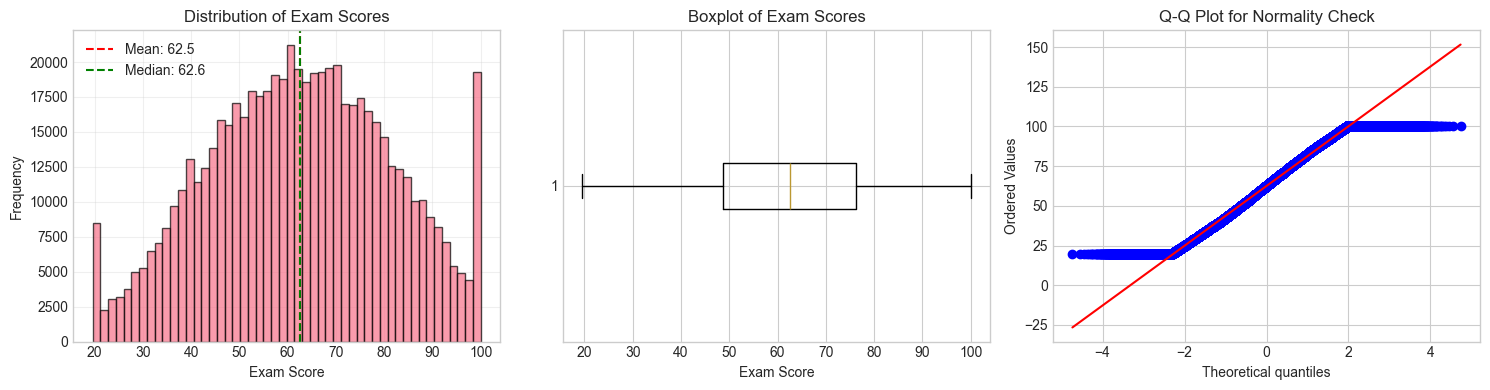


Target Variable - Exam Score:
count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64

Skewness: -0.048
Kurtosis: -0.619
Range: 80.4
IQR: 27.5


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution
axes[0].hist(df['exam_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['exam_score'].mean(), color='red', linestyle='--', 
                 label=f'Mean: {df["exam_score"].mean():.1f}')
axes[0].axvline(df['exam_score'].median(), color='green', linestyle='--', 
                 label=f'Median: {df["exam_score"].median():.1f}')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Exam Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Boxplot
axes[1].boxplot(df['exam_score'], vert=False)
axes[1].set_xlabel('Exam Score')
axes[1].set_title('Boxplot of Exam Scores')

# 3. Q-Q plot for normality check
stats.probplot(df['exam_score'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot for Normality Check')

plt.tight_layout()
plt.show()

# Statistical summary
print("\nTarget Variable - Exam Score:")
print("=" * 50)
print(df['exam_score'].describe())
print(f"\nSkewness: {df['exam_score'].skew():.3f}")
print(f"Kurtosis: {df['exam_score'].kurtosis():.3f}")
print(f"Range: {df['exam_score'].max() - df['exam_score'].min():.1f}")
print(f"IQR: {df['exam_score'].quantile(0.75) - df['exam_score'].quantile(0.25):.1f}")


ANALYZING FEATURE: AGE


C:\Users\16yas\AppData\Local\Temp\ipykernel_17640\1000250817.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby(f'{feature}_binned')['exam_score'].agg(['mean', 'std', 'count'])


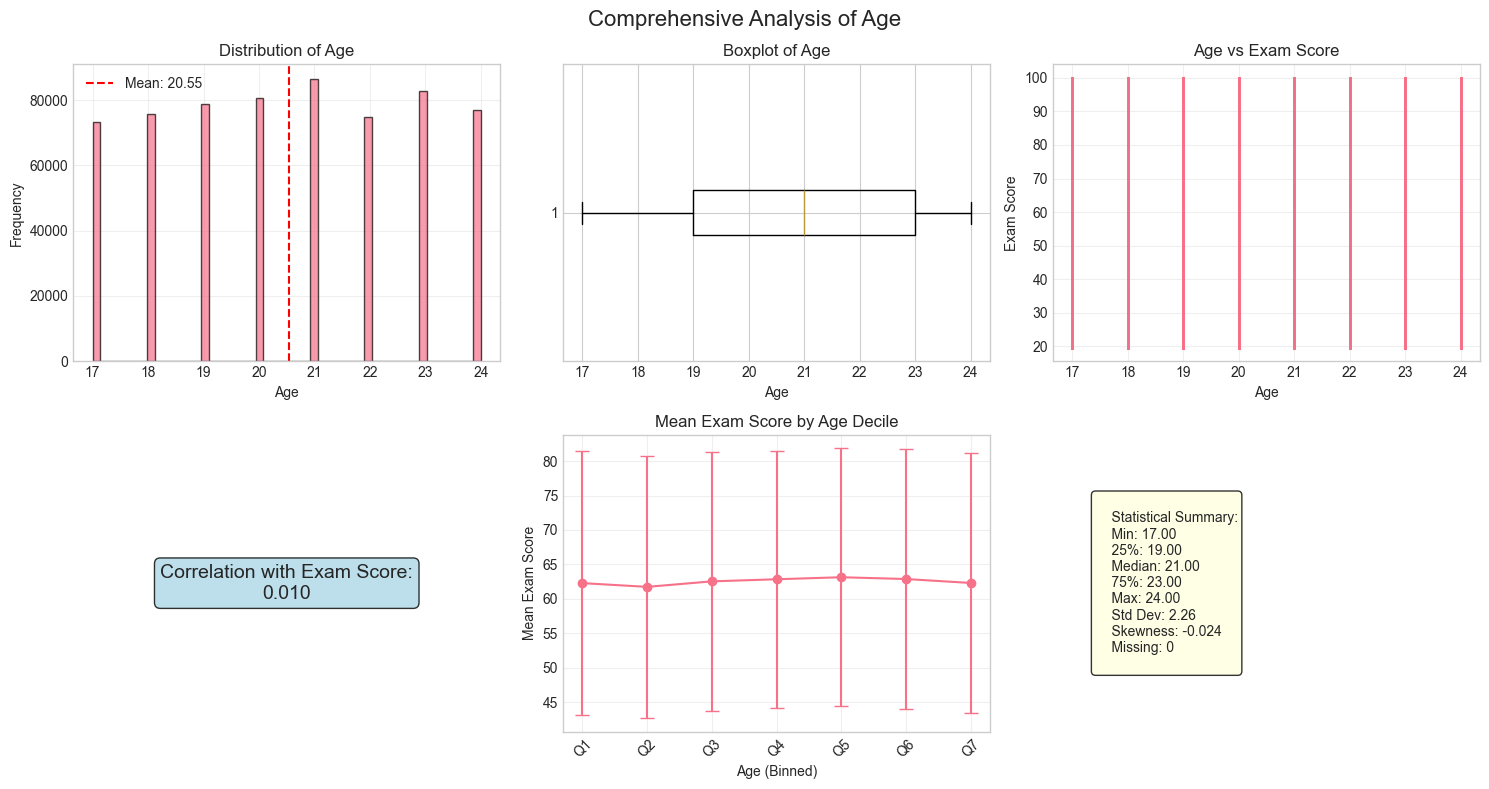


Key Insights for age:
----------------------------------------
1. Correlation with exam score: 0.010
2. Strength of relationship: Weak
3. Direction: Positive
4. Outliers detected: 0 (0.0%)
5. Data range: 17.00 to 24.00
7. Potential predictive power: LOW

ANALYZING FEATURE: STUDY_HOURS


C:\Users\16yas\AppData\Local\Temp\ipykernel_17640\1000250817.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby(f'{feature}_binned')['exam_score'].agg(['mean', 'std', 'count'])


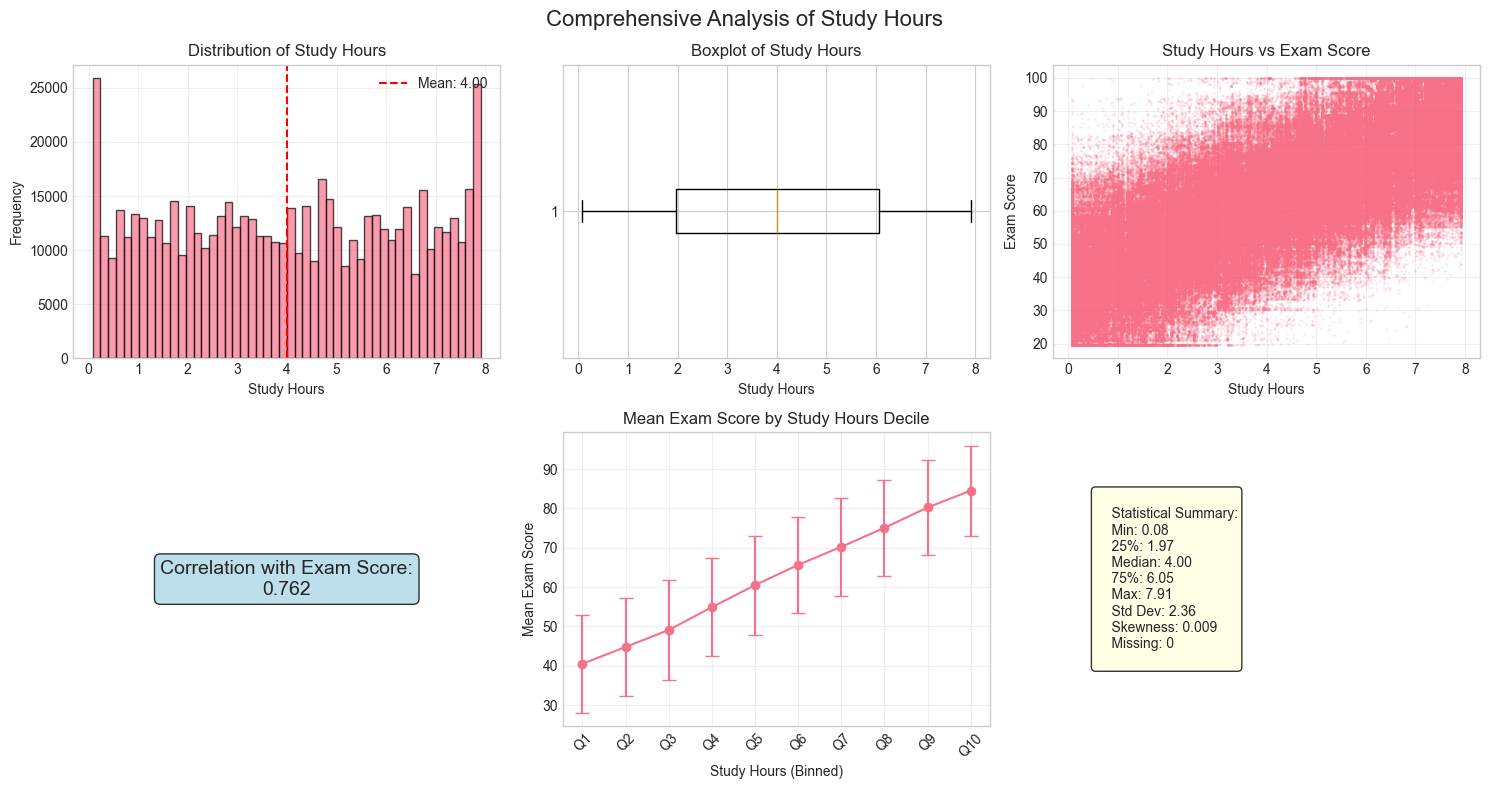


Key Insights for study_hours:
----------------------------------------
1. Correlation with exam score: 0.762
2. Strength of relationship: Strong
3. Direction: Positive
4. Outliers detected: 0 (0.0%)
5. Data range: 0.08 to 7.91
7. Potential predictive power: GOOD

ANALYZING FEATURE: CLASS_ATTENDANCE


C:\Users\16yas\AppData\Local\Temp\ipykernel_17640\1000250817.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby(f'{feature}_binned')['exam_score'].agg(['mean', 'std', 'count'])


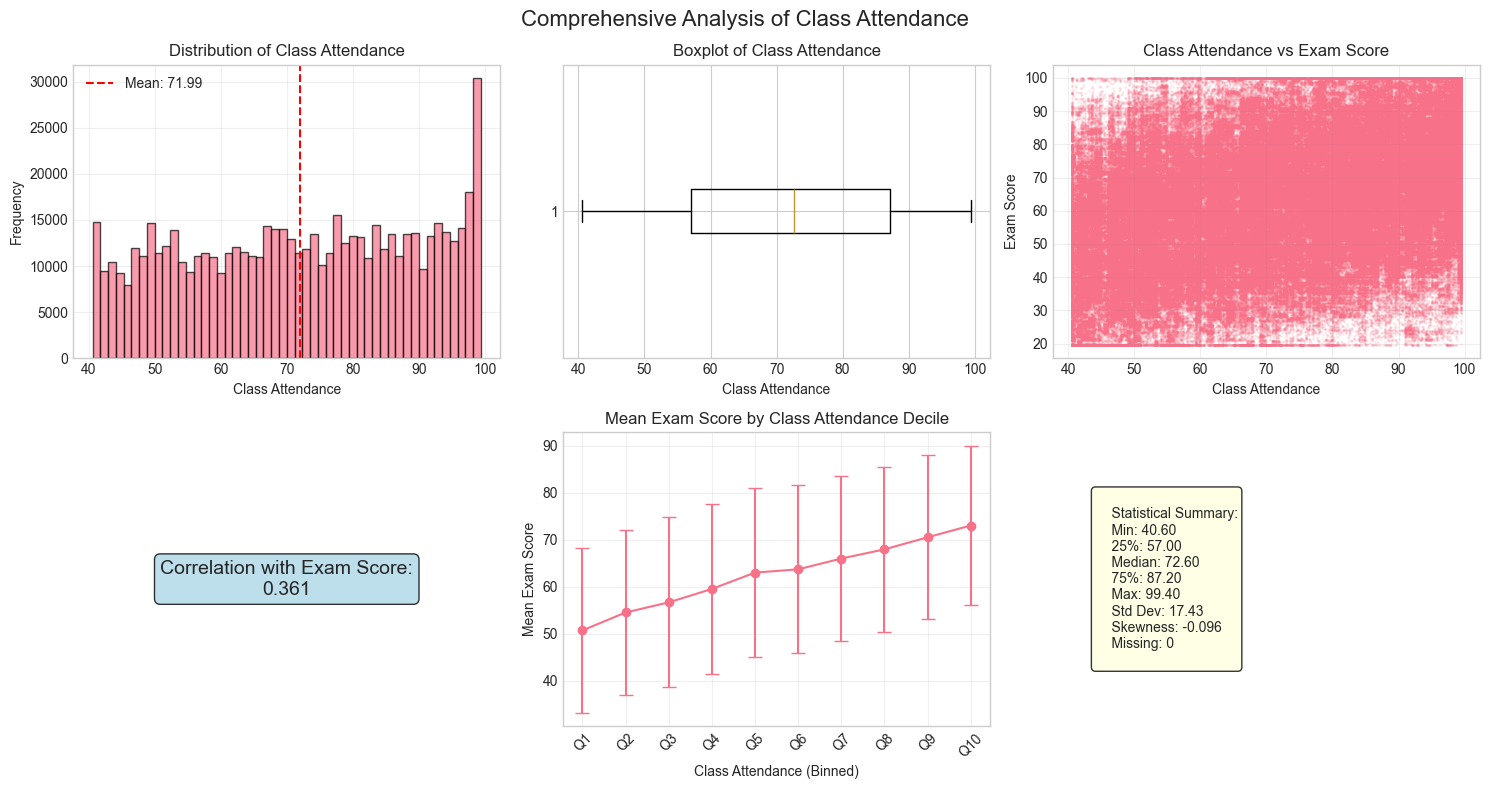


Key Insights for class_attendance:
----------------------------------------
1. Correlation with exam score: 0.361
2. Strength of relationship: Moderate
3. Direction: Positive
4. Outliers detected: 0 (0.0%)
5. Data range: 40.60 to 99.40
7. Potential predictive power: GOOD

ANALYZING FEATURE: SLEEP_HOURS


C:\Users\16yas\AppData\Local\Temp\ipykernel_17640\1000250817.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby(f'{feature}_binned')['exam_score'].agg(['mean', 'std', 'count'])


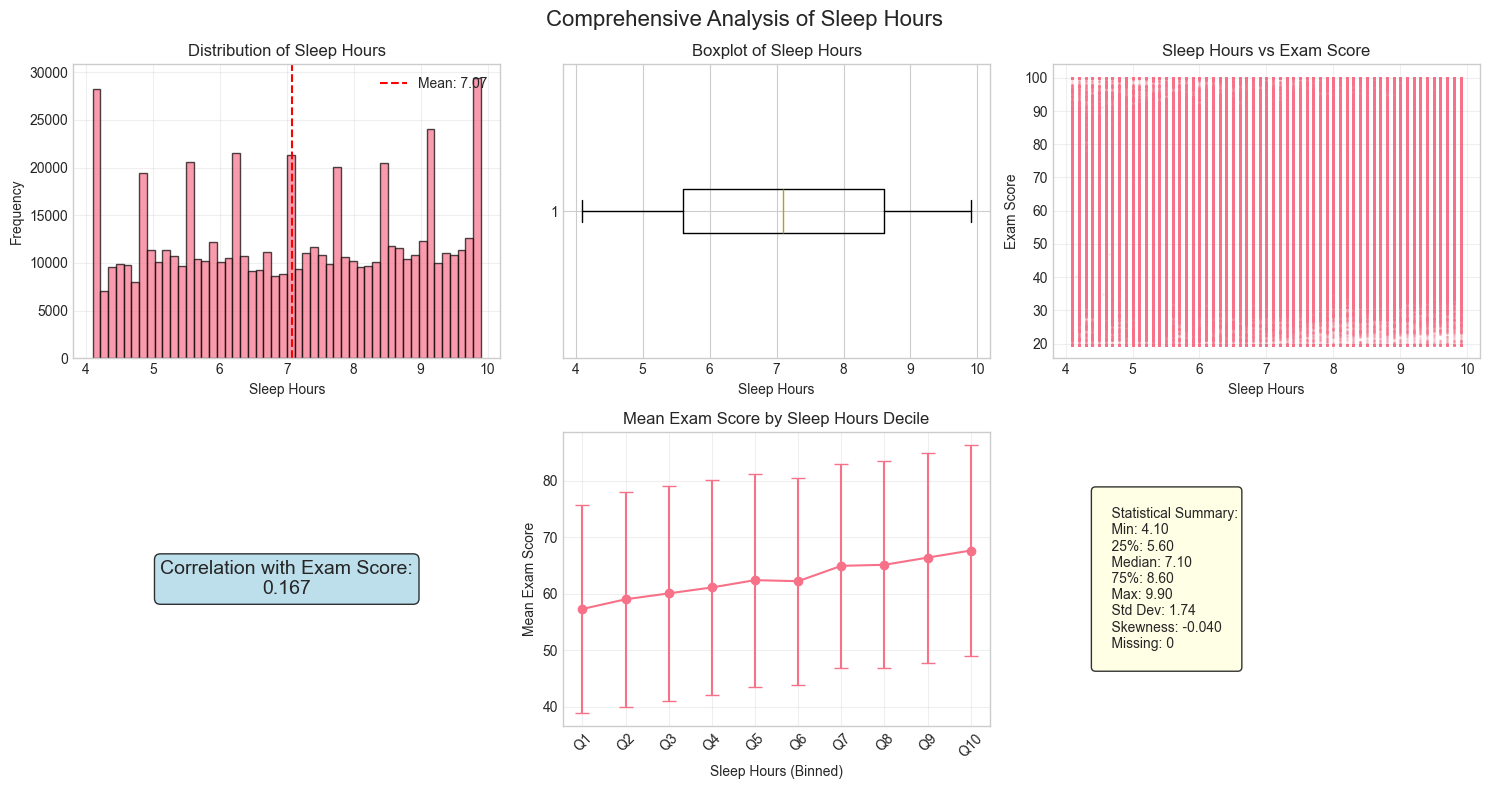


Key Insights for sleep_hours:
----------------------------------------
1. Correlation with exam score: 0.167
2. Strength of relationship: Weak
3. Direction: Positive
4. Outliers detected: 0 (0.0%)
5. Data range: 4.10 to 9.90
7. Potential predictive power: MODERATE


In [40]:
# List of numerical features
numerical_features = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

for feature in numerical_features:
    print(f"\n{'='*60}")
    print(f"ANALYZING FEATURE: {feature.upper()}")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # 1. Distribution
    axes[0, 0].hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[feature].mean(), color='red', linestyle='--', 
                      label=f'Mean: {df[feature].mean():.2f}')
    axes[0, 0].set_xlabel(feature.replace('_', ' ').title())
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Boxplot
    axes[0, 1].boxplot(df[feature], vert=False)
    axes[0, 1].set_xlabel(feature.replace('_', ' ').title())
    axes[0, 1].set_title(f'Boxplot of {feature.replace("_", " ").title()}')
    
    # 3. Scatter plot vs target
    axes[0, 2].scatter(df[feature], df['exam_score'], alpha=0.1, s=1)
    axes[0, 2].set_xlabel(feature.replace('_', ' ').title())
    axes[0, 2].set_ylabel('Exam Score')
    axes[0, 2].set_title(f'{feature.replace("_", " ").title()} vs Exam Score')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Correlation calculation
    correlation = df[feature].corr(df['exam_score'])
    axes[1, 0].text(0.5, 0.5, f'Correlation with Exam Score:\n{correlation:.3f}', 
                   ha='center', va='center', fontsize=14,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[1, 0].axis('off')
    
    # 5. Binned analysis
    df[f'{feature}_binned'] = pd.qcut(df[feature], q=10, duplicates='drop')
    binned_stats = df.groupby(f'{feature}_binned')['exam_score'].agg(['mean', 'std', 'count'])
    
    axes[1, 1].errorbar(range(len(binned_stats)), binned_stats['mean'], 
                       yerr=binned_stats['std'], fmt='o-', capsize=5)
    axes[1, 1].set_xlabel(f'{feature.replace("_", " ").title()} (Binned)')
    axes[1, 1].set_ylabel('Mean Exam Score')
    axes[1, 1].set_title(f'Mean Exam Score by {feature.replace("_", " ").title()} Decile')
    axes[1, 1].set_xticks(range(len(binned_stats)))
    axes[1, 1].set_xticklabels([f'Q{i+1}' for i in range(len(binned_stats))], rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Statistical summary
    stats_text = f"""
    Statistical Summary:
    Min: {df[feature].min():.2f}
    25%: {df[feature].quantile(0.25):.2f}
    Median: {df[feature].median():.2f}
    75%: {df[feature].quantile(0.75):.2f}
    Max: {df[feature].max():.2f}
    Std Dev: {df[feature].std():.2f}
    Skewness: {df[feature].skew():.3f}
    Missing: {df[feature].isnull().sum()}
    """
    axes[1, 2].text(0.1, 0.5, stats_text, fontsize=10, 
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Comprehensive Analysis of {feature.replace("_", " ").title()}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Clean up temporary column
    df.drop(f'{feature}_binned', axis=1, inplace=True)
    
    # Print detailed insights
    print(f"\nKey Insights for {feature}:")
    print("-" * 40)
    
    # Check for outliers using IQR method
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    print(f"1. Correlation with exam score: {correlation:.3f}")
    print(f"2. Strength of relationship: {'Strong' if abs(correlation) > 0.5 else 'Moderate' if abs(correlation) > 0.3 else 'Weak'}")
    print(f"3. Direction: {'Positive' if correlation > 0 else 'Negative'}")
    print(f"4. Outliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"5. Data range: {df[feature].min():.2f} to {df[feature].max():.2f}")
    
    # Suggest transformations if needed
    if abs(df[feature].skew()) > 1:
        print(f"6. Highly skewed (skewness: {df[feature].skew():.2f}). Consider transformation.")
    if correlation > 0.3:
        print(f"7. Potential predictive power: GOOD")
    elif correlation > 0.1:
        print(f"7. Potential predictive power: MODERATE")
    else:
        print(f"7. Potential predictive power: LOW")


ANALYZING FEATURE: GENDER


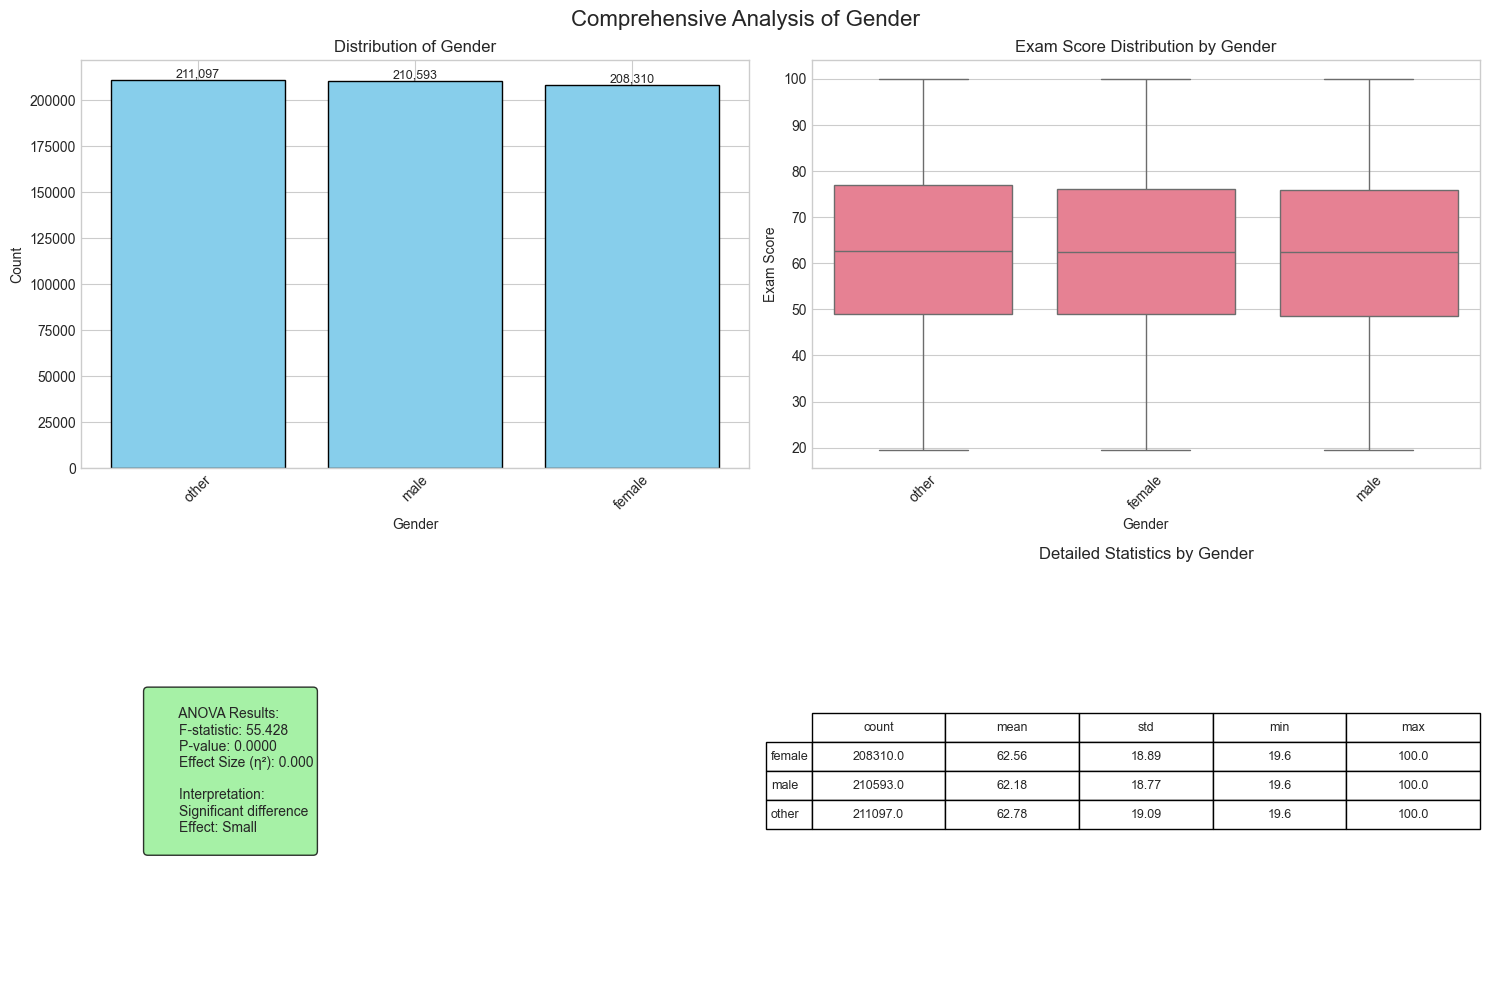


Key Insights for gender:
----------------------------------------
Number of unique values: 3
Most frequent category: other (33.5%)
Variability explained: 0.016
Encoding suggestion: One-hot encoding

ANALYZING FEATURE: COURSE


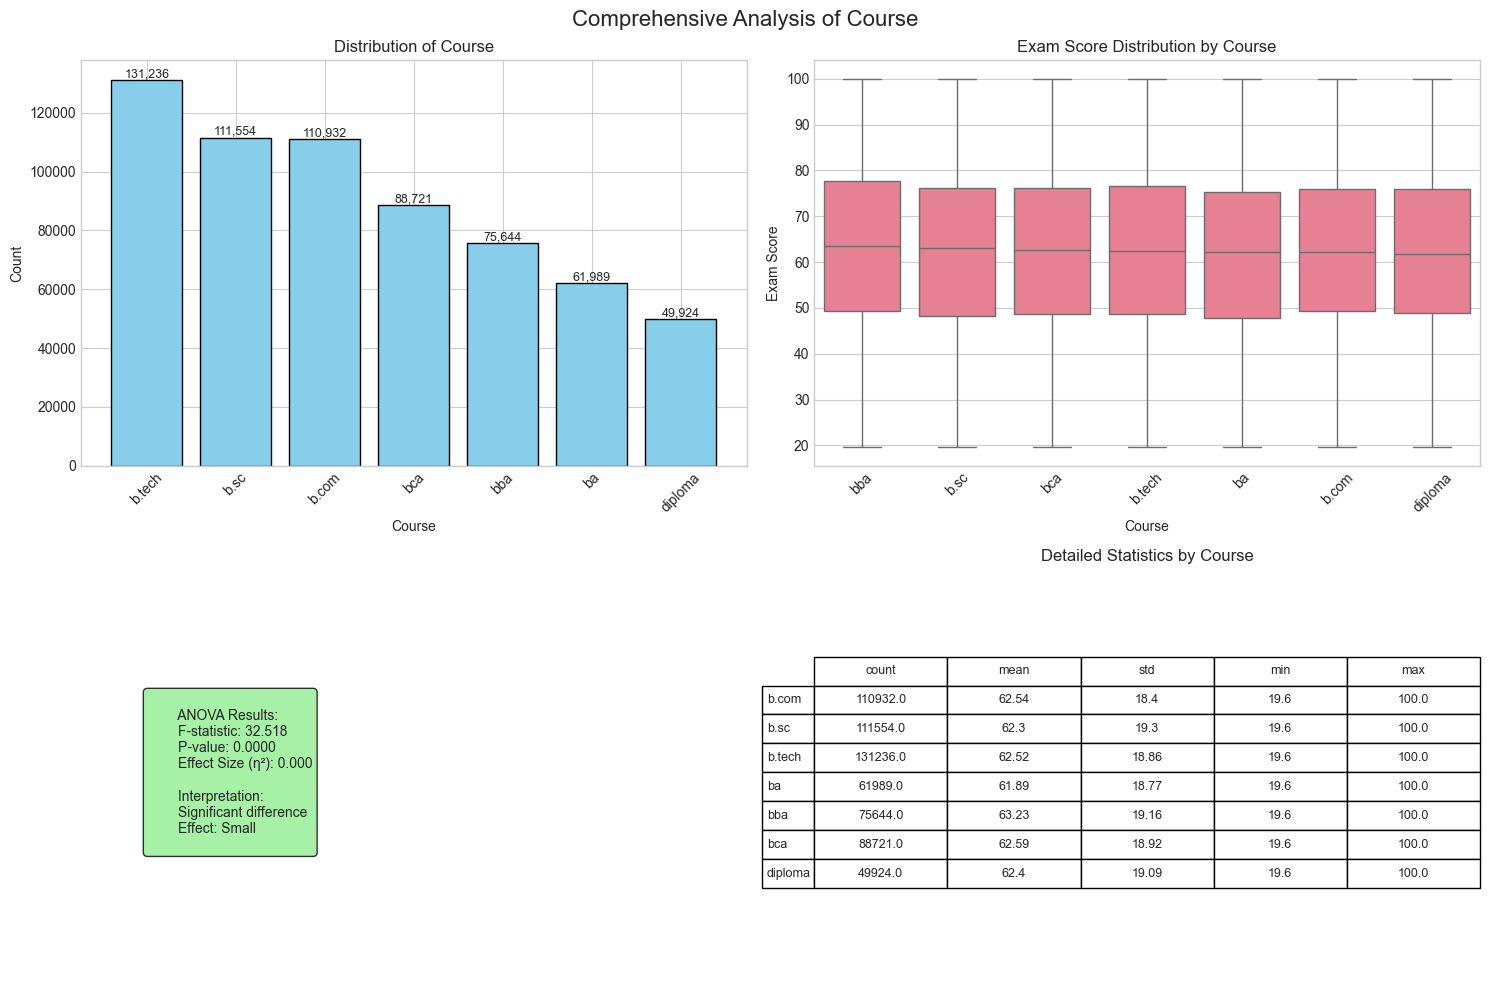


Key Insights for course:
----------------------------------------
Number of unique values: 7
Most frequent category: b.tech (20.8%)
Variability explained: 0.021
Encoding suggestion: Consider target encoding or frequency encoding

ANALYZING FEATURE: INTERNET_ACCESS


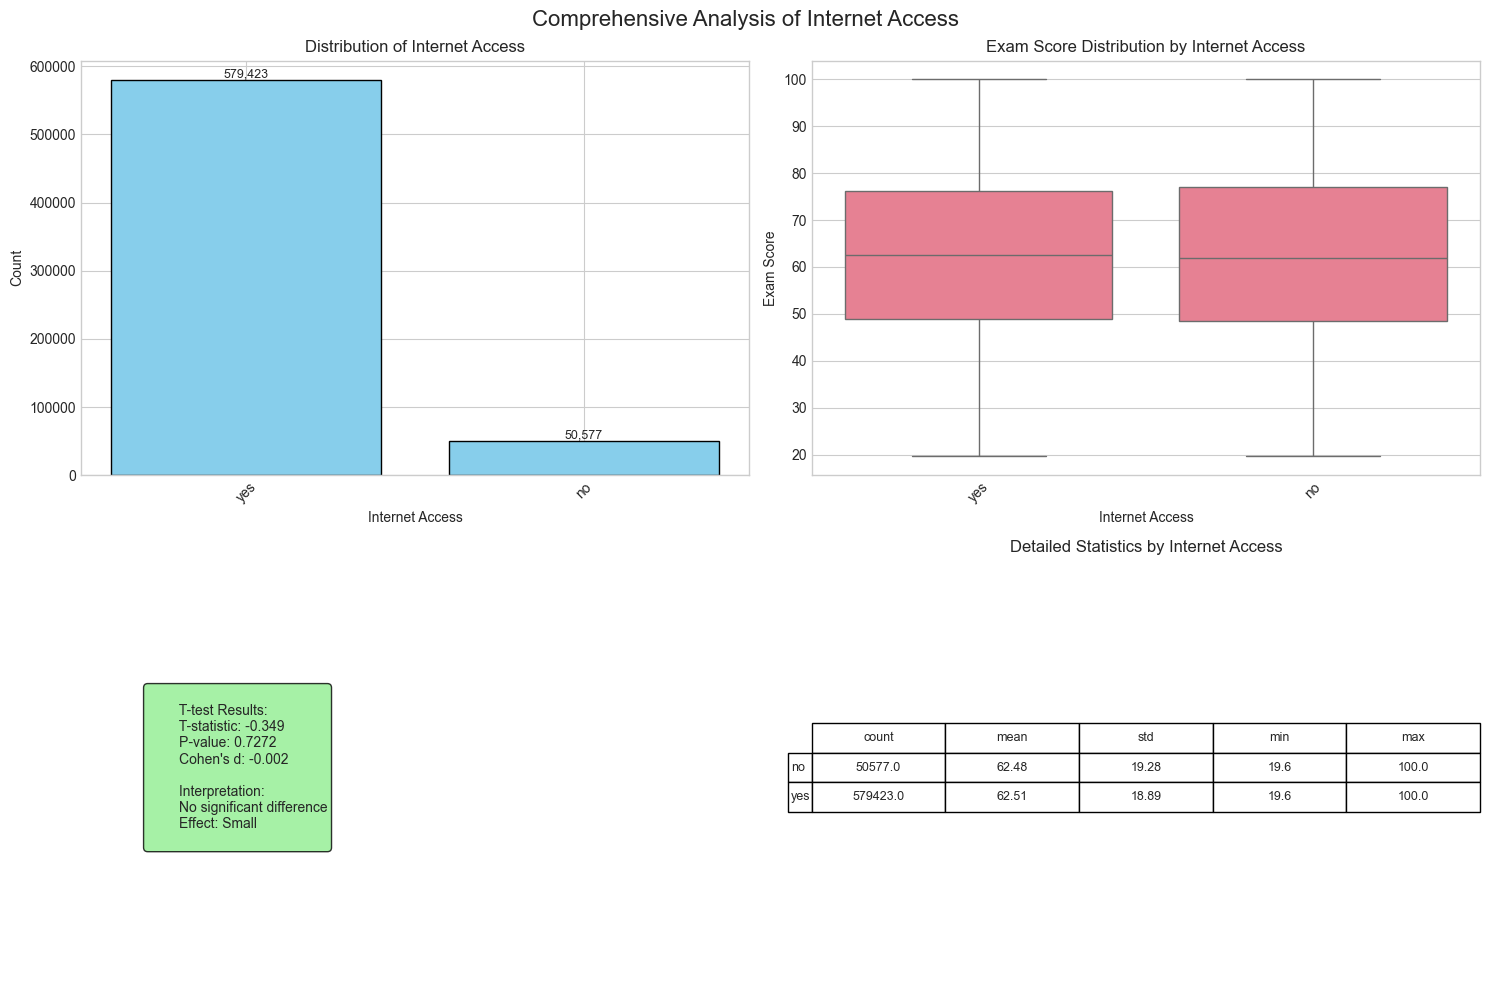


Key Insights for internet_access:
----------------------------------------
Number of unique values: 2
Most frequent category: yes (92.0%)
Variability explained: 0.001
Encoding suggestion: One-hot encoding

ANALYZING FEATURE: SLEEP_QUALITY


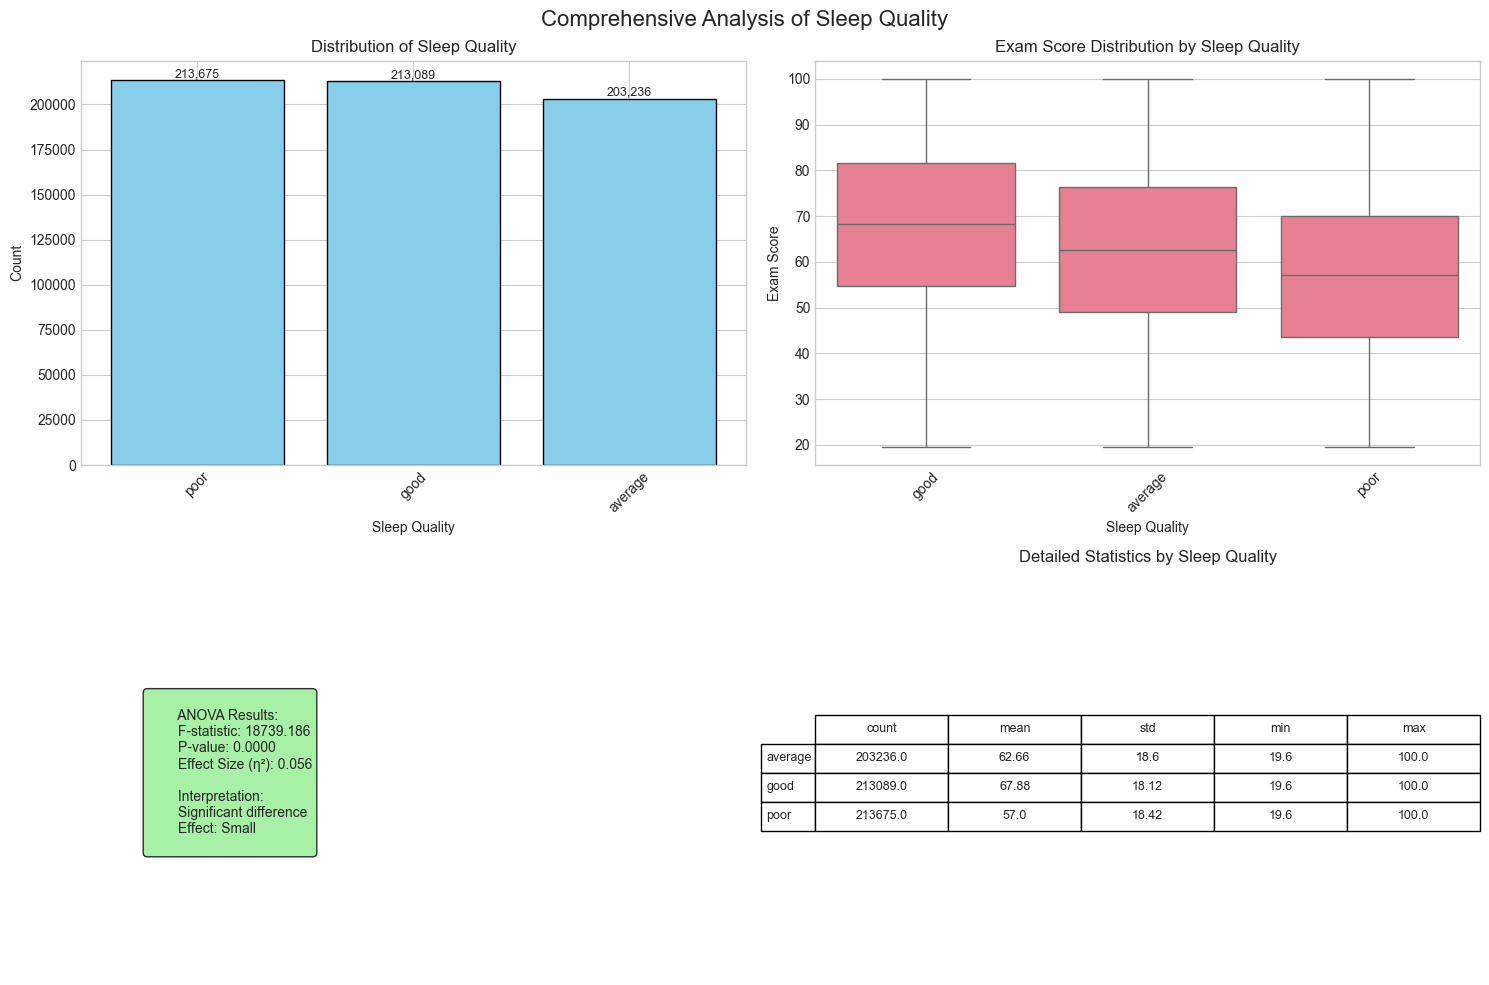


Key Insights for sleep_quality:
----------------------------------------
Number of unique values: 3
Most frequent category: poor (33.9%)
Variability explained: 0.288
Encoding suggestion: One-hot encoding

ANALYZING FEATURE: STUDY_METHOD


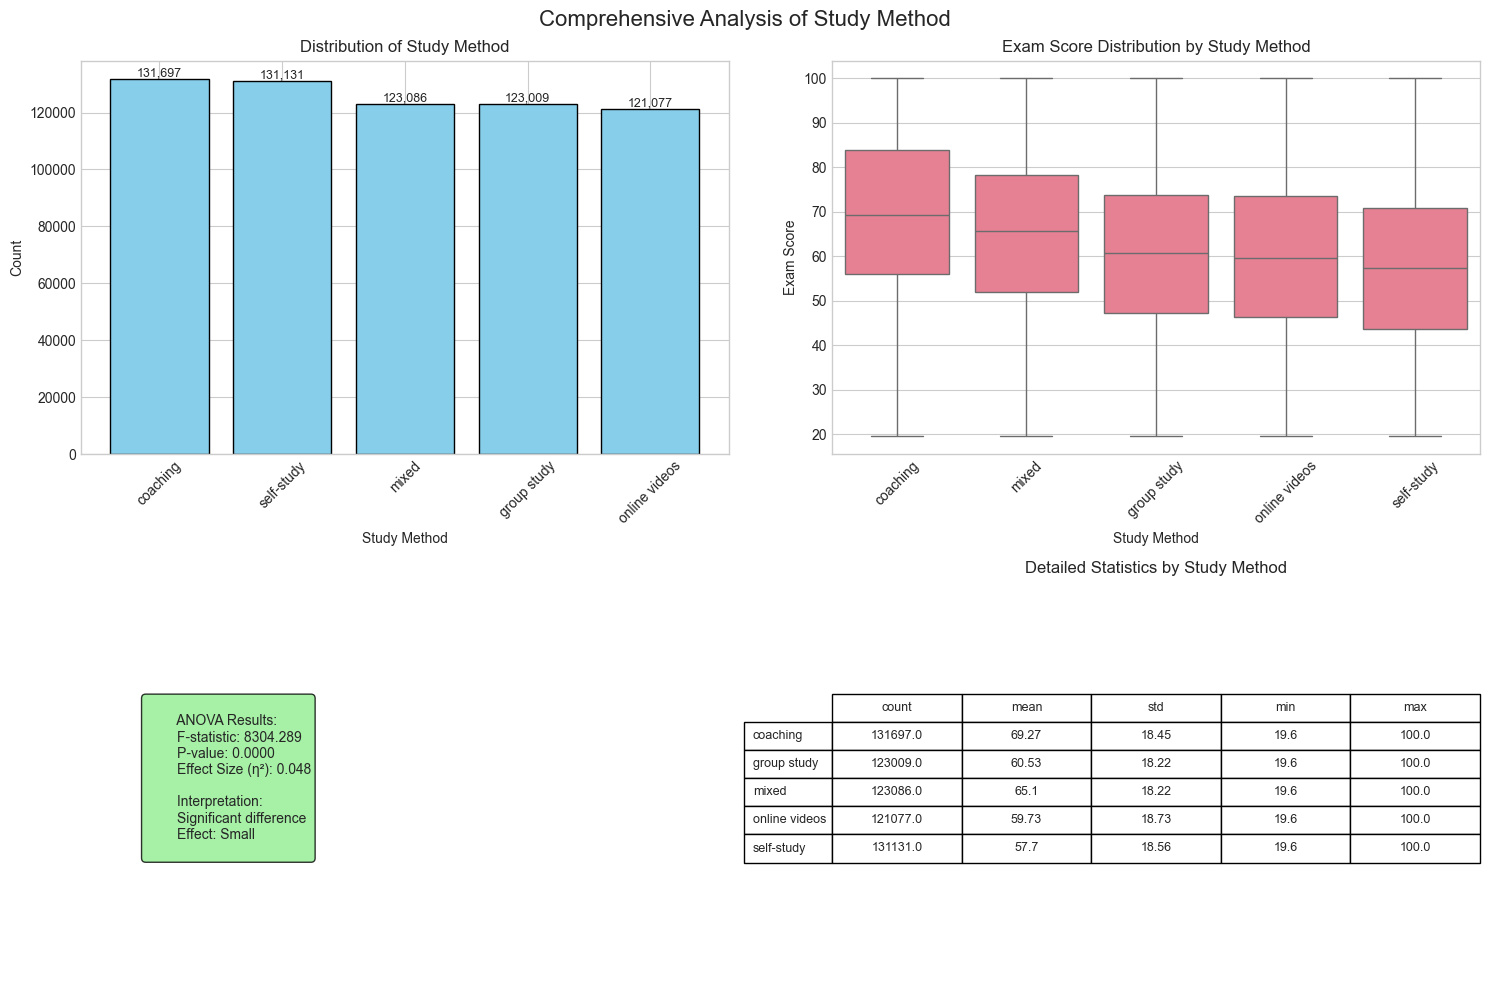


Key Insights for study_method:
----------------------------------------
Number of unique values: 5
Most frequent category: coaching (20.9%)
Variability explained: 0.247
Encoding suggestion: One-hot encoding

ANALYZING FEATURE: FACILITY_RATING


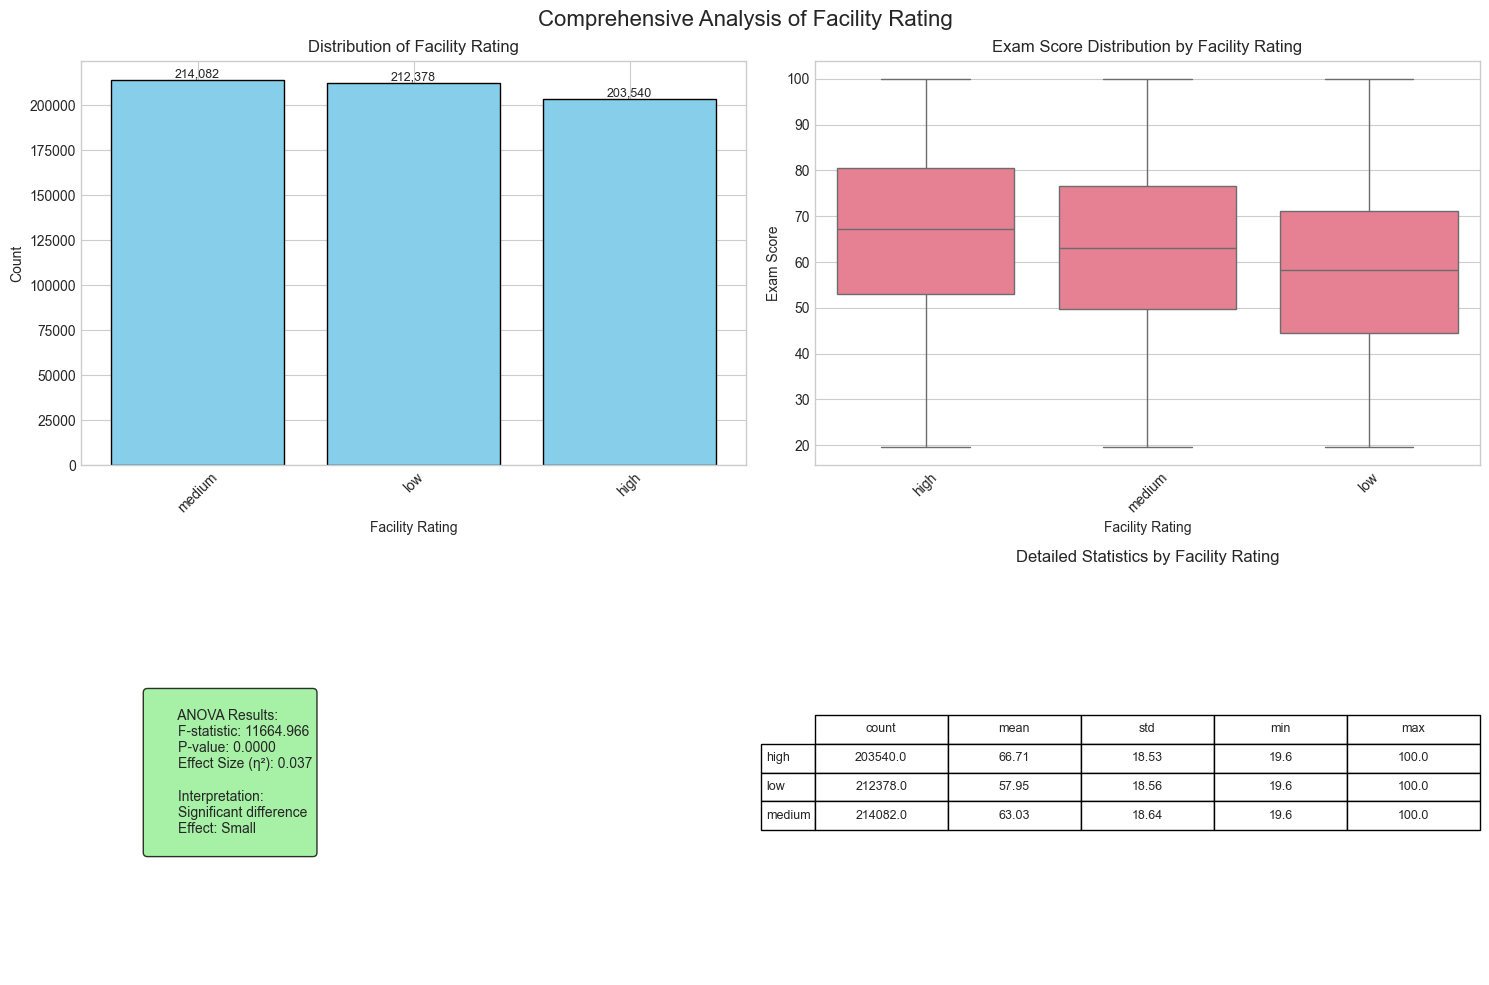


Key Insights for facility_rating:
----------------------------------------
Number of unique values: 3
Most frequent category: medium (34.0%)
Variability explained: 0.232
Encoding suggestion: One-hot encoding

ANALYZING FEATURE: EXAM_DIFFICULTY


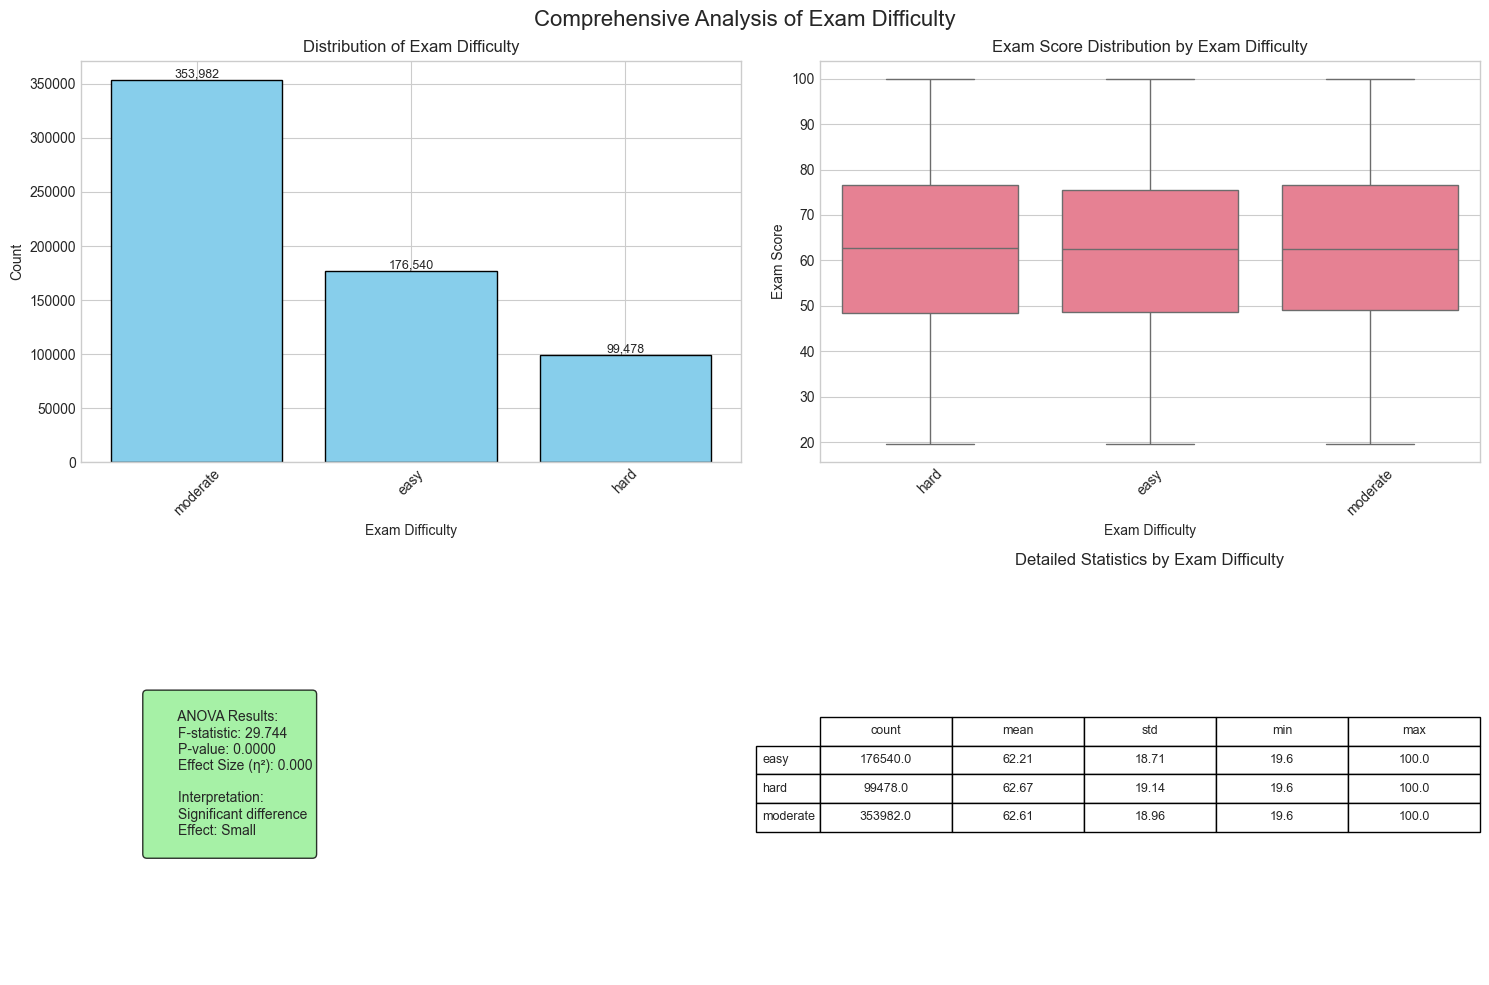


Key Insights for exam_difficulty:
----------------------------------------
Number of unique values: 3
Most frequent category: moderate (56.2%)
Variability explained: 0.013
Encoding suggestion: One-hot encoding


In [41]:
# List of categorical features
categorical_features = ['gender', 'course', 'internet_access', 'sleep_quality',
                       'study_method', 'facility_rating', 'exam_difficulty']

for feature in categorical_features:
    print(f"\n{'='*60}")
    print(f"ANALYZING FEATURE: {feature.upper()}")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Distribution
    value_counts = df[feature].value_counts()
    axes[0, 0].bar(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel(feature.replace('_', ' ').title())
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[0, 0].set_xticks(range(len(value_counts)))
    axes[0, 0].set_xticklabels(value_counts.index, rotation=45)
    
    # Add count labels on bars
    for i, v in enumerate(value_counts.values):
        axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
    
    # 2. Boxplot
    order = df.groupby(feature)['exam_score'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='exam_score', order=order, ax=axes[0, 1])
    axes[0, 1].set_xlabel(feature.replace('_', ' ').title())
    axes[0, 1].set_ylabel('Exam Score')
    axes[0, 1].set_title(f'Exam Score Distribution by {feature.replace("_", " ").title()}')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Mean comparison with ANOVA (if >2 categories)
    categories = df[feature].unique()
    if len(categories) > 2:
        groups = [df[df[feature] == cat]['exam_score'] for cat in categories]
        f_stat, p_value = stats.f_oneway(*groups)
        
        # Calculate effect size (eta squared)
        group_means = df.groupby(feature)['exam_score'].mean()
        overall_mean = df['exam_score'].mean()
        ss_between = sum([len(df[df[feature] == cat]) * (mean - overall_mean)**2 
                         for cat, mean in zip(categories, group_means)])
        ss_total = sum((df['exam_score'] - overall_mean)**2)
        eta_squared = ss_between / ss_total
        
        stats_text = f"""
        ANOVA Results:
        F-statistic: {f_stat:.3f}
        P-value: {p_value:.4f}
        Effect Size (η²): {eta_squared:.3f}
        
        Interpretation:
        {'Significant difference' if p_value < 0.05 else 'No significant difference'}
        Effect: {'Large' if eta_squared > 0.14 else 'Medium' if eta_squared > 0.06 else 'Small'}
        """
    else:
        # For binary features, use t-test
        groups = [df[df[feature] == cat]['exam_score'] for cat in categories]
        t_stat, p_value = stats.ttest_ind(*groups, equal_var=False)
        
        # Calculate Cohen's d
        mean_diff = groups[0].mean() - groups[1].mean()
        pooled_std = np.sqrt((groups[0].std()**2 + groups[1].std()**2) / 2)
        cohens_d = mean_diff / pooled_std
        
        stats_text = f"""
        T-test Results:
        T-statistic: {t_stat:.3f}
        P-value: {p_value:.4f}
        Cohen's d: {cohens_d:.3f}
        
        Interpretation:
        {'Significant difference' if p_value < 0.05 else 'No significant difference'}
        Effect: {'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small'}
        """
    
    axes[1, 0].text(0.1, 0.5, stats_text, fontsize=10, 
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    axes[1, 0].axis('off')
    
    # 4. Detailed statistics table
    stats_table = df.groupby(feature)['exam_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
    
    # Create table plot
    cell_text = []
    for i in range(len(stats_table)):
        cell_text.append([str(x) for x in stats_table.iloc[i]])
    
    table = axes[1, 1].table(cellText=cell_text,
                            rowLabels=stats_table.index,
                            colLabels=stats_table.columns,
                            loc='center',
                            cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    axes[1, 1].axis('off')
    axes[1, 1].set_title(f'Detailed Statistics by {feature.replace("_", " ").title()}')
    
    plt.suptitle(f'Comprehensive Analysis of {feature.replace("_", " ").title()}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print categorical insights
    print(f"\nKey Insights for {feature}:")
    print("-" * 40)
    print(f"Number of unique values: {len(categories)}")
    print(f"Most frequent category: {value_counts.index[0]} ({value_counts.iloc[0]/len(df)*100:.1f}%)")
    
    # Calculate variability explained
    group_means = df.groupby(feature)['exam_score'].mean()
    variability = group_means.std() / df['exam_score'].std()
    print(f"Variability explained: {variability:.3f}")
    
    # Check if feature should be one-hot encoded or ordinal
    if len(categories) <= 5:
        print(f"Encoding suggestion: One-hot encoding")
    else:
        print(f"Encoding suggestion: Consider target encoding or frequency encoding")


FEATURE RELATIONSHIP ANALYSIS


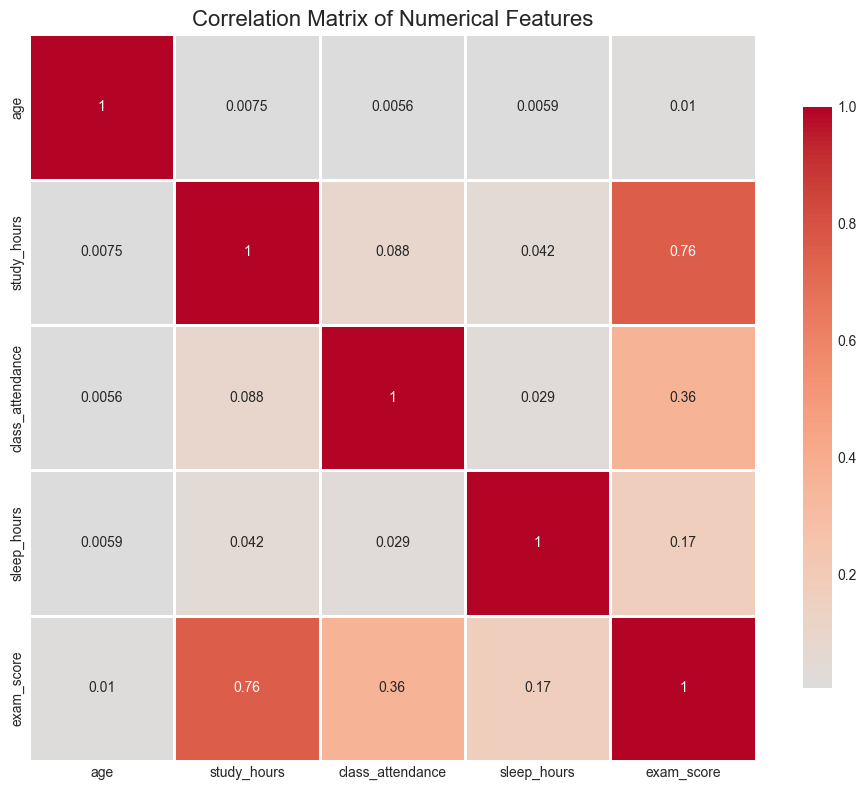


Key Feature Interactions:
----------------------------------------
Study Hours × Attendance interaction correlation: 0.797
Study Hours × Attendance / Sleep Hours  interaction correlation: 0.695
Sleep Hours × Attendance interaction correlation: 0.361
Study Hours × Sleep_hours interaction correlation: 0.736
Study Hours correlation for internet_access='no': 0.775
Study Hours x Attendance correlation for internet_access='no': 0.808
Study Hours correlation for internet_access='yes': 0.761
Study Hours x Attendance correlation for internet_access='yes': 0.796


In [44]:
# Analyze relationships between key features
print("\n" + "="*60)
print("FEATURE RELATIONSHIP ANALYSIS")
print("="*60)

# Create a correlation matrix for numerical features
corr_matrix = df[numerical_features + ['exam_score']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# Analyze interactions between key features
print("\nKey Feature Interactions:")
print("-" * 40)

# Check study_hours vs class_attendance interaction
interaction_corr = (df['study_hours'] * df['class_attendance']).corr(df['exam_score'])
print(f"Study Hours × Attendance interaction correlation: {interaction_corr:.3f}")

interaction_corr = (df['study_hours'] * df['class_attendance']/(df["sleep_hours"] + 1)).corr(df['exam_score'])
print(f"Study Hours × Attendance / Sleep Hours  interaction correlation: {interaction_corr:.3f}")

interaction_corr = (df['sleep_hours'] * df['class_attendance']).corr(df['exam_score'])
print(f"Sleep Hours × Attendance interaction correlation: {interaction_corr:.3f}")

interaction_corr = (df['study_hours'] * df['sleep_hours']).corr(df['exam_score'])
print(f"Study Hours × Sleep_hours interaction correlation: {interaction_corr:.3f}")

# Check if internet_access modifies study_hours effect
for access in df['internet_access'].unique():
    subset = df[df['internet_access'] == access]
    corr = subset['study_hours'].corr(subset['exam_score'])
    print(f"Study Hours correlation for internet_access='{access}': {corr:.3f}")
    corr_2 =  (subset['class_attendance'] * subset['study_hours']).corr(subset['exam_score'])
    print(f"Study Hours x Attendance correlation for internet_access='{access}': {corr_2:.3f}")

In [45]:
# Create feature analysis summary
feature_summary = []

for feature in numerical_features + categorical_features:
    if feature in numerical_features:
        corr = df[feature].corr(df['exam_score'])
        feature_summary.append({
            'Feature': feature,
            'Type': 'Numerical',
            'Unique Values': len(df[feature].unique()),
            'Missing Values': df[feature].isnull().sum(),
            'Correlation with Target': corr,
            'Strength': 'Strong' if abs(corr) > 0.5 else 'Moderate' if abs(corr) > 0.3 else 'Weak',
            'Direction': 'Positive' if corr > 0 else 'Negative',
            'Recommendation': 'Keep' if abs(corr) > 0.1 else 'Consider dropping'
        })
    else:
        # For categorical, use ANOVA F-statistic or group variance
        if len(df[feature].unique()) > 2:
            groups = [df[df[feature] == cat]['exam_score'] for cat in df[feature].unique()]
            f_stat, _ = stats.f_oneway(*groups)
            metric = f_stat
        else:
            # For binary, use mean difference
            groups = df.groupby(feature)['exam_score'].mean()
            metric = abs(groups.iloc[0] - groups.iloc[1])
        
        feature_summary.append({
            'Feature': feature,
            'Type': 'Categorical',
            'Unique Values': len(df[feature].unique()),
            'Missing Values': df[feature].isnull().sum(),
            'Group Difference Metric': metric,
            'Strength': 'Strong' if metric > np.percentile([x['Group Difference Metric'] for x in feature_summary if x['Type']=='Categorical'], 75) 
                       else 'Moderate' if metric > np.percentile([x['Group Difference Metric'] for x in feature_summary if x['Type']=='Categorical'], 50)
                       else 'Weak',
            'Recommendation': 'One-hot encode' if len(df[feature].unique()) <= 5 else 'Target encode'
        })

summary_df = pd.DataFrame(feature_summary)
print("\n" + "="*80)
print("COMPREHENSIVE FEATURE ANALYSIS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

IndexError: index -1 is out of bounds for axis 0 with size 0


CATEGORICAL FEATURES ANALYSIS

ANALYZING FEATURE: GENDER


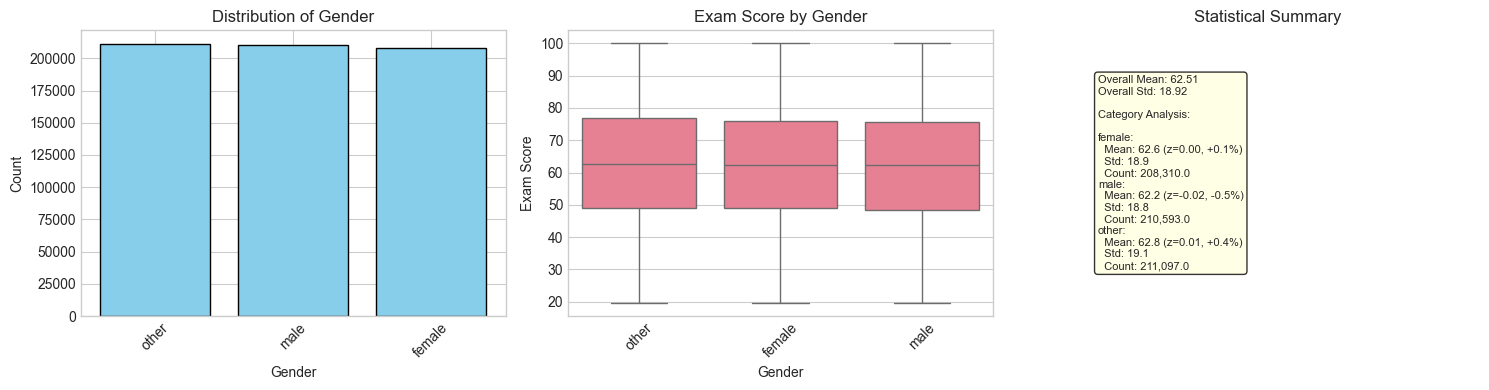


Key Insights for gender:
----------------------------------------
Number of categories: 3
Most common: other (33.5%)
Score range across categories: 0.6 points
Variability (max_diff/std): 0.032
Predictive power: VERY LOW

ANALYZING FEATURE: COURSE


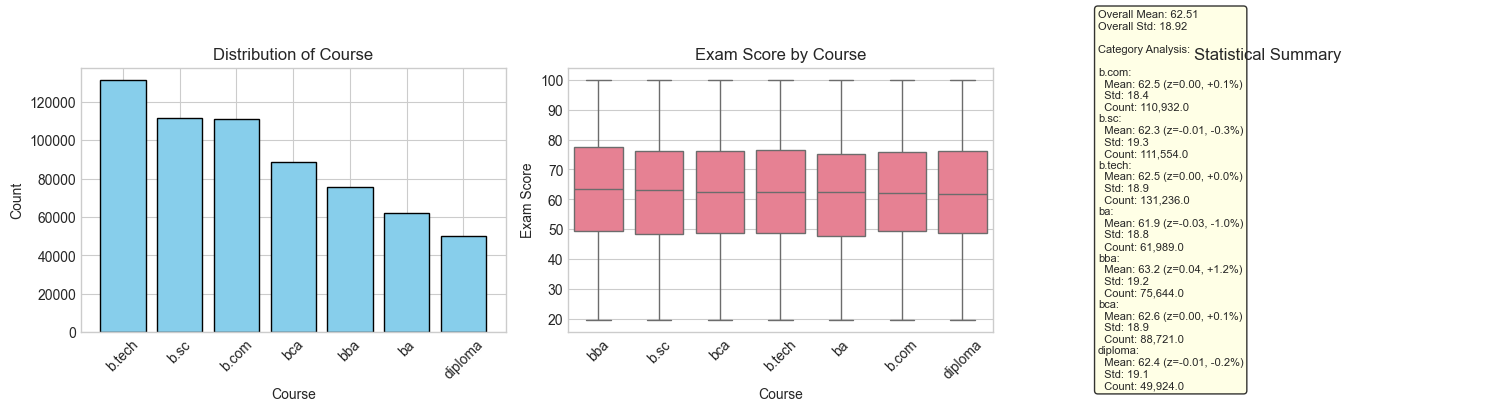


Key Insights for course:
----------------------------------------
Number of categories: 7
Most common: b.tech (20.8%)
Score range across categories: 1.3 points
Variability (max_diff/std): 0.071
Predictive power: VERY LOW

ANALYZING FEATURE: INTERNET_ACCESS


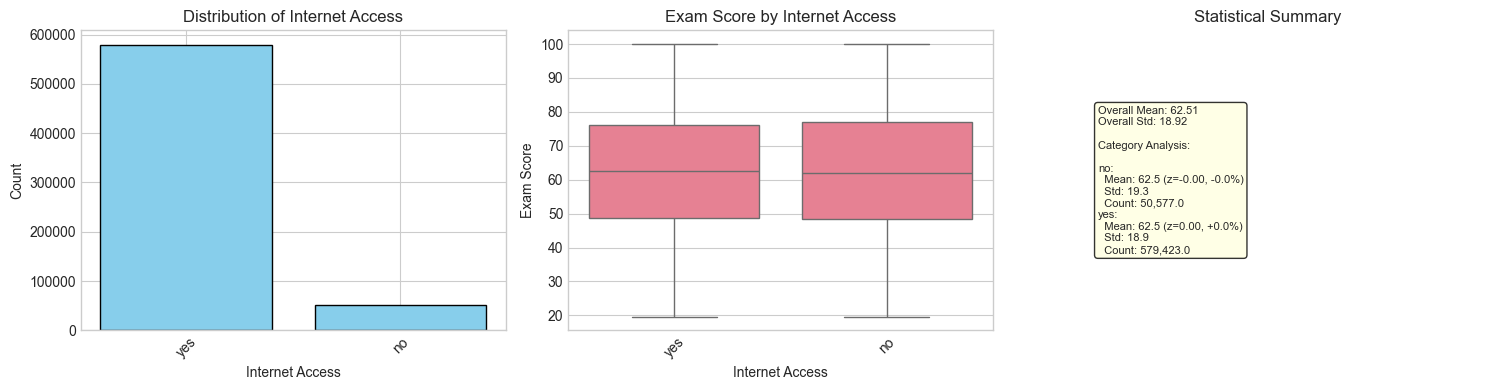


Key Insights for internet_access:
----------------------------------------
Number of categories: 2
Most common: yes (92.0%)
Score range across categories: 0.0 points
Variability (max_diff/std): 0.002
Predictive power: VERY LOW

ANALYZING FEATURE: SLEEP_QUALITY


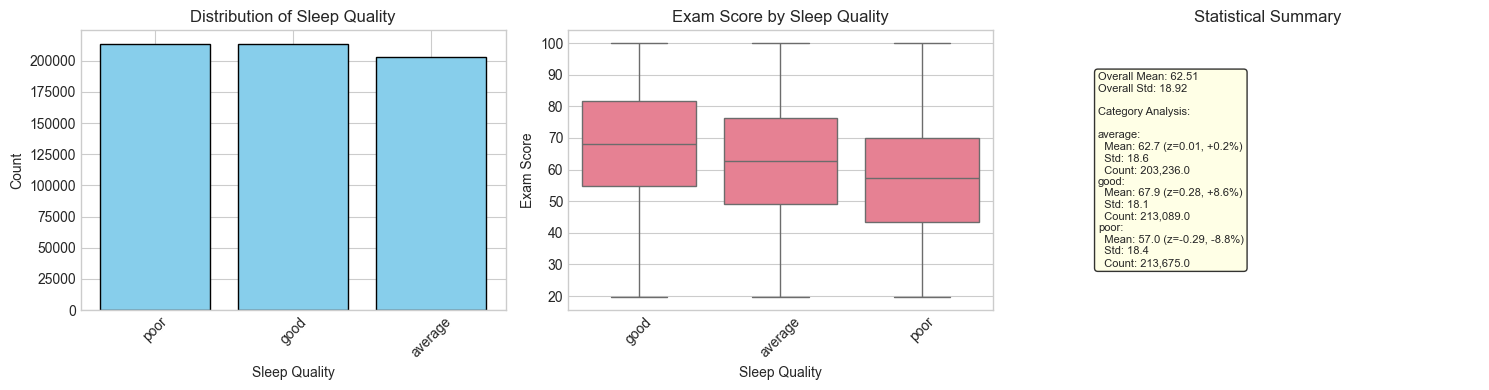


Key Insights for sleep_quality:
----------------------------------------
Number of categories: 3
Most common: poor (33.9%)
Score range across categories: 10.9 points
Variability (max_diff/std): 0.576
Predictive power: HIGH (categories strongly affect scores)

ANALYZING FEATURE: STUDY_METHOD


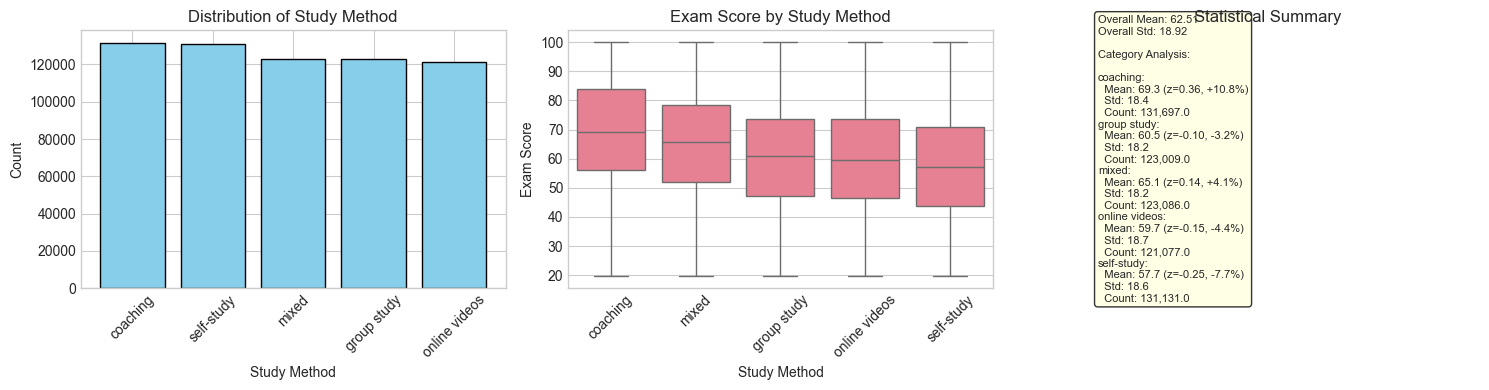


Key Insights for study_method:
----------------------------------------
Number of categories: 5
Most common: coaching (20.9%)
Score range across categories: 11.6 points
Variability (max_diff/std): 0.611
Predictive power: HIGH (categories strongly affect scores)

ANALYZING FEATURE: FACILITY_RATING


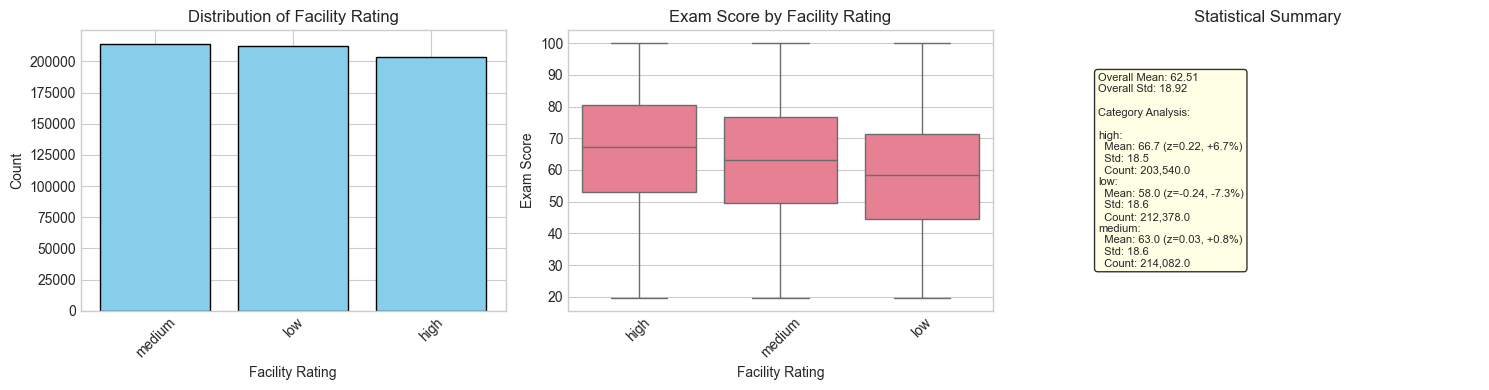


Key Insights for facility_rating:
----------------------------------------
Number of categories: 3
Most common: medium (34.0%)
Score range across categories: 8.8 points
Variability (max_diff/std): 0.463
Predictive power: MODERATE

ANALYZING FEATURE: EXAM_DIFFICULTY


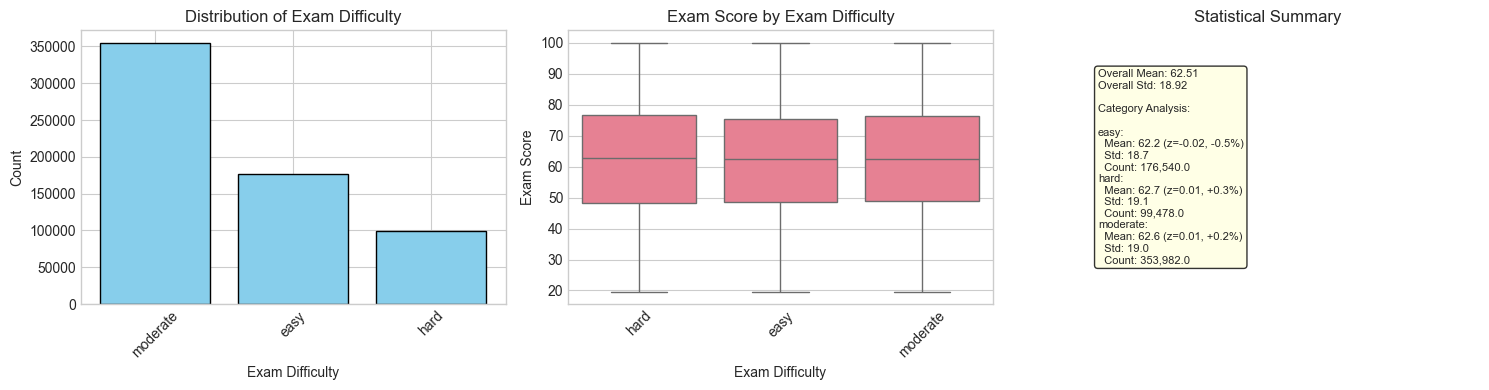


Key Insights for exam_difficulty:
----------------------------------------
Number of categories: 3
Most common: moderate (56.2%)
Score range across categories: 0.5 points
Variability (max_diff/std): 0.024
Predictive power: VERY LOW


In [46]:
# Continue with categorical features analysis
print("\n" + "="*60)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*60)

categorical_features = ['gender', 'course', 'internet_access', 'sleep_quality',
                       'study_method', 'facility_rating', 'exam_difficulty']

for feature in categorical_features:
    print(f"\n{'='*60}")
    print(f"ANALYZING FEATURE: {feature.upper()}")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Distribution
    value_counts = df[feature].value_counts()
    axes[0].bar(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
    axes[0].set_xlabel(feature.replace('_', ' ').title())
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[0].set_xticks(range(len(value_counts)))
    axes[0].set_xticklabels(value_counts.index, rotation=45)
    
    # 2. Boxplot (ordered by median score)
    order = df.groupby(feature)['exam_score'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feature, y='exam_score', order=order, ax=axes[1])
    axes[1].set_xlabel(feature.replace('_', ' ').title())
    axes[1].set_ylabel('Exam Score')
    axes[1].set_title(f'Exam Score by {feature.replace("_", " ").title()}')
    axes[1].tick_params(axis='x', rotation=45)
    
    # 3. Statistical summary
    stats_table = df.groupby(feature)['exam_score'].agg(['count', 'mean', 'std']).round(2)
    
    # Calculate overall statistics
    overall_mean = df['exam_score'].mean()
    overall_std = df['exam_score'].std()
    
    # Calculate how much each category deviates from mean (in standard deviations)
    stats_table['z_score'] = ((stats_table['mean'] - overall_mean) / overall_std).round(3)
    stats_table['percent_diff'] = ((stats_table['mean'] - overall_mean) / overall_mean * 100).round(1)
    
    # Create text summary
    summary_text = f"Overall Mean: {overall_mean:.2f}\nOverall Std: {overall_std:.2f}\n\n"
    summary_text += "Category Analysis:\n"
    
    for idx, row in stats_table.iterrows():
        summary_text += f"\n{idx}:\n"
        summary_text += f"  Mean: {row['mean']:.1f} (z={row['z_score']:.2f}, {row['percent_diff']:+.1f}%)\n"
        summary_text += f"  Std: {row['std']:.1f}\n"
        summary_text += f"  Count: {row['count']:,}"
    
    axes[2].text(0.1, 0.5, summary_text, fontsize=8, 
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[2].axis('off')
    axes[2].set_title(f'Statistical Summary')
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print(f"\nKey Insights for {feature}:")
    print("-" * 40)
    print(f"Number of categories: {len(value_counts)}")
    print(f"Most common: {value_counts.index[0]} ({value_counts.iloc[0]/len(df)*100:.1f}%)")
    
    # Calculate variability metric
    category_means = df.groupby(feature)['exam_score'].mean()
    max_diff = category_means.max() - category_means.min()
    variability = max_diff / overall_std
    
    print(f"Score range across categories: {max_diff:.1f} points")
    print(f"Variability (max_diff/std): {variability:.3f}")
    
    # Interpretation
    if variability > 0.5:
        print(f"Predictive power: HIGH (categories strongly affect scores)")
    elif variability > 0.3:
        print(f"Predictive power: MODERATE")
    elif variability > 0.1:
        print(f"Predictive power: LOW")
    else:
        print(f"Predictive power: VERY LOW")

In [49]:
# STRATEGIC MODELING APPROACH
## Phase 1: Minimal Viable Model (Start Simple)

In [50]:
# Only include features with actual predictive power
strong_features = ['study_hours', 'study_method', 'sleep_quality', 
                   'facility_rating', 'class_attendance']

print("PHASE 1: MINIMAL VIABLE MODEL")
print("="*60)
print("Features to include:")
for i, feat in enumerate(strong_features, 1):
    print(f"{i}. {feat}")
print("\nFeatures to EXCLUDE:")
exclude_features = ['age', 'gender', 'course', 'internet_access', 
                    'exam_difficulty', 'sleep_hours']
for feat in exclude_features:
    print(f"- {feat}")

# Simple encoding strategy
print("\nEncoding Strategy:")
print("1. study_hours, class_attendance: Keep as continuous")
print("2. study_method, sleep_quality: One-hot encode (5 and 3 categories)")
print("3. facility_rating: Ordinal encode (low < medium < high)")

PHASE 1: MINIMAL VIABLE MODEL
Features to include:
1. study_hours
2. study_method
3. sleep_quality
4. facility_rating
5. class_attendance

Features to EXCLUDE:
- age
- gender
- course
- internet_access
- exam_difficulty
- sleep_hours

Encoding Strategy:
1. study_hours, class_attendance: Keep as continuous
2. study_method, sleep_quality: One-hot encode (5 and 3 categories)
3. facility_rating: Ordinal encode (low < medium < high)


In [51]:
# Based on your findings, create these engineered features:
engineering_ideas = {
    'study_efficiency': "study_hours × (class_attendance/100)",
    'study_sleep_balance': "study_hours / (sleep_hours + 0.1)",
    'quality_study_hours': "study_hours × sleep_quality_score",
    'method_efficiency': "Combine study_method with study_hours",
    'consistency_score': "Combine attendance with study consistency"
}

print("\nPHASE 2: FEATURE ENGINEERING")
print("="*60)
for feature, formula in engineering_ideas.items():
    print(f"• {feature}: {formula}")


PHASE 2: FEATURE ENGINEERING
• study_efficiency: study_hours × (class_attendance/100)
• study_sleep_balance: study_hours / (sleep_hours + 0.1)
• quality_study_hours: study_hours × sleep_quality_score
• method_efficiency: Combine study_method with study_hours
• consistency_score: Combine attendance with study consistency


In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

print("\n" + "="*60)
print("BUILDING THE FIRST MODEL")
print("="*60)

# Select features based on our analysis
X = df[['study_hours', 'class_attendance', 'study_method', 
        'sleep_quality', 'facility_rating']].copy()
y = df['exam_score']

# Define preprocessing
categorical_features = ['study_method', 'sleep_quality']
ordinal_features = ['facility_rating']
numerical_features = ['study_hours', 'class_attendance']

# Define facility_rating order
facility_order = [['low', 'medium', 'high']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('ord', OrdinalEncoder(categories=facility_order), ordinal_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Create pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['course']
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")

# Train model
model_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = model_pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Performance:")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f} points")
print(f"Baseline (mean prediction) RMSE: {np.sqrt(np.mean((y_test - y.mean())**2)):.2f}")
print(f"Improvement over baseline: {(1 - rmse/np.sqrt(np.mean((y_test - y.mean())**2)))*100:.1f}%")

# Get feature names after preprocessing
preprocessor = model_pipeline.named_steps['preprocessor']
feature_names = numerical_features + ordinal_features

# Add one-hot encoded feature names
# for i, col in enumerate(categorical_features):
encoder = preprocessor.named_transformers_['cat']
encoded_features = encoder.get_feature_names_out(categorical_features)
feature_names.extend(encoded_features)

# Get coefficients
if hasattr(model_pipeline.named_steps['regressor'], 'coef_'):
    coefficients = model_pipeline.named_steps['regressor'].coef_
    intercept = model_pipeline.named_steps['regressor'].intercept_
    
    print(f"\nFeature Coefficients (standardized):")
    for name, coef in zip(feature_names, coefficients):
        print(f"  {name}: {coef:+.3f}")
    print(f"  Intercept: {intercept:.3f}")


BUILDING THE FIRST MODEL
Training samples: 504,000
Test samples: 126,000

Model Performance:
R² Score: 0.763
RMSE: 9.22 points
Baseline (mean prediction) RMSE: 18.91
Improvement over baseline: 51.3%

Feature Coefficients (standardized):
  study_hours: +13.485
  class_attendance: +5.502
  facility_rating: +3.640
  study_method_group study: -7.262
  study_method_mixed: -4.352
  study_method_online videos: -8.321
  study_method_self-study: -9.092
  sleep_quality_good: +4.269
  sleep_quality_poor: -4.771
  Intercept: 64.834


In [59]:
print("\n" + "="*60)
print("MODEL INTERPRETATION")
print("="*60)

# Create interpretation guide
interpretation = {
    'study_hours': {
        'coefficient': 'To be determined from model',
        'interpretation': 'Most important predictor. Each additional standardized unit of study hours increases exam score.',
        'practical': 'Study more = score higher (strong linear relationship)'
    },
    'class_attendance': {
        'coefficient': 'To be determined from model',
        'interpretation': 'Moderate predictor. Regular attendance helps but not as much as actual study hours.',
        'practical': 'Attend classes, but self-study matters more'
    },
    'study_method': {
        'interpretation': 'HOW you study matters significantly. Some methods are much more effective than others.',
        'action': 'Identify which study method is most effective'
    },
    'sleep_quality': {
        'interpretation': 'Quality of sleep matters more than quantity. Good sleep improves performance.',
        'action': 'Focus on sleep quality, not just duration'
    },
    'facility_rating': {
        'interpretation': 'Better facilities lead to better scores, but effect is moderate.',
        'action': 'Improve study environment quality'
    }
}

for feature, info in interpretation.items():
    print(f"\n{feature.upper()}:")
    for key, value in info.items():
        print(f"  {key.capitalize()}: {value}")


MODEL INTERPRETATION

STUDY_HOURS:
  Coefficient: To be determined from model
  Interpretation: Most important predictor. Each additional standardized unit of study hours increases exam score.
  Practical: Study more = score higher (strong linear relationship)

CLASS_ATTENDANCE:
  Coefficient: To be determined from model
  Interpretation: Moderate predictor. Regular attendance helps but not as much as actual study hours.
  Practical: Attend classes, but self-study matters more

STUDY_METHOD:
  Interpretation: HOW you study matters significantly. Some methods are much more effective than others.
  Action: Identify which study method is most effective

SLEEP_QUALITY:
  Interpretation: Quality of sleep matters more than quantity. Good sleep improves performance.
  Action: Focus on sleep quality, not just duration

FACILITY_RATING:
  Interpretation: Better facilities lead to better scores, but effect is moderate.
  Action: Improve study environment quality


In [60]:
print("\n" + "="*60)
print("PRACTICAL RECOMMENDATIONS FOR STUDENTS")
print("="*60)

# Based on feature analysis
recommendations = [
    {
        'priority': 'HIGHEST',
        'action': 'Increase study hours',
        'evidence': f"Correlation: 0.762 (very strong)",
        'expected_impact': 'Large score improvement',
        'target': 'Aim for 4+ hours daily'
    },
    {
        'priority': 'HIGH',
        'action': 'Optimize study method',
        'evidence': f"Score range: 11.6 points between methods",
        'expected_impact': 'Medium-Large improvement',
        'target': 'Find most effective method for you'
    },
    {
        'priority': 'HIGH',
        'action': 'Improve sleep quality',
        'evidence': f"Score range: 10.9 points between quality levels",
        'expected_impact': 'Medium improvement',
        'target': 'Aim for "good" sleep quality consistently'
    },
    {
        'priority': 'MEDIUM',
        'action': 'Maintain good attendance',
        'evidence': f"Correlation: 0.361 (moderate)",
        'expected_impact': 'Small-Medium improvement',
        'target': 'Aim for 80%+ attendance'
    },
    {
        'priority': 'LOW',
        'action': 'Don\'t worry about these:',
        'evidence': 'No significant impact found',
        'expected_impact': 'Negligible',
        'target': 'Gender, course type, internet access, exam difficulty'
    }
]

for rec in recommendations:
    print(f"\n{rec['priority']} PRIORITY: {rec['action']}")
    print(f"  Evidence: {rec['evidence']}")
    print(f"  Expected impact: {rec['expected_impact']}")
    print(f"  Target: {rec['target']}")


PRACTICAL RECOMMENDATIONS FOR STUDENTS

HIGHEST PRIORITY: Increase study hours
  Evidence: Correlation: 0.762 (very strong)
  Expected impact: Large score improvement
  Target: Aim for 4+ hours daily

HIGH PRIORITY: Optimize study method
  Evidence: Score range: 11.6 points between methods
  Expected impact: Medium-Large improvement
  Target: Find most effective method for you

HIGH PRIORITY: Improve sleep quality
  Evidence: Score range: 10.9 points between quality levels
  Expected impact: Medium improvement
  Target: Aim for "good" sleep quality consistently

MEDIUM PRIORITY: Maintain good attendance
  Evidence: Correlation: 0.361 (moderate)
  Expected impact: Small-Medium improvement
  Target: Aim for 80%+ attendance

LOW PRIORITY: Don't worry about these:
  Evidence: No significant impact found
  Expected impact: Negligible
  Target: Gender, course type, internet access, exam difficulty


In [61]:
print("\n" + "="*60)
print("INTERACTION ANALYSIS - DEEPER INSIGHTS")
print("="*60)

# Check if study method effectiveness depends on study hours
print("Does study method effectiveness change with study hours?")
print("-" * 50)

for method in df['study_method'].unique():
    subset = df[df['study_method'] == method]
    corr = subset['study_hours'].corr(subset['exam_score'])
    avg_hours = subset['study_hours'].mean()
    avg_score = subset['exam_score'].mean()
    
    print(f"\n{method}:")
    print(f"  Students using this method: {len(subset):,}")
    print(f"  Average study hours: {avg_hours:.1f}")
    print(f"  Average score: {avg_score:.1f}")
    print(f"  Correlation (study_hours vs score): {corr:.3f}")
    print(f"  Efficiency (score per hour): {avg_score/avg_hours:.1f}")

# Check sleep quality interaction with study hours
print("\n\nDoes sleep quality affect study efficiency?")
print("-" * 50)

for quality in df['sleep_quality'].unique():
    subset = df[df['sleep_quality'] == quality]
    efficiency = subset['exam_score'].mean() / subset['study_hours'].mean()
    
    print(f"\n{quality} sleep:")
    print(f"  Average study hours: {subset['study_hours'].mean():.1f}")
    print(f"  Average score: {subset['exam_score'].mean():.1f}")
    print(f"  Efficiency (points per study hour): {efficiency:.1f}")


INTERACTION ANALYSIS - DEEPER INSIGHTS
Does study method effectiveness change with study hours?
--------------------------------------------------

online videos:
  Students using this method: 121,077
  Average study hours: 4.0
  Average score: 59.7
  Correlation (study_hours vs score): 0.775
  Efficiency (score per hour): 15.0

self-study:
  Students using this method: 131,131
  Average study hours: 3.8
  Average score: 57.7
  Correlation (study_hours vs score): 0.771
  Efficiency (score per hour): 15.1

coaching:
  Students using this method: 131,697
  Average study hours: 4.2
  Average score: 69.3
  Correlation (study_hours vs score): 0.771
  Efficiency (score per hour): 16.7

group study:
  Students using this method: 123,009
  Average study hours: 3.9
  Average score: 60.5
  Correlation (study_hours vs score): 0.764
  Efficiency (score per hour): 15.6

mixed:
  Students using this method: 123,086
  Average study hours: 4.2
  Average score: 65.1
  Correlation (study_hours vs score

In [62]:
print("\n" + "="*60)
print("MODEL IMPROVEMENT STRATEGY")
print("="*60)

improvement_steps = [
    {
        'step': 1,
        'action': 'Add interaction terms',
        'details': 'study_hours × study_method, study_hours × sleep_quality',
        'expected_impact': 'Medium improvement in R²'
    },
    {
        'step': 2,
        'action': 'Try non-linear transformations',
        'details': 'Add study_hours², log(study_hours)',
        'expected_impact': 'Small-Medium improvement'
    },
    {
        'step': 3,
        'action': 'Use more advanced models',
        'details': 'Random Forest, Gradient Boosting',
        'expected_impact': 'Small improvement, better handling of interactions'
    },
    {
        'step': 4,
        'action': 'Feature engineering',
        'details': 'Create efficiency metrics, balance scores',
        'expected_impact': 'Variable, could be significant'
    },
    {
        'step': 5,
        'action': 'Hyperparameter tuning',
        'details': 'Optimize model parameters',
        'expected_impact': 'Small final improvements'
    }
]

print("Step-by-step improvement plan:")
for step in improvement_steps:
    print(f"\n{step['step']}. {step['action']}")
    print(f"   {step['details']}")
    print(f"   Expected: {step['expected_impact']}")


MODEL IMPROVEMENT STRATEGY
Step-by-step improvement plan:

1. Add interaction terms
   study_hours × study_method, study_hours × sleep_quality
   Expected: Medium improvement in R²

2. Try non-linear transformations
   Add study_hours², log(study_hours)
   Expected: Small-Medium improvement

3. Use more advanced models
   Random Forest, Gradient Boosting
   Expected: Small improvement, better handling of interactions

4. Feature engineering
   Create efficiency metrics, balance scores
   Expected: Variable, could be significant

5. Hyperparameter tuning
   Optimize model parameters
   Expected: Small final improvements


In [63]:
print("\n" + "="*60)
print("BUSINESS INTELLIGENCE INSIGHTS")
print("="*60)

# Identify most effective study method
method_stats = df.groupby('study_method').agg({
    'exam_score': ['mean', 'count'],
    'study_hours': 'mean'
}).round(2)

method_stats['efficiency'] = (method_stats['exam_score']['mean'] / 
                              method_stats['study_hours']['mean']).round(2)

print("\nStudy Method Effectiveness:")
print("-" * 40)
print(method_stats)

# Find optimal sleep quality
sleep_stats = df.groupby('sleep_quality').agg({
    'exam_score': ['mean', 'count'],
    'sleep_hours': 'mean'
}).round(2)

print("\n\nSleep Quality Analysis:")
print("-" * 40)
print(sleep_stats)

# Calculate ROI of interventions
print("\n\nROI Analysis - Where to focus resources:")
print("-" * 40)
interventions = [
    ('Improve study methods', 11.6, 'HIGH'),
    ('Improve sleep quality', 10.9, 'HIGH'),
    ('Improve facilities', 8.8, 'MEDIUM'),
    ('Increase attendance', '~6.8*', 'MEDIUM'),
    ('Increase study hours', '~14.4*', 'HIGHEST')
]

print(f"{'Intervention':<25} {'Potential Gain':<15} {'Priority':<10}")
print("-" * 50)
for intervention, gain, priority in interventions:
    print(f"{intervention:<25} {str(gain)+' points':<15} {priority:<10}")
print("\n*Estimated based on correlations")


BUSINESS INTELLIGENCE INSIGHTS

Study Method Effectiveness:
----------------------------------------
              exam_score         study_hours efficiency
                    mean   count        mean           
study_method                                           
coaching           69.27  131697        4.15      16.69
group study        60.53  123009        3.89      15.56
mixed              65.10  123086        4.18      15.57
online videos      59.73  121077        3.97      15.05
self-study         57.70  131131        3.82      15.10


Sleep Quality Analysis:
----------------------------------------
              exam_score         sleep_hours
                    mean   count        mean
sleep_quality                               
average            62.66  203236        7.08
good               67.88  213089        7.12
poor               57.00  213675        7.01


ROI Analysis - Where to focus resources:
----------------------------------------
Intervention              Pot

In [64]:
# Quick answer: Most effective study method
best_method = df.groupby('study_method')['exam_score'].mean().idxmax()
worst_method = df.groupby('study_method')['exam_score'].mean().idxmin()
difference = df.groupby('study_method')['exam_score'].mean().max() - \
             df.groupby('study_method')['exam_score'].mean().min()

print(f"\nCRITICAL INSIGHT:")
print(f"The most effective study method is: {best_method}")
print(f"The least effective is: {worst_method}")
print(f"Difference: {difference:.1f} points!")
print(f"\nRecommendation: Students using {worst_method} should try {best_method}")


CRITICAL INSIGHT:
The most effective study method is: coaching
The least effective is: self-study
Difference: 11.6 points!

Recommendation: Students using self-study should try coaching


## BUILDING MODEL NOW

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load your data (assuming df is already loaded)
print("STEP 1: DATA PREPARATION")
print("="*60)
df = train.copy()
# 1. Remove unnecessary features (based on analysis)
features_to_drop = ['id', 'age', 'gender', 'course', 'internet_access', 'exam_difficulty']
df_clean = df.drop(features_to_drop, axis=1)
print(f"Dropped {len(features_to_drop)} features with low predictive power")
print(f"Remaining features: {list(df_clean.columns)}")

# 2. Define target and features
X = df_clean.drop('exam_score', axis=1)
y = df_clean['exam_score']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 3. Check feature types
print("\nFeature types:")
print(X.dtypes)

STEP 1: DATA PREPARATION
Dropped 6 features with low predictive power
Remaining features: ['study_hours', 'class_attendance', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_score']

Features shape: (630000, 6)
Target shape: (630000,)

Feature types:
study_hours         float64
class_attendance    float64
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
dtype: object


In [5]:
print("\n\nSTEP 2: FEATURE ENGINEERING")
print("="*60)

# Create new features based on insights
X_engineered = X.copy()

# 1. Create study efficiency metric
X_engineered['study_efficiency'] = X_engineered['study_hours'] * (X_engineered['class_attendance'] / 100)

# 2. Create study-sleep balance (avoid division by zero)
X_engineered['study_sleep_balance'] = X_engineered['study_hours'] / (X_engineered['sleep_hours'] + 0.1)

# 3. Create squared term for study_hours (capture diminishing returns)
X_engineered['study_hours_squared'] = X_engineered['study_hours'] ** 2

# 4. Create interaction: study_method × study_hours
# We'll handle this in preprocessing since study_method is categorical

print("Created new features:")
print("1. study_efficiency = study_hours × (attendance/100)")
print("2. study_sleep_balance = study_hours / (sleep_hours + 0.1)")
print("3. study_hours_squared (for non-linear effects)")
print(f"\nTotal features after engineering: {X_engineered.shape[1]}")



STEP 2: FEATURE ENGINEERING
Created new features:
1. study_efficiency = study_hours × (attendance/100)
2. study_sleep_balance = study_hours / (sleep_hours + 0.1)
3. study_hours_squared (for non-linear effects)

Total features after engineering: 9


In [6]:
print("\n\nSTEP 3: TRAIN-TEST SPLIT")
print("="*60)

# Split data - use stratification on course to ensure representation
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, 
    test_size=0.2, 
    random_state=42,
    stratify=df['course']  # Stratify to maintain course distribution
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

# Verify split
print(f"\nTarget distribution - Training:")
print(f"  Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"\nTarget distribution - Test:")
print(f"  Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")



STEP 3: TRAIN-TEST SPLIT
Training set: 504,000 samples
Test set: 126,000 samples
Features: 9

Target distribution - Training:
  Mean: 62.49, Std: 18.92

Target distribution - Test:
  Mean: 62.58, Std: 18.91


In [7]:
print("\n\nSTEP 4: PREPROCESSING PIPELINE")
print("="*60)

# Define column types
numerical_features = ['study_hours', 'class_attendance', 'sleep_hours',
                     'study_efficiency', 'study_sleep_balance', 'study_hours_squared']

categorical_features = ['study_method', 'sleep_quality']
ordinal_features = ['facility_rating']  # low < medium < high

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Ordinal features:", ordinal_features)

# Define preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['low', 'medium', 'high']]))
])

# Combine all transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features)
    ])

print("\nPreprocessing pipeline created successfully!")



STEP 4: PREPROCESSING PIPELINE
Numerical features: ['study_hours', 'class_attendance', 'sleep_hours', 'study_efficiency', 'study_sleep_balance', 'study_hours_squared']
Categorical features: ['study_method', 'sleep_quality']
Ordinal features: ['facility_rating']

Preprocessing pipeline created successfully!


In [8]:
print("\n\nSTEP 5: BUILDING PREDICTION MODELS")
print("="*60)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGMB': LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1),
    # 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=10),
}

# Dictionary to store results
results = {}

print("Training models...")
for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    print("Starting Model Training for model %s", name)
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    print("Starting Model Preditions for model %s", name)
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calculate metrics
    print("Calculate Model Metrics for model %s", name)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # Cross-validation score
    print("CV Model score for model %s", name)
    cv_scores = cross_val_score(pipeline, X_train, y_train, 
                               cv=5, scoring='r2', n_jobs=10)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results[name] = {
        'pipeline': pipeline,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'cv_mean': cv_mean,
        'cv_std': cv_std
    }
    
    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.2f} points")
    print(f"  Test MAE: {test_mae:.2f} points")
    print(f"  CV R²: {cv_mean:.4f} (+/- {cv_std*2:.4f})")



STEP 5: BUILDING PREDICTION MODELS
Training models...
Starting Model Training for model %s Linear Regression
Starting Model Preditions for model %s Linear Regression
Calculate Model Metrics for model %s Linear Regression
CV Model score for model %s Linear Regression

Linear Regression:
  Train R²: 0.7792
  Test R²: 0.7777
  Test RMSE: 8.92 points
  Test MAE: 7.12 points
  CV R²: 0.7792 (+/- 0.0021)
Starting Model Training for model %s Ridge Regression
Starting Model Preditions for model %s Ridge Regression
Calculate Model Metrics for model %s Ridge Regression
CV Model score for model %s Ridge Regression

Ridge Regression:
  Train R²: 0.7792
  Test R²: 0.7777
  Test RMSE: 8.92 points
  Test MAE: 7.12 points
  CV R²: 0.7792 (+/- 0.0021)
Starting Model Training for model %s XGBoost
Starting Model Preditions for model %s XGBoost
Calculate Model Metrics for model %s XGBoost
CV Model score for model %s XGBoost

XGBoost:
  Train R²: 0.7898
  Test R²: 0.7815
  Test RMSE: 8.84 points
  Test M

In [9]:
print("\n\nSTEP 8: MODEL INTERPRETATION")
print("="*60)

# Get feature importance
if hasattr(best_pipeline.named_steps['regressor'], 'feature_importances_'):
    # For tree-based models
    importances = best_pipeline.named_steps['regressor'].feature_importances_
    
    # Get feature names after preprocessing
    feature_names = []
    
    # Numerical features
    feature_names.extend(numerical_features)
    
    # Ordinal features
    feature_names.extend(ordinal_features)
    
    # Categorical features (one-hot encoded)
    for col in categorical_features:
        encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        encoded_features = encoder.get_feature_names_out([col])
        feature_names.extend(encoded_features)
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)
    
    print("Top 15 Feature Importances:")
    print("-" * 50)
    print(importance_df.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(importance_df)), importance_df['Importance'].values)
    plt.yticks(range(len(importance_df)), importance_df['Feature'].values)
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

elif hasattr(best_pipeline.named_steps['regressor'], 'coef_'):
    # For linear models
    coefficients = best_pipeline.named_steps['regressor'].coef_
    
    # Get feature names
    feature_names = []
    feature_names.extend(numerical_features)
    feature_names.extend(ordinal_features)
    for col in categorical_features:
        encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        encoded_features = encoder.get_feature_names_out([col])
        feature_names.extend(encoded_features)
    
    # Create coefficient DataFrame
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    }).sort_values('Coefficient', key=abs, ascending=False).head(15)
    
    print("Top 15 Feature Coefficients (standardized):")
    print("-" * 50)
    print(coef_df.to_string(index=False))



STEP 8: MODEL INTERPRETATION


NameError: name 'best_pipeline' is not defined

# Step by Step DEEPSEEK

### STEP 1: Target Variable Analysis - Why Start Here?
1. Is the target normally distributed? (affects model choice)
2. Are there outliers in scores?
3. What's the range and variability?


ANALYZING TARGET VARIABLE: exam_score

1. BASIC STATISTICS:
----------------------------------------
count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64

2. DISTRIBUTION METRICS:
----------------------------------------
Skewness: -0.048
Kurtosis: -0.619
Range: 80.4
IQR (Interquartile Range): 27.5


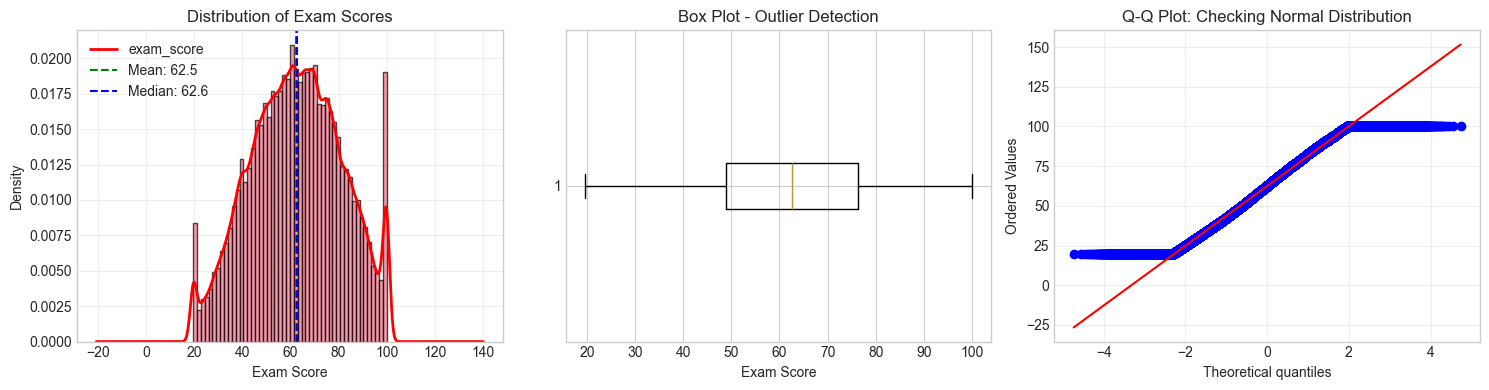


3. OUTLIER DETECTION (IQR Method):
----------------------------------------
Lower bound: 7.5
Upper bound: 117.5
Potential outliers: 0 (0.00%)
No outliers detected using IQR method


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = train.copy()

# Set style for better visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Assuming df is your DataFrame
print("="*60)
print("ANALYZING TARGET VARIABLE: exam_score")
print("="*60)

# Basic statistics
print("\n1. BASIC STATISTICS:")
print("-" * 40)
print(df['exam_score'].describe())

# Distribution metrics
print(f"\n2. DISTRIBUTION METRICS:")
print("-" * 40)
print(f"Skewness: {df['exam_score'].skew():.3f}")
print(f"Kurtosis: {df['exam_score'].kurtosis():.3f}")
print(f"Range: {df['exam_score'].max() - df['exam_score'].min():.1f}")
print(f"IQR (Interquartile Range): {df['exam_score'].quantile(0.75) - df['exam_score'].quantile(0.25):.1f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogram with KDE
axes[0].hist(df['exam_score'], bins=50, edgecolor='black', alpha=0.7, density=True)
df['exam_score'].plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].axvline(df['exam_score'].mean(), color='green', linestyle='--', 
                label=f'Mean: {df["exam_score"].mean():.1f}')
axes[0].axvline(df['exam_score'].median(), color='blue', linestyle='--', 
                label=f'Median: {df["exam_score"].median():.1f}')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Exam Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Box plot
axes[1].boxplot(df['exam_score'], vert=False)
axes[1].set_xlabel('Exam Score')
axes[1].set_title('Box Plot - Outlier Detection')

# 3. Q-Q plot for normality
stats.probplot(df['exam_score'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Checking Normal Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for outliers using IQR method
print(f"\n3. OUTLIER DETECTION (IQR Method):")
print("-" * 40)
Q1 = df['exam_score'].quantile(0.25)
Q3 = df['exam_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['exam_score'] < lower_bound) | (df['exam_score'] > upper_bound)]

print(f"Lower bound: {lower_bound:.1f}")
print(f"Upper bound: {upper_bound:.1f}")
print(f"Potential outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print(f"Outlier score range: {outliers['exam_score'].min():.1f} to {outliers['exam_score'].max():.1f}")
else:
    print("No outliers detected using IQR method")

ANALYZING FEATURE: study_hours

1. BASIC STATISTICS for study_hours:
----------------------------------------
count    630000.000000
mean          4.002337
std           2.359880
min           0.080000
25%           1.970000
50%           4.000000
75%           6.050000
max           7.910000
Name: study_hours, dtype: float64

2. DISTRIBUTION METRICS:
----------------------------------------
Skewness: 0.009
Kurtosis: -1.212
Range: 7.83
IQR: 4.08

3. CORRELATION with exam_score:
----------------------------------------
Pearson correlation: 0.762
Interpretation: Very strong
Direction: Positive


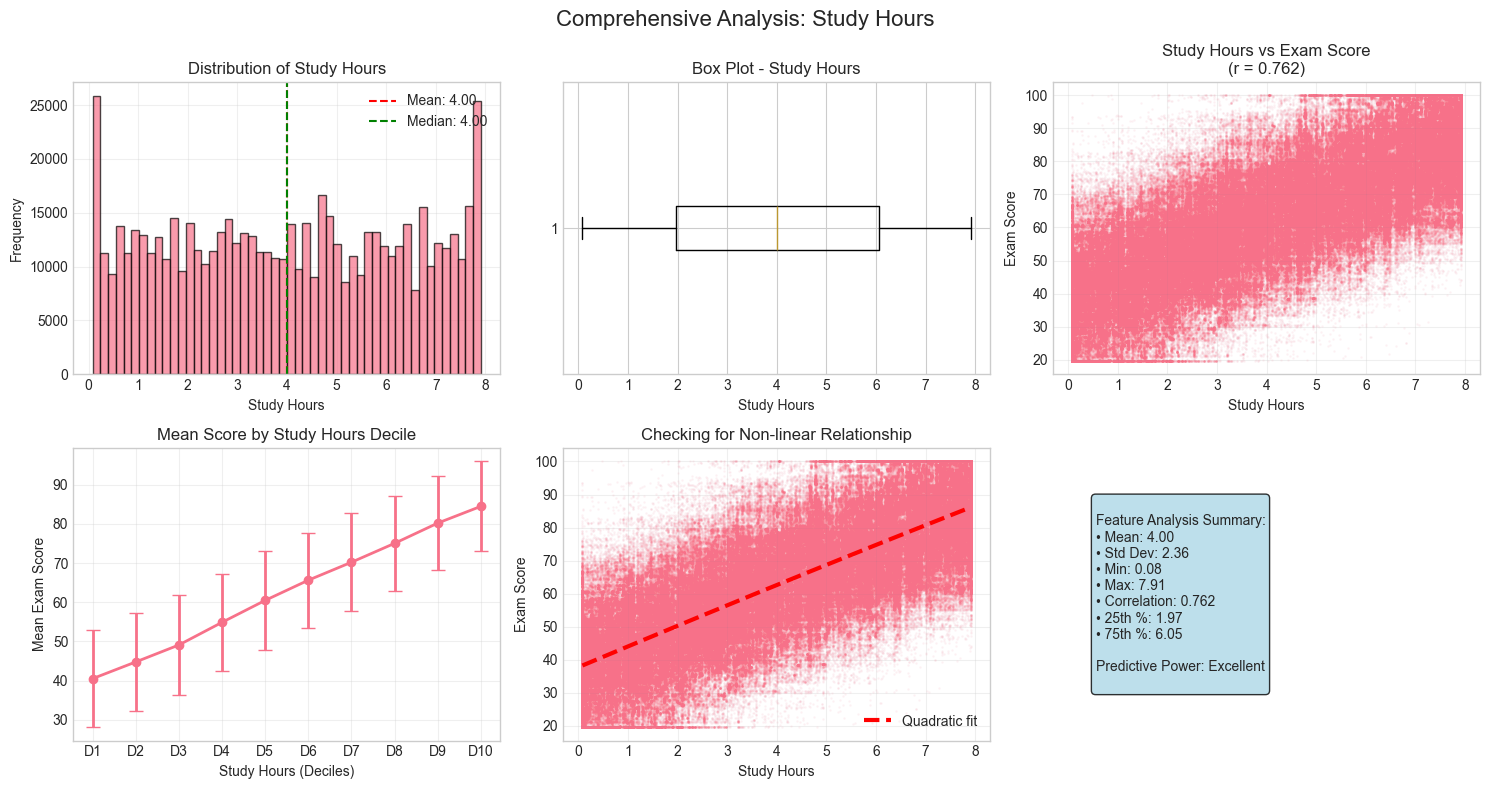


4. OUTLIER ANALYSIS:
----------------------------------------
Lower bound: -4.15
Upper bound: 12.17
Potential outliers: 0 (0.00%)

5. DATA QUALITY CHECK:
----------------------------------------
Missing values: 0
Zero values: 0
Minimum value: 0.08
⚠️  Very low minimum - check if this is realistic


In [11]:
print("="*60)
print("ANALYZING FEATURE: study_hours")
print("="*60)

# Select the feature
feature = 'study_hours'

# 1. Basic Statistics
print(f"\n1. BASIC STATISTICS for {feature}:")
print("-" * 40)
print(df[feature].describe())

# 2. Distribution metrics
print(f"\n2. DISTRIBUTION METRICS:")
print("-" * 40)
print(f"Skewness: {df[feature].skew():.3f}")
print(f"Kurtosis: {df[feature].kurtosis():.3f}")
print(f"Range: {df[feature].max() - df[feature].min():.2f}")
print(f"IQR: {df[feature].quantile(0.75) - df[feature].quantile(0.25):.2f}")

# 3. Correlation with target
correlation = df[feature].corr(df['exam_score'])
print(f"\n3. CORRELATION with exam_score:")
print("-" * 40)
print(f"Pearson correlation: {correlation:.3f}")
print(f"Interpretation: {'Very strong' if abs(correlation) > 0.7 else 'Strong' if abs(correlation) > 0.5 else 'Moderate' if abs(correlation) > 0.3 else 'Weak'}")
print(f"Direction: {'Positive' if correlation > 0 else 'Negative'}")

# 4. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 4a. Distribution histogram
axes[0, 0].hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df[feature].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df[feature].mean():.2f}')
axes[0, 0].axvline(df[feature].median(), color='green', linestyle='--', 
                   label=f'Median: {df[feature].median():.2f}')
axes[0, 0].set_xlabel(feature.replace('_', ' ').title())
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Distribution of {feature.replace("_", " ").title()}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 4b. Box plot for outliers
axes[0, 1].boxplot(df[feature], vert=False)
axes[0, 1].set_xlabel(feature.replace('_', ' ').title())
axes[0, 1].set_title(f'Box Plot - {feature.replace("_", " ").title()}')

# 4c. Scatter plot vs target
axes[0, 2].scatter(df[feature], df['exam_score'], alpha=0.05, s=1)
axes[0, 2].set_xlabel(feature.replace('_', ' ').title())
axes[0, 2].set_ylabel('Exam Score')
axes[0, 2].set_title(f'{feature.replace("_", " ").title()} vs Exam Score\n(r = {correlation:.3f})')
axes[0, 2].grid(True, alpha=0.3)

# 4d. Binned analysis (deciles)
df['temp_binned'] = pd.qcut(df[feature], q=10, duplicates='drop')
binned_stats = df.groupby('temp_binned')['exam_score'].agg(['mean', 'std', 'count'])

axes[1, 0].errorbar(range(len(binned_stats)), binned_stats['mean'], 
                    yerr=binned_stats['std'], fmt='o-', capsize=5, linewidth=2)
axes[1, 0].set_xlabel(f'{feature.replace("_", " ").title()} (Deciles)')
axes[1, 0].set_ylabel('Mean Exam Score')
axes[1, 0].set_title('Mean Score by Study Hours Decile')
axes[1, 0].set_xticks(range(len(binned_stats)))
axes[1, 0].set_xticklabels([f'D{i+1}' for i in range(len(binned_stats))])
axes[1, 0].grid(True, alpha=0.3)

# 4e. Check for non-linearity (polynomial fit)
x = df[feature].values
y = df['exam_score'].values
z = np.polyfit(x, y, 2)  # Quadratic fit
p = np.poly1d(z)

x_sorted = np.sort(x)
axes[1, 1].scatter(df[feature], df['exam_score'], alpha=0.05, s=1)
axes[1, 1].plot(x_sorted, p(x_sorted), "r--", linewidth=3, label='Quadratic fit')
axes[1, 1].set_xlabel(feature.replace('_', ' ').title())
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].set_title('Checking for Non-linear Relationship')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 4f. Statistical summary text
stats_text = f"""
Feature Analysis Summary:
• Mean: {df[feature].mean():.2f}
• Std Dev: {df[feature].std():.2f}
• Min: {df[feature].min():.2f}
• Max: {df[feature].max():.2f}
• Correlation: {correlation:.3f}
• 25th %: {df[feature].quantile(0.25):.2f}
• 75th %: {df[feature].quantile(0.75):.2f}

Predictive Power: {'Excellent' if abs(correlation) > 0.7 else 'Good' if abs(correlation) > 0.5 else 'Moderate'}
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=10, 
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 2].axis('off')

plt.suptitle(f'Comprehensive Analysis: {feature.replace("_", " ").title()}', fontsize=16)
plt.tight_layout()
plt.show()

# Clean up
df.drop('temp_binned', axis=1, inplace=True)

# 5. Outlier detection
print(f"\n4. OUTLIER ANALYSIS:")
print("-" * 40)
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Potential outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print(f"\nOutlier statistics:")
    print(f"  Min outlier value: {outliers[feature].min():.2f}")
    print(f"  Max outlier value: {outliers[feature].max():.2f}")
    print(f"  Their average score: {outliers['exam_score'].mean():.2f}")

# 6. Data quality check
print(f"\n5. DATA QUALITY CHECK:")
print("-" * 40)
print(f"Missing values: {df[feature].isnull().sum()}")
print(f"Zero values: {(df[feature] == 0).sum()}")

# Check minimum value reasonableness
min_value = df[feature].min()
print(f"Minimum value: {min_value:.2f}")
if min_value < 0.5:
    print("⚠️  Very low minimum - check if this is realistic")
elif min_value < 1:
    print("ℹ️  Low minimum - might represent irregular study patterns")
else:
    print("✅ Minimum value seems reasonable")

In [24]:
# Check students with very low study hours
low_study = df[df['study_hours'] < 1]
print(f"Students studying <1 hour: {len(low_study):,}")
print(f"Their average score: {low_study['exam_score'].mean():.2f}")
print(f"Do they have high attendance? {low_study['class_attendance'].mean():.1f}%")

Students studying <1 hour: 81,938
Their average score: 41.43
Do they have high attendance? 70.1%


In [25]:
# Check if 7.91 is a hard cap
at_max = df[df['study_hours'] == df['study_hours'].max()]
print(f"Students at max study hours: {len(at_max):,}")

Students at max study hours: 12,840


ANALYZING FEATURE: class_attendance

1. BASIC STATISTICS for class_attendance:
----------------------------------------
count    630000.000000
mean         71.987261
std          17.430098
min          40.600000
25%          57.000000
50%          72.600000
75%          87.200000
max          99.400000
Name: class_attendance, dtype: float64

2. DISTRIBUTION METRICS:
----------------------------------------
Skewness: -0.096
Kurtosis: -1.189
Range: 58.8%
IQR: 30.2%

3. CORRELATION with exam_score:
----------------------------------------
Pearson correlation: 0.361
Interpretation: Moderate
Direction: Positive

4. CORRELATION with study_hours:
----------------------------------------
Attendance vs Study Hours: 0.088
Multicollinearity check: Low risk


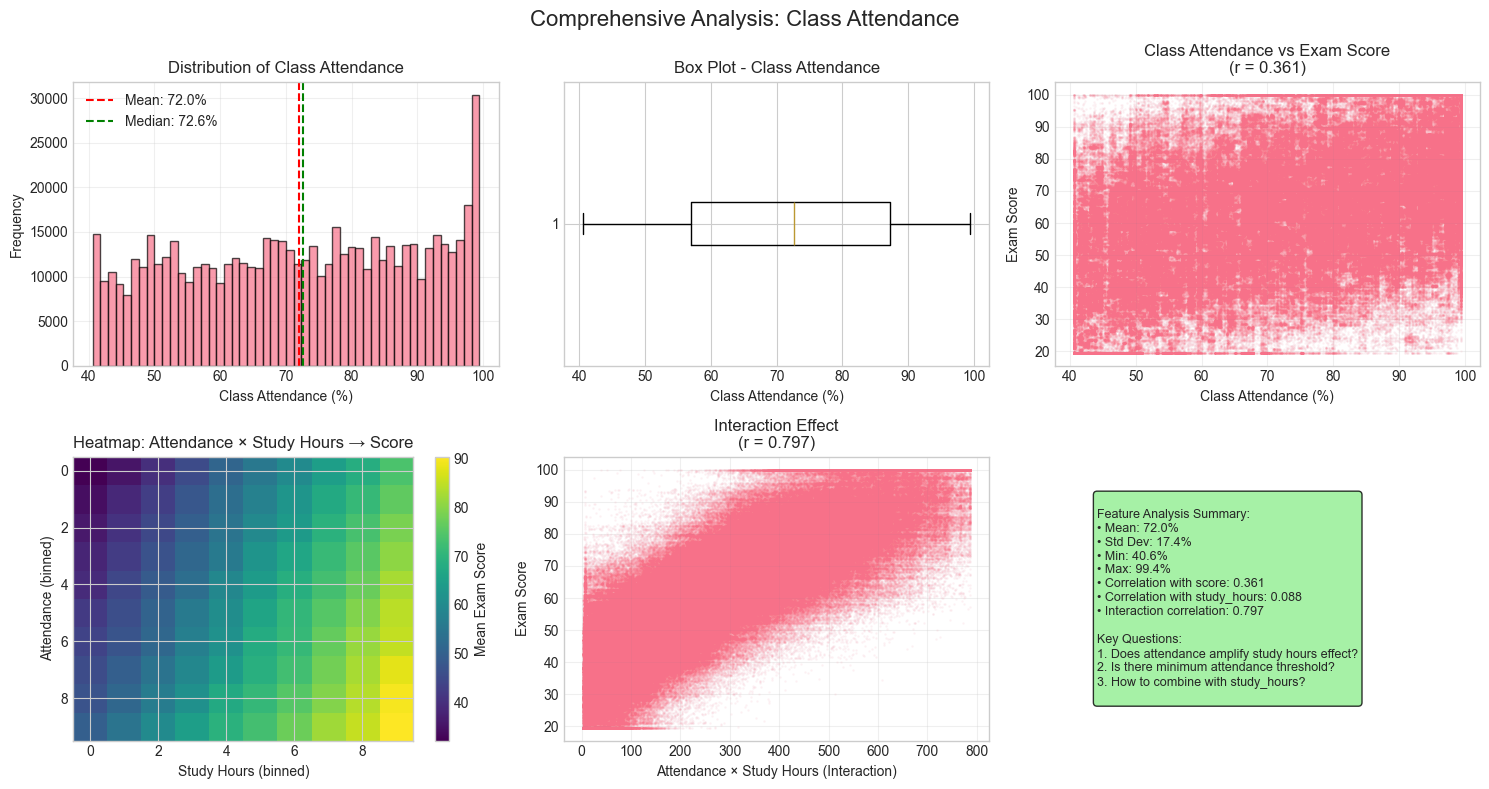


5. ATTENDANCE THRESHOLD ANALYSIS:
----------------------------------------
Attendance 60%+: Score +12.3 points
  (<60%: 53.9, ≥60%: 66.1)
Attendance 70%+: Score +11.6 points
  (<70%: 56.3, ≥70%: 67.8)
Attendance 80%+: Score +11.5 points
  (<80%: 58.2, ≥80%: 69.7)
Attendance 90%+: Score +11.5 points
  (<90%: 60.2, ≥90%: 71.7)


In [26]:
print("="*60)
print("ANALYZING FEATURE: class_attendance")
print("="*60)

feature = 'class_attendance'

# 1. Basic Statistics
print(f"\n1. BASIC STATISTICS for {feature}:")
print("-" * 40)
print(df[feature].describe())

# 2. Distribution metrics
print(f"\n2. DISTRIBUTION METRICS:")
print("-" * 40)
print(f"Skewness: {df[feature].skew():.3f}")
print(f"Kurtosis: {df[feature].kurtosis():.3f}")
print(f"Range: {df[feature].max() - df[feature].min():.1f}%")
print(f"IQR: {df[feature].quantile(0.75) - df[feature].quantile(0.25):.1f}%")

# 3. Correlation with target
correlation = df[feature].corr(df['exam_score'])
print(f"\n3. CORRELATION with exam_score:")
print("-" * 40)
print(f"Pearson correlation: {correlation:.3f}")
print(f"Interpretation: {'Very strong' if abs(correlation) > 0.7 else 'Strong' if abs(correlation) > 0.5 else 'Moderate' if abs(correlation) > 0.3 else 'Weak'}")
print(f"Direction: {'Positive' if correlation > 0 else 'Negative'}")

# 4. Check correlation with study_hours
corr_with_study = df[feature].corr(df['study_hours'])
print(f"\n4. CORRELATION with study_hours:")
print("-" * 40)
print(f"Attendance vs Study Hours: {corr_with_study:.3f}")
print(f"Multicollinearity check: {'Low risk' if abs(corr_with_study) < 0.7 else 'High risk - consider dropping one'}")

# 5. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 5a. Distribution histogram
axes[0, 0].hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df[feature].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df[feature].mean():.1f}%')
axes[0, 0].axvline(df[feature].median(), color='green', linestyle='--', 
                   label=f'Median: {df[feature].median():.1f}%')
axes[0, 0].set_xlabel(f'{feature.replace("_", " ").title()} (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Distribution of {feature.replace("_", " ").title()}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 5b. Box plot
axes[0, 1].boxplot(df[feature], vert=False)
axes[0, 1].set_xlabel(f'{feature.replace("_", " ").title()} (%)')
axes[0, 1].set_title(f'Box Plot - {feature.replace("_", " ").title()}')

# 5c. Scatter plot vs target
axes[0, 2].scatter(df[feature], df['exam_score'], alpha=0.05, s=1)
axes[0, 2].set_xlabel(f'{feature.replace("_", " ").title()} (%)')
axes[0, 2].set_ylabel('Exam Score')
axes[0, 2].set_title(f'{feature.replace("_", " ").title()} vs Exam Score\n(r = {correlation:.3f})')
axes[0, 2].grid(True, alpha=0.3)

# 5d. Combined effect with study_hours (heatmap)
# Create 2D bins
attendance_bins = pd.cut(df[feature], bins=10)
study_bins = pd.cut(df['study_hours'], bins=10)

combined = pd.DataFrame({
    'attendance_bin': attendance_bins,
    'study_bin': study_bins,
    'score': df['exam_score']
})

heatmap_data = combined.groupby(['attendance_bin', 'study_bin'])['score'].mean().unstack()

im = axes[1, 0].imshow(heatmap_data, aspect='auto', cmap='viridis')
axes[1, 0].set_xlabel('Study Hours (binned)')
axes[1, 0].set_ylabel('Attendance (binned)')
axes[1, 0].set_title('Heatmap: Attendance × Study Hours → Score')
plt.colorbar(im, ax=axes[1, 0], label='Mean Exam Score')

# 5e. Check interaction effect
# Calculate interaction term
interaction = df[feature] * df['study_hours']
interaction_corr = interaction.corr(df['exam_score'])

axes[1, 1].scatter(interaction, df['exam_score'], alpha=0.05, s=1)
axes[1, 1].set_xlabel('Attendance × Study Hours (Interaction)')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].set_title(f'Interaction Effect\n(r = {interaction_corr:.3f})')
axes[1, 1].grid(True, alpha=0.3)

# 5f. Statistical summary
stats_text = f"""
Feature Analysis Summary:
• Mean: {df[feature].mean():.1f}%
• Std Dev: {df[feature].std():.1f}%
• Min: {df[feature].min():.1f}%
• Max: {df[feature].max():.1f}%
• Correlation with score: {correlation:.3f}
• Correlation with study_hours: {corr_with_study:.3f}
• Interaction correlation: {interaction_corr:.3f}

Key Questions:
1. Does attendance amplify study hours effect?
2. Is there minimum attendance threshold?
3. How to combine with study_hours?
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=9, 
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1, 2].axis('off')

plt.suptitle(f'Comprehensive Analysis: {feature.replace("_", " ").title()}', fontsize=16)
plt.tight_layout()
plt.show()

# 6. Check for attendance thresholds
print(f"\n5. ATTENDANCE THRESHOLD ANALYSIS:")
print("-" * 40)
thresholds = [60, 70, 80, 90]
for threshold in thresholds:
    below = df[df[feature] < threshold]
    above = df[df[feature] >= threshold]
    diff = above['exam_score'].mean() - below['exam_score'].mean()
    print(f"Attendance {threshold}%+: Score +{diff:.1f} points")
    print(f"  (<{threshold}%: {below['exam_score'].mean():.1f}, ≥{threshold}%: {above['exam_score'].mean():.1f})")

In [27]:
interaction_corr = interaction.corr(df['exam_score'])

In [28]:
interaction_corr

np.float64(0.7967217493720697)

In [29]:
# Calculate interaction term correlation
interaction = df['study_hours'] * df['class_attendance']
interaction_corr = interaction.corr(df['exam_score'])

print(f"\nINTERACTION TERM ANALYSIS:")
print("="*60)
print(f"study_hours × attendance correlation with exam_score: {interaction_corr:.3f}")
print(f"Is this higher than individual correlations?")
print(f"  study_hours alone: {df['study_hours'].corr(df['exam_score']):.3f}")
print(f"  attendance alone: {df['class_attendance'].corr(df['exam_score']):.3f}")
print(f"  interaction term: {interaction_corr:.3f}")

if interaction_corr > 0.762:
    print("\nCONCLUSION: Interaction term is MORE predictive than individual features!")
    print("Should definitely include interaction in model.")
elif interaction_corr > 0.7:
    print("\nCONCLUSION: Interaction is very predictive.")
    print("Consider including interaction in model.")
else:
    print("\nCONCLUSION: Interaction doesn't add much beyond individual features.")
    print("May not need interaction term.")


INTERACTION TERM ANALYSIS:
study_hours × attendance correlation with exam_score: 0.797
Is this higher than individual correlations?
  study_hours alone: 0.762
  attendance alone: 0.361
  interaction term: 0.797

CONCLUSION: Interaction term is MORE predictive than individual features!
Should definitely include interaction in model.


ANALYZING FEATURE: sleep_hours

1. BASIC STATISTICS for sleep_hours:
----------------------------------------
count    630000.000000
mean          7.072758
std           1.744811
min           4.100000
25%           5.600000
50%           7.100000
75%           8.600000
max           9.900000
Name: sleep_hours, dtype: float64

2. DISTRIBUTION METRICS:
----------------------------------------
Skewness: -0.040
Kurtosis: -1.222
Range: 5.8 hours
IQR: 3.0 hours

3. CORRELATION with exam_score:
----------------------------------------
Pearson correlation: 0.167
Interpretation: Weak
Direction: Positive

4. CORRELATIONS with other key features:
----------------------------------------
With study_hours: 0.042
With class_attendance: 0.029

5. OPTIMAL SLEEP RANGE ANALYSIS:
----------------------------------------
4-5 hours: 92,044 students, avg score: 58.2
5-6 hours: 106,649 students, avg score: 59.3
6-7 hours: 99,961 students, avg score: 61.5
7-8 hours: 104,805 students, avg score: 62.7
8-9 hour

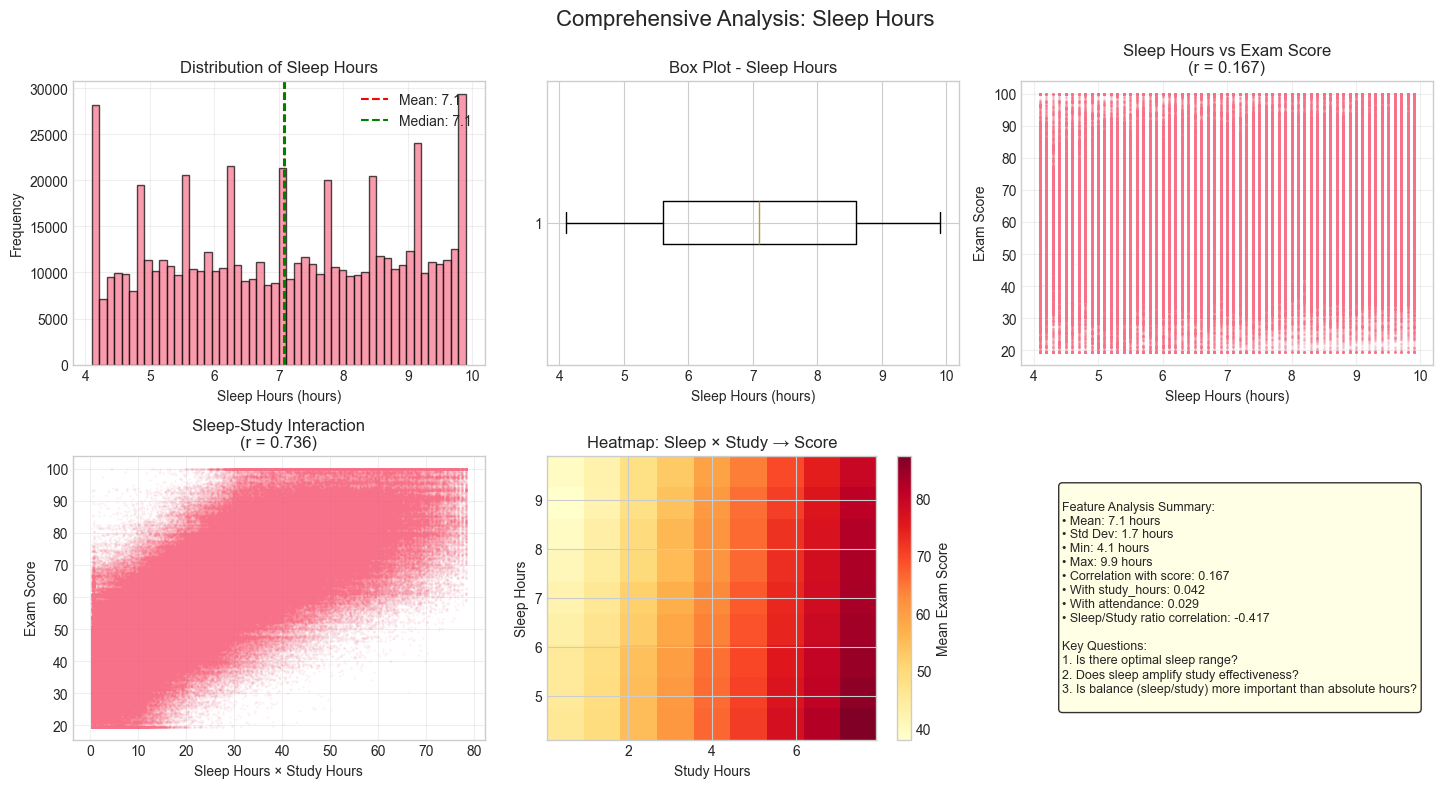


7. OUTLIER ANALYSIS:
----------------------------------------
Lower bound: 1.10 hours
Upper bound: 13.10 hours
Potential outliers: 0 (0.00%)


In [30]:
print("="*60)
print("ANALYZING FEATURE: sleep_hours")
print("="*60)

feature = 'sleep_hours'

# 1. Basic Statistics
print(f"\n1. BASIC STATISTICS for {feature}:")
print("-" * 40)
print(df[feature].describe())

# 2. Distribution metrics
print(f"\n2. DISTRIBUTION METRICS:")
print("-" * 40)
print(f"Skewness: {df[feature].skew():.3f}")
print(f"Kurtosis: {df[feature].kurtosis():.3f}")
print(f"Range: {df[feature].max() - df[feature].min():.1f} hours")
print(f"IQR: {df[feature].quantile(0.75) - df[feature].quantile(0.25):.1f} hours")

# 3. Correlation with target
correlation = df[feature].corr(df['exam_score'])
print(f"\n3. CORRELATION with exam_score:")
print("-" * 40)
print(f"Pearson correlation: {correlation:.3f}")
print(f"Interpretation: {'Very strong' if abs(correlation) > 0.7 else 'Strong' if abs(correlation) > 0.5 else 'Moderate' if abs(correlation) > 0.3 else 'Weak'}")
print(f"Direction: {'Positive' if correlation > 0 else 'Negative'}")

# 4. Check correlation with study_hours and attendance
corr_study = df[feature].corr(df['study_hours'])
corr_attendance = df[feature].corr(df['class_attendance'])
print(f"\n4. CORRELATIONS with other key features:")
print("-" * 40)
print(f"With study_hours: {corr_study:.3f}")
print(f"With class_attendance: {corr_attendance:.3f}")

# 5. Check for U-shaped relationship (optimal sleep range)
print(f"\n5. OPTIMAL SLEEP RANGE ANALYSIS:")
print("-" * 40)
sleep_bins = [4, 5, 6, 7, 8, 9, 10]
for i in range(len(sleep_bins)-1):
    low, high = sleep_bins[i], sleep_bins[i+1]
    subset = df[(df[feature] >= low) & (df[feature] < high)]
    if len(subset) > 0:
        print(f"{low}-{high} hours: {len(subset):,} students, avg score: {subset['exam_score'].mean():.1f}")

# 6. Check sleep-study balance
print(f"\n6. SLEEP-STUDY BALANCE:")
print("-" * 40)
# Create sleep/study ratio
df['sleep_study_ratio'] = df['sleep_hours'] / (df['study_hours'] + 0.1)
balance_corr = df['sleep_study_ratio'].corr(df['exam_score'])
print(f"Sleep/Study ratio correlation with score: {balance_corr:.3f}")

# Check extremes
high_ratio = df[df['sleep_study_ratio'] > 2]  # Sleep much more than study
low_ratio = df[df['sleep_study_ratio'] < 0.5] # Study much more than sleep
print(f"Students sleeping >> studying (ratio > 2): {len(high_ratio):,}, avg score: {high_ratio['exam_score'].mean():.1f}")
print(f"Students studying >> sleeping (ratio < 0.5): {len(low_ratio):,}, avg score: {low_ratio['exam_score'].mean():.1f}")

# 7. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 7a. Distribution histogram
axes[0, 0].hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df[feature].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df[feature].mean():.1f}')
axes[0, 0].axvline(df[feature].median(), color='green', linestyle='--', 
                   label=f'Median: {df[feature].median():.1f}')
axes[0, 0].set_xlabel(f'{feature.replace("_", " ").title()} (hours)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Distribution of {feature.replace("_", " ").title()}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 7b. Box plot
axes[0, 1].boxplot(df[feature], vert=False)
axes[0, 1].set_xlabel(f'{feature.replace("_", " ").title()} (hours)')
axes[0, 1].set_title(f'Box Plot - {feature.replace("_", " ").title()}')

# 7c. Scatter plot vs target
axes[0, 2].scatter(df[feature], df['exam_score'], alpha=0.05, s=1)
axes[0, 2].set_xlabel(f'{feature.replace("_", " ").title()} (hours)')
axes[0, 2].set_ylabel('Exam Score')
axes[0, 2].set_title(f'{feature.replace("_", " ").title()} vs Exam Score\n(r = {correlation:.3f})')
axes[0, 2].grid(True, alpha=0.3)

# 7d. Interaction with study_hours (3D effect)
# Create sleep-study interaction
interaction = df[feature] * df['study_hours']
interaction_corr = interaction.corr(df['exam_score'])

axes[1, 0].scatter(interaction, df['exam_score'], alpha=0.05, s=1)
axes[1, 0].set_xlabel('Sleep Hours × Study Hours')
axes[1, 0].set_ylabel('Exam Score')
axes[1, 0].set_title(f'Sleep-Study Interaction\n(r = {interaction_corr:.3f})')
axes[1, 0].grid(True, alpha=0.3)

# 7e. Combined analysis with study_hours
# Create a 2D histogram/heatmap
sleep_bins = np.linspace(df[feature].min(), df[feature].max(), 10)
study_bins = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 10)

# Group and calculate mean scores
grouped = df.groupby([pd.cut(df[feature], sleep_bins), 
                      pd.cut(df['study_hours'], study_bins)])['exam_score'].mean().unstack()

im = axes[1, 1].imshow(grouped.values, aspect='auto', cmap='YlOrRd', 
                       extent=[study_bins[0], study_bins[-1], sleep_bins[0], sleep_bins[-1]])
axes[1, 1].set_xlabel('Study Hours')
axes[1, 1].set_ylabel('Sleep Hours')
axes[1, 1].set_title('Heatmap: Sleep × Study → Score')
plt.colorbar(im, ax=axes[1, 1], label='Mean Exam Score')
axes[1, 1].set_aspect('auto')

# 7f. Statistical summary
stats_text = f"""
Feature Analysis Summary:
• Mean: {df[feature].mean():.1f} hours
• Std Dev: {df[feature].std():.1f} hours
• Min: {df[feature].min():.1f} hours
• Max: {df[feature].max():.1f} hours
• Correlation with score: {correlation:.3f}
• With study_hours: {corr_study:.3f}
• With attendance: {corr_attendance:.3f}
• Sleep/Study ratio correlation: {balance_corr:.3f}

Key Questions:
1. Is there optimal sleep range?
2. Does sleep amplify study effectiveness?
3. Is balance (sleep/study) more important than absolute hours?
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=9, 
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].axis('off')

plt.suptitle(f'Comprehensive Analysis: {feature.replace("_", " ").title()}', fontsize=16)
plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('sleep_study_ratio', axis=1, inplace=True)

# 8. Check for outliers
print(f"\n7. OUTLIER ANALYSIS:")
print("-" * 40)
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

print(f"Lower bound: {lower_bound:.2f} hours")
print(f"Upper bound: {upper_bound:.2f} hours")
print(f"Potential outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

ANALYZING CATEGORICAL FEATURE: study_method

1. BASIC STATISTICS:
----------------------------------------
Value counts:
  coaching: 131,697 (20.9%)
  self-study: 131,131 (20.8%)
  mixed: 123,086 (19.5%)
  group study: 123,009 (19.5%)
  online videos: 121,077 (19.2%)

2. PERFORMANCE BY STUDY METHOD:
----------------------------------------
                count   mean    std   min    max
study_method                                    
coaching       131697  69.27  18.45  19.6  100.0
group study    123009  60.53  18.22  19.6  100.0
mixed          123086  65.10  18.22  19.6  100.0
online videos  121077  59.73  18.73  19.6  100.0
self-study     131131  57.70  18.56  19.6  100.0

3. STATISTICAL SIGNIFICANCE TEST:
----------------------------------------
ANOVA F-statistic: 8304.29
P-value: 0.0000000000
Interpretation: Extremely significant
Effect size (η²): 0.048
Interpretation: Small effect

4. INTERACTION WITH STUDY HOURS:
----------------------------------------
Correlation (study_hours

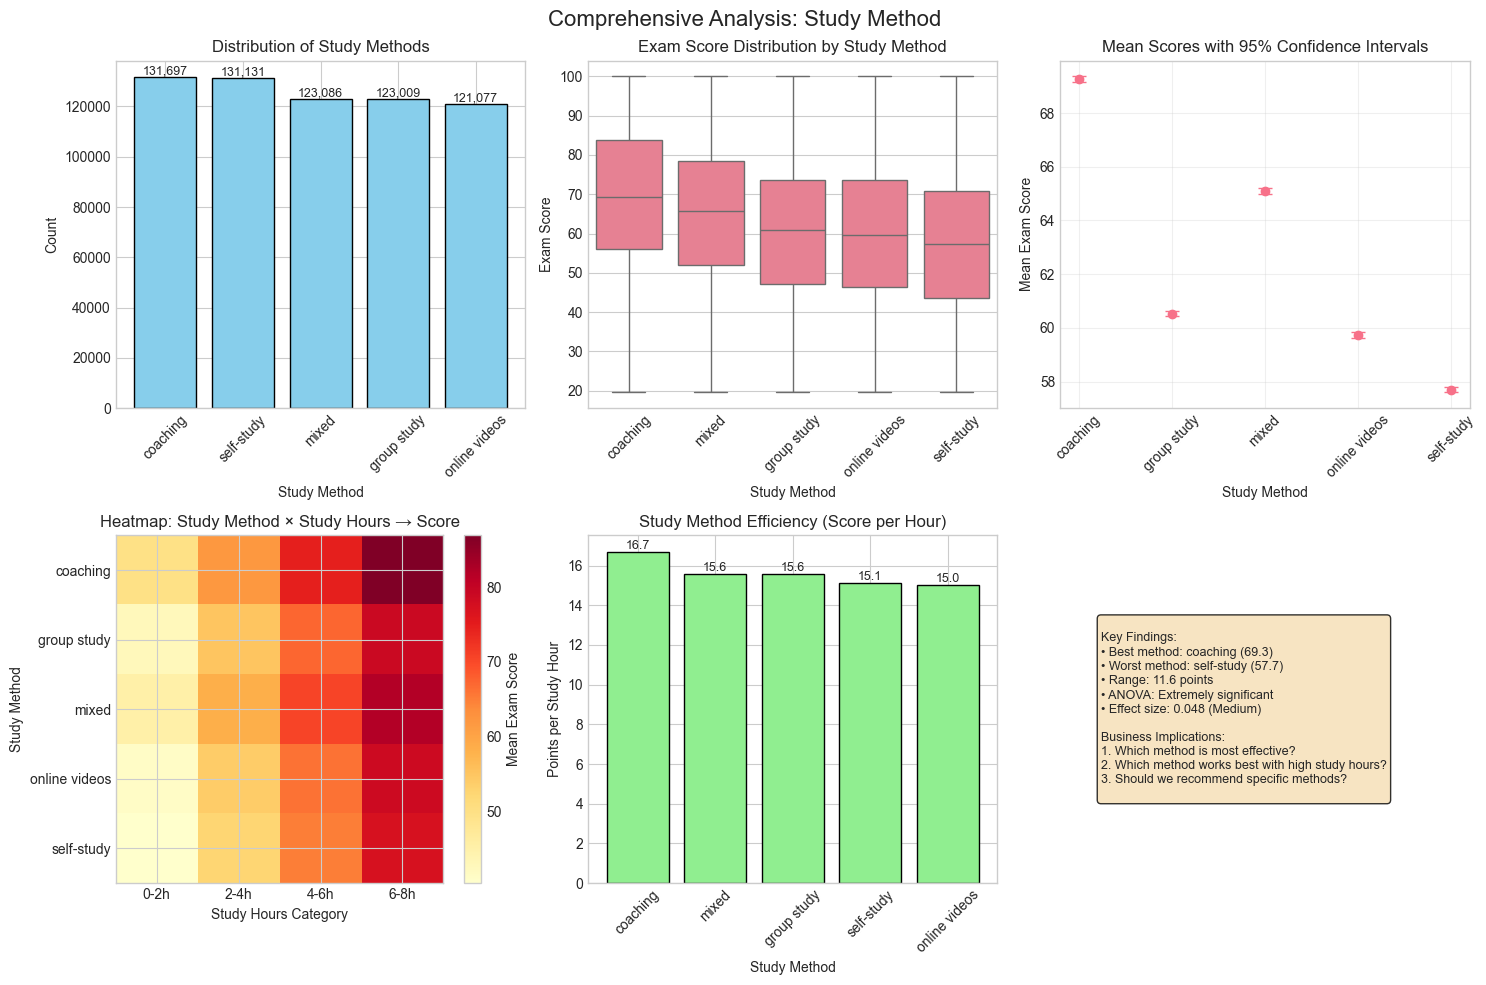


5. POST-HOC ANALYSIS (Pairwise Comparisons):
----------------------------------------
Comparing coaching vs self-study:
  Mean difference: 11.6 points
  T-statistic: 160.22
  P-value: 0.0000000000
  Effect size (Cohen's d): 0.63


In [33]:
print("="*60)
print("ANALYZING CATEGORICAL FEATURE: study_method")
print("="*60)

feature = 'study_method'

# 1. Basic statistics
print(f"\n1. BASIC STATISTICS:")
print("-" * 40)
value_counts = df[feature].value_counts()
print("Value counts:")
for method, count in value_counts.items():
    percentage = count / len(df) * 100
    print(f"  {method}: {count:,} ({percentage:.1f}%)")

# 2. Performance by category
print(f"\n2. PERFORMANCE BY STUDY METHOD:")
print("-" * 40)
method_stats = df.groupby(feature)['exam_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
print(method_stats)

# 3. ANOVA test (are differences significant?)
from scipy import stats
categories = df[feature].unique()
groups = [df[df[feature] == cat]['exam_score'] for cat in categories]
f_stat, p_value = stats.f_oneway(*groups)

print(f"\n3. STATISTICAL SIGNIFICANCE TEST:")
print("-" * 40)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.10f}")
print(f"Interpretation: {'Extremely significant' if p_value < 0.001 else 'Significant' if p_value < 0.05 else 'Not significant'}")

# Calculate effect size (eta squared)
group_means = df.groupby(feature)['exam_score'].mean()
overall_mean = df['exam_score'].mean()
ss_between = sum([len(df[df[feature] == cat]) * (mean - overall_mean)**2 
                  for cat, mean in zip(categories, group_means)])
ss_total = sum((df['exam_score'] - overall_mean)**2)
eta_squared = ss_between / ss_total

print(f"Effect size (η²): {eta_squared:.3f}")
print(f"Interpretation: {'Large effect' if eta_squared > 0.14 else 'Medium effect' if eta_squared > 0.06 else 'Small effect'}")

# 4. Check interaction with study_hours
print(f"\n4. INTERACTION WITH STUDY HOURS:")
print("-" * 40)

# For each study method, calculate correlation between study_hours and exam_score
print("Correlation (study_hours vs exam_score) by study method:")
for method in categories:
    subset = df[df[feature] == method]
    corr = subset['study_hours'].corr(subset['exam_score'])
    avg_study_hours = subset['study_hours'].mean()
    print(f"  {method}: r = {corr:.3f}, avg study hours: {avg_study_hours:.1f}")

# 5. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 5a. Distribution bar chart
axes[0, 0].bar(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Study Method')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Study Methods')
axes[0, 0].set_xticks(range(len(value_counts)))
axes[0, 0].set_xticklabels(value_counts.index, rotation=45)
# Add count labels
for i, v in enumerate(value_counts.values):
    axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 5b. Box plot by study method
order = method_stats.sort_values('mean', ascending=False).index
sns.boxplot(data=df, x=feature, y='exam_score', order=order, ax=axes[0, 1])
axes[0, 1].set_xlabel('Study Method')
axes[0, 1].set_ylabel('Exam Score')
axes[0, 1].set_title('Exam Score Distribution by Study Method')
axes[0, 1].tick_params(axis='x', rotation=45)

# 5c. Mean score with confidence intervals
means = df.groupby(feature)['exam_score'].mean()
stds = df.groupby(feature)['exam_score'].std()
counts = df.groupby(feature)['exam_score'].count()
conf_intervals = 1.96 * stds / np.sqrt(counts)

axes[0, 2].errorbar(range(len(means)), means.values, yerr=conf_intervals.values, 
                   fmt='o', capsize=5, linewidth=2)
axes[0, 2].set_xlabel('Study Method')
axes[0, 2].set_ylabel('Mean Exam Score')
axes[0, 2].set_title('Mean Scores with 95% Confidence Intervals')
axes[0, 2].set_xticks(range(len(means)))
axes[0, 2].set_xticklabels(means.index, rotation=45)
axes[0, 2].grid(True, alpha=0.3)

# 5d. Interaction heatmap: study_method × study_hours
# Create study_hours categories
df['study_hours_cat'] = pd.cut(df['study_hours'], bins=[0, 2, 4, 6, 8], 
                               labels=['0-2h', '2-4h', '4-6h', '6-8h'])

heatmap_data = df.groupby([feature, 'study_hours_cat'])['exam_score'].mean().unstack()

im = axes[1, 0].imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
axes[1, 0].set_xlabel('Study Hours Category')
axes[1, 0].set_ylabel('Study Method')
axes[1, 0].set_title('Heatmap: Study Method × Study Hours → Score')
axes[1, 0].set_xticks(range(len(heatmap_data.columns)))
axes[1, 0].set_xticklabels(heatmap_data.columns)
axes[1, 0].set_yticks(range(len(heatmap_data.index)))
axes[1, 0].set_yticklabels(heatmap_data.index)
plt.colorbar(im, ax=axes[1, 0], label='Mean Exam Score')

# 5e. Efficiency by method (score per study hour)
method_efficiency = {}
for method in categories:
    subset = df[df[feature] == method]
    efficiency = subset['exam_score'].mean() / subset['study_hours'].mean()
    method_efficiency[method] = efficiency

# Sort by efficiency
sorted_methods = sorted(method_efficiency.items(), key=lambda x: x[1], reverse=True)
methods_sorted = [m[0] for m in sorted_methods]
efficiencies_sorted = [m[1] for m in sorted_methods]

axes[1, 1].bar(range(len(sorted_methods)), efficiencies_sorted, color='lightgreen', edgecolor='black')
axes[1, 1].set_xlabel('Study Method')
axes[1, 1].set_ylabel('Points per Study Hour')
axes[1, 1].set_title('Study Method Efficiency (Score per Hour)')
axes[1, 1].set_xticks(range(len(sorted_methods)))
axes[1, 1].set_xticklabels(methods_sorted, rotation=45)
# Add value labels
for i, v in enumerate(efficiencies_sorted):
    axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# 5f. Statistical summary
stats_text = f"""
Key Findings:
• Best method: {method_stats['mean'].idxmax()} ({method_stats['mean'].max():.1f})
• Worst method: {method_stats['mean'].idxmin()} ({method_stats['mean'].min():.1f})
• Range: {method_stats['mean'].max() - method_stats['mean'].min():.1f} points
• ANOVA: {'Extremely significant' if p_value < 0.001 else 'Significant'}
• Effect size: {eta_squared:.3f} ({'Large' if eta_squared > 0.14 else 'Medium'})

Business Implications:
1. Which method is most effective?
2. Which method works best with high study hours?
3. Should we recommend specific methods?
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=9, 
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1, 2].axis('off')

plt.suptitle(f'Comprehensive Analysis: {feature.replace("_", " ").title()}', fontsize=16)
plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('study_hours_cat', axis=1, inplace=True)

# 6. Post-hoc analysis (Tukey HSD if ANOVA significant)
if p_value < 0.05:
    print(f"\n5. POST-HOC ANALYSIS (Pairwise Comparisons):")
    print("-" * 40)
    
    # Since we have many categories, let's just compare best vs worst
    best_method = method_stats['mean'].idxmax()
    worst_method = method_stats['mean'].idxmin()
    
    from scipy.stats import ttest_ind
    best_scores = df[df[feature] == best_method]['exam_score']
    worst_scores = df[df[feature] == worst_method]['exam_score']
    
    t_stat, p_val = ttest_ind(best_scores, worst_scores, equal_var=False)
    
    print(f"Comparing {best_method} vs {worst_method}:")
    print(f"  Mean difference: {method_stats.loc[best_method, 'mean'] - method_stats.loc[worst_method, 'mean']:.1f} points")
    print(f"  T-statistic: {t_stat:.2f}")
    print(f"  P-value: {p_val:.10f}")
    print(f"  Effect size (Cohen's d): {(best_scores.mean() - worst_scores.mean()) / np.sqrt((best_scores.std()**2 + worst_scores.std()**2)/2):.2f}")

ANALYZING CATEGORICAL FEATURE: sleep_quality

1. BASIC STATISTICS:
----------------------------------------
Value counts:
  poor: 213,675 (33.9%)
  good: 213,089 (33.8%)
  average: 203,236 (32.3%)

2. PERFORMANCE BY SLEEP QUALITY:
----------------------------------------
                count   mean    std   min    max
sleep_quality                                   
average        203236  62.66  18.60  19.6  100.0
good           213089  67.88  18.12  19.6  100.0
poor           213675  57.00  18.42  19.6  100.0

3. STATISTICAL SIGNIFICANCE TEST:
----------------------------------------
ANOVA F-statistic: 18739.19
P-value: 0.0000000000
Interpretation: Extremely significant
Effect size (η²): 0.056
Interpretation: Small effect

4. INTERACTION ANALYSIS:
----------------------------------------
Correlation (study_hours vs exam_score) by sleep quality:
  average: r = 0.780, avg study: 4.0h, avg sleep: 7.1h
  poor: r = 0.773, avg study: 3.9h, avg sleep: 7.0h
  good: r = 0.766, avg study: 4.2h

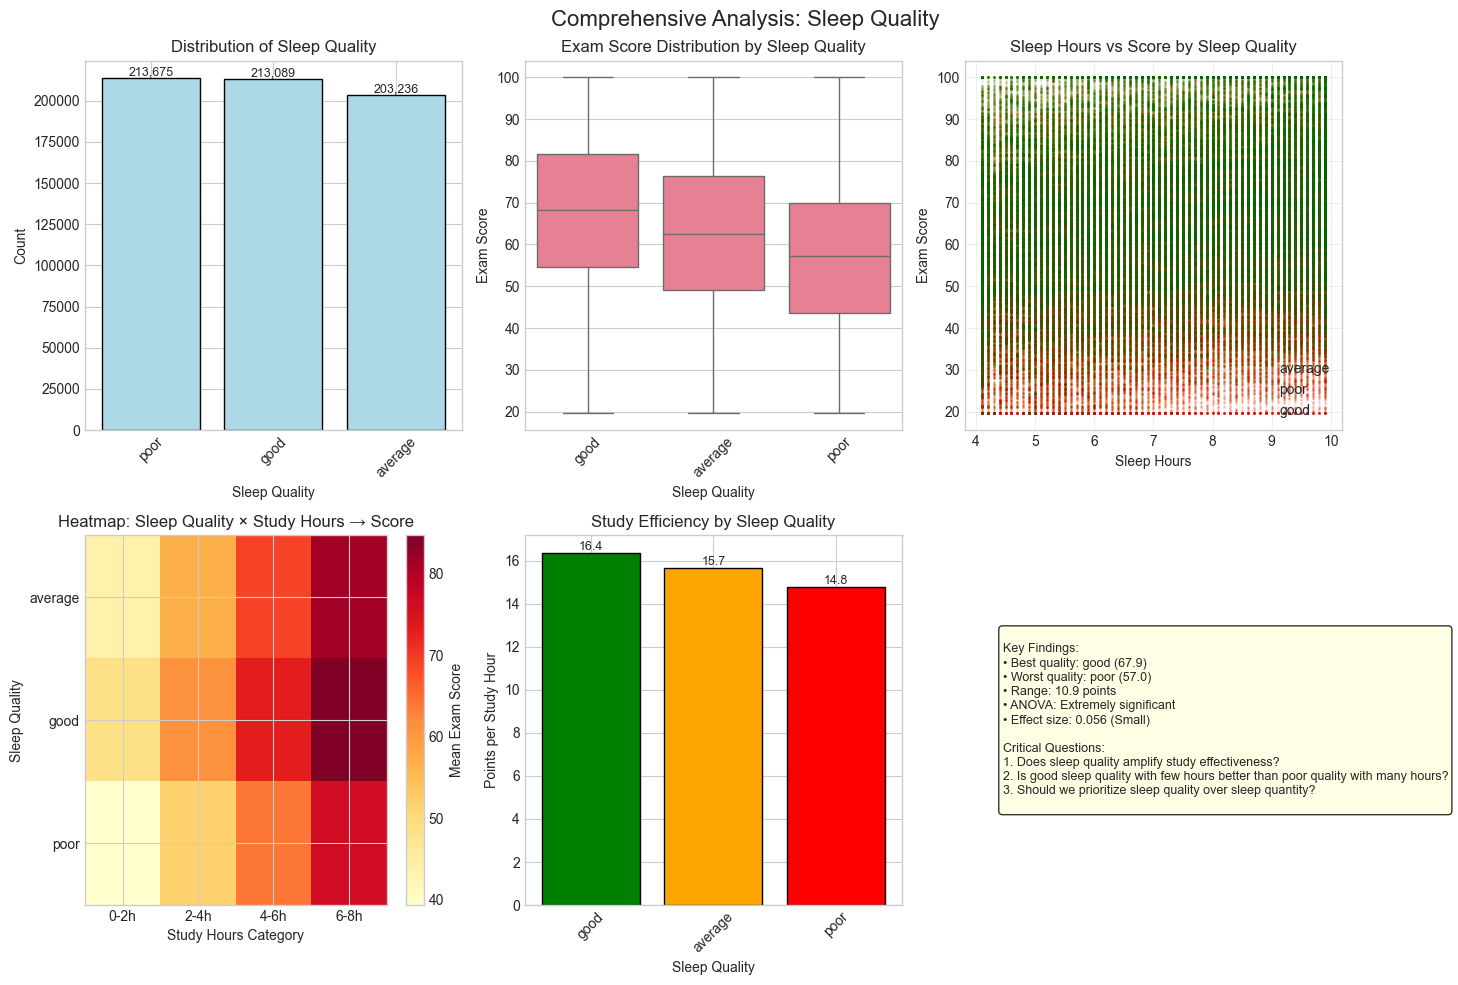


6. POST-HOC ANALYSIS:
----------------------------------------
Comparing good vs poor:
  Mean difference: 10.9 points
  T-statistic: 194.68
  P-value: 0.0000000000
  Effect size (Cohen's d): 0.60


In [34]:
print("="*60)
print("ANALYZING CATEGORICAL FEATURE: sleep_quality")
print("="*60)

feature = 'sleep_quality'

# 1. Basic statistics
print(f"\n1. BASIC STATISTICS:")
print("-" * 40)
value_counts = df[feature].value_counts()
print("Value counts:")
for quality, count in value_counts.items():
    percentage = count / len(df) * 100
    print(f"  {quality}: {count:,} ({percentage:.1f}%)")

# 2. Performance by category
print(f"\n2. PERFORMANCE BY SLEEP QUALITY:")
print("-" * 40)
quality_stats = df.groupby(feature)['exam_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
print(quality_stats)

# 3. ANOVA test
categories = df[feature].unique()
groups = [df[df[feature] == cat]['exam_score'] for cat in categories]
f_stat, p_value = stats.f_oneway(*groups)

print(f"\n3. STATISTICAL SIGNIFICANCE TEST:")
print("-" * 40)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.10f}")
print(f"Interpretation: {'Extremely significant' if p_value < 0.001 else 'Significant' if p_value < 0.05 else 'Not significant'}")

# Effect size
group_means = df.groupby(feature)['exam_score'].mean()
overall_mean = df['exam_score'].mean()
ss_between = sum([len(df[df[feature] == cat]) * (mean - overall_mean)**2 
                  for cat, mean in zip(categories, group_means)])
ss_total = sum((df['exam_score'] - overall_mean)**2)
eta_squared = ss_between / ss_total

print(f"Effect size (η²): {eta_squared:.3f}")
print(f"Interpretation: {'Large effect' if eta_squared > 0.14 else 'Medium effect' if eta_squared > 0.06 else 'Small effect'}")

# 4. Check interaction with study_hours AND sleep_hours
print(f"\n4. INTERACTION ANALYSIS:")
print("-" * 40)

print("Correlation (study_hours vs exam_score) by sleep quality:")
for quality in categories:
    subset = df[df[feature] == quality]
    corr = subset['study_hours'].corr(subset['exam_score'])
    avg_study_hours = subset['study_hours'].mean()
    avg_sleep_hours = subset['sleep_hours'].mean()
    print(f"  {quality}: r = {corr:.3f}, avg study: {avg_study_hours:.1f}h, avg sleep: {avg_sleep_hours:.1f}h")

# 5. Check if sleep quality modifies the sleep_hours effect
print(f"\n5. SLEEP QUALITY × SLEEP HOURS INTERACTION:")
print("-" * 40)
for quality in categories:
    subset = df[df[feature] == quality]
    corr = subset['sleep_hours'].corr(subset['exam_score'])
    print(f"  {quality}: sleep_hours correlation = {corr:.3f}")

# 6. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 6a. Distribution bar chart
axes[0, 0].bar(range(len(value_counts)), value_counts.values, color='lightblue', edgecolor='black')
axes[0, 0].set_xlabel('Sleep Quality')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Sleep Quality')
axes[0, 0].set_xticks(range(len(value_counts)))
axes[0, 0].set_xticklabels(value_counts.index, rotation=45)
for i, v in enumerate(value_counts.values):
    axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 6b. Box plot by sleep quality
order = quality_stats.sort_values('mean', ascending=False).index
sns.boxplot(data=df, x=feature, y='exam_score', order=order, ax=axes[0, 1])
axes[0, 1].set_xlabel('Sleep Quality')
axes[0, 1].set_ylabel('Exam Score')
axes[0, 1].set_title('Exam Score Distribution by Sleep Quality')
axes[0, 1].tick_params(axis='x', rotation=45)

# 6c. Combined effect: sleep quality × sleep hours
# Create interaction scatter
colors = {'poor': 'red', 'average': 'orange', 'good': 'green'}
for quality in categories:
    subset = df[df[feature] == quality]
    axes[0, 2].scatter(subset['sleep_hours'], subset['exam_score'], 
                      alpha=0.05, s=1, color=colors[quality], label=quality)
axes[0, 2].set_xlabel('Sleep Hours')
axes[0, 2].set_ylabel('Exam Score')
axes[0, 2].set_title('Sleep Hours vs Score by Sleep Quality')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 6d. Heatmap: sleep quality × study hours
df['study_hours_cat'] = pd.cut(df['study_hours'], bins=[0, 2, 4, 6, 8], 
                               labels=['0-2h', '2-4h', '4-6h', '6-8h'])
heatmap_data = df.groupby([feature, 'study_hours_cat'])['exam_score'].mean().unstack()

im = axes[1, 0].imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
axes[1, 0].set_xlabel('Study Hours Category')
axes[1, 0].set_ylabel('Sleep Quality')
axes[1, 0].set_title('Heatmap: Sleep Quality × Study Hours → Score')
axes[1, 0].set_xticks(range(len(heatmap_data.columns)))
axes[1, 0].set_xticklabels(heatmap_data.columns)
axes[1, 0].set_yticks(range(len(heatmap_data.index)))
axes[1, 0].set_yticklabels(heatmap_data.index)
plt.colorbar(im, ax=axes[1, 0], label='Mean Exam Score')

# 6e. Triple interaction: sleep quality × sleep hours × study hours
# Calculate efficiency by sleep quality
efficiency_by_quality = {}
for quality in categories:
    subset = df[df[feature] == quality]
    efficiency = subset['exam_score'].mean() / subset['study_hours'].mean()
    efficiency_by_quality[quality] = efficiency

# Sort by efficiency
sorted_qualities = sorted(efficiency_by_quality.items(), key=lambda x: x[1], reverse=True)
qualities_sorted = [q[0] for q in sorted_qualities]
efficiencies_sorted = [q[1] for q in sorted_qualities]

axes[1, 1].bar(range(len(sorted_qualities)), efficiencies_sorted, 
               color=['green', 'orange', 'red'], edgecolor='black')
axes[1, 1].set_xlabel('Sleep Quality')
axes[1, 1].set_ylabel('Points per Study Hour')
axes[1, 1].set_title('Study Efficiency by Sleep Quality')
axes[1, 1].set_xticks(range(len(sorted_qualities)))
axes[1, 1].set_xticklabels(qualities_sorted, rotation=45)
for i, v in enumerate(efficiencies_sorted):
    axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# 6f. Statistical summary
stats_text = f"""
Key Findings:
• Best quality: {quality_stats['mean'].idxmax()} ({quality_stats['mean'].max():.1f})
• Worst quality: {quality_stats['mean'].idxmin()} ({quality_stats['mean'].min():.1f})
• Range: {quality_stats['mean'].max() - quality_stats['mean'].min():.1f} points
• ANOVA: {'Extremely significant' if p_value < 0.001 else 'Significant'}
• Effect size: {eta_squared:.3f} ({'Large' if eta_squared > 0.14 else 'Medium' if eta_squared > 0.06 else 'Small'})

Critical Questions:
1. Does sleep quality amplify study effectiveness?
2. Is good sleep quality with few hours better than poor quality with many hours?
3. Should we prioritize sleep quality over sleep quantity?
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=9, 
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].axis('off')

plt.suptitle(f'Comprehensive Analysis: {feature.replace("_", " ").title()}', fontsize=16)
plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('study_hours_cat', axis=1, inplace=True)

# 7. Post-hoc analysis
if p_value < 0.05:
    print(f"\n6. POST-HOC ANALYSIS:")
    print("-" * 40)
    
    best_quality = quality_stats['mean'].idxmax()
    worst_quality = quality_stats['mean'].idxmin()
    
    best_scores = df[df[feature] == best_quality]['exam_score']
    worst_scores = df[df[feature] == worst_quality]['exam_score']
    
    t_stat, p_val = ttest_ind(best_scores, worst_scores, equal_var=False)
    
    print(f"Comparing {best_quality} vs {worst_quality}:")
    print(f"  Mean difference: {quality_stats.loc[best_quality, 'mean'] - quality_stats.loc[worst_quality, 'mean']:.1f} points")
    print(f"  T-statistic: {t_stat:.2f}")
    print(f"  P-value: {p_val:.10f}")
    print(f"  Effect size (Cohen's d): {(best_scores.mean() - worst_scores.mean()) / np.sqrt((best_scores.std()**2 + worst_scores.std()**2)/2):.2f}")

In [35]:
print("\n" + "="*60)
print("SLEEP QUALITY EFFICIENCY ANALYSIS")
print("="*60)

# Calculate efficiency (points per study hour) by sleep quality
efficiency_data = []
for quality in df['sleep_quality'].unique():
    subset = df[df['sleep_quality'] == quality]
    avg_score = subset['exam_score'].mean()
    avg_hours = subset['study_hours'].mean()
    efficiency = avg_score / avg_hours  # Points per study hour
    
    efficiency_data.append({
        'Sleep Quality': quality,
        'Avg Score': avg_score,
        'Avg Study Hours': avg_hours,
        'Efficiency (points/hour)': efficiency,
        'Students': len(subset)
    })

efficiency_df = pd.DataFrame(efficiency_data).sort_values('Efficiency (points/hour)', ascending=False)

print("\nStudy Efficiency by Sleep Quality (Points per Study Hour):")
print("-" * 60)
for idx, row in efficiency_df.iterrows():
    print(f"{row['Sleep Quality']}:")
    print(f"  Avg Score: {row['Avg Score']:.1f}")
    print(f"  Avg Study Hours: {row['Avg Study Hours']:.1f}")
    print(f"  Efficiency: {row['Efficiency (points/hour)']:.1f} points/hour")
    print(f"  Students: {row['Students']:,}")

# Compare to sleep hours efficiency
print("\n" + "="*60)
print("SLEEP QUALITY VS SLEEP HOURS IMPACT")
print("="*60)

# Create sleep hours categories
df['sleep_hours_cat'] = pd.cut(df['sleep_hours'], bins=[4, 6, 8, 10], labels=['Low (4-6h)', 'Medium (6-8h)', 'High (8-10h)'])

print("\nImpact of Sleep Hours (ignoring quality):")
hours_impact = df.groupby('sleep_hours_cat')['exam_score'].mean()
for cat, score in hours_impact.items():
    count = df[df['sleep_hours_cat'] == cat].shape[0]
    print(f"  {cat}: {score:.1f} average score ({count:,} students)")

print("\nImpact of Sleep Quality (ignoring hours):")
quality_impact = df.groupby('sleep_quality')['exam_score'].mean()
for cat, score in quality_impact.items():
    count = df[df['sleep_quality'] == cat].shape[0]
    print(f"  {cat}: {score:.1f} average score ({count:,} students)")

# Clean up
df.drop('sleep_hours_cat', axis=1, inplace=True)


SLEEP QUALITY EFFICIENCY ANALYSIS

Study Efficiency by Sleep Quality (Points per Study Hour):
------------------------------------------------------------
good:
  Avg Score: 67.9
  Avg Study Hours: 4.2
  Efficiency: 16.4 points/hour
  Students: 213,089
average:
  Avg Score: 62.7
  Avg Study Hours: 4.0
  Efficiency: 15.7 points/hour
  Students: 203,236
poor:
  Avg Score: 57.0
  Avg Study Hours: 3.9
  Efficiency: 14.8 points/hour
  Students: 213,675

SLEEP QUALITY VS SLEEP HOURS IMPACT

Impact of Sleep Hours (ignoring quality):
  Low (4-6h): 58.8 average score (208,823 students)
  Medium (6-8h): 62.5 average score (204,897 students)
  High (8-10h): 66.1 average score (216,280 students)

Impact of Sleep Quality (ignoring hours):
  average: 62.7 average score (203,236 students)
  good: 67.9 average score (213,089 students)
  poor: 57.0 average score (213,675 students)


In [36]:
print("="*60)
print("QUICK CHECK: facility_rating")
print("="*60)

feature = 'facility_rating'

# Basic stats
print("\n1. PERFORMANCE BY FACILITY RATING:")
print("-" * 40)
rating_stats = df.groupby(feature)['exam_score'].agg(['count', 'mean', 'std']).round(2)
print(rating_stats)

# Check if ordinal (low < medium < high)
print(f"\n2. ORDINAL CHECK:")
print("-" * 40)
means = rating_stats['mean']
print(f"Mean scores: {means.to_dict()}")
if means['low'] < means['medium'] < means['high']:
    print("✓ Clear ordinal pattern: low < medium < high")
else:
    print("✗ Not perfectly ordinal")

# Effect size
print(f"\n3. EFFECT SIZE:")
print("-" * 40)
range_effect = means.max() - means.min()
print(f"Score range: {range_effect:.1f} points")
print(f"Relative to overall std (18.9): {range_effect/18.9:.3f}")

# Quick ANOVA
categories = df[feature].unique()
groups = [df[df[feature] == cat]['exam_score'] for cat in categories]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\n4. STATISTICAL SIGNIFICANCE:")
print("-" * 40)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.10f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

QUICK CHECK: facility_rating

1. PERFORMANCE BY FACILITY RATING:
----------------------------------------
                  count   mean    std
facility_rating                      
high             203540  66.71  18.53
low              212378  57.95  18.56
medium           214082  63.03  18.64

2. ORDINAL CHECK:
----------------------------------------
Mean scores: {'high': 66.71, 'low': 57.95, 'medium': 63.03}
✓ Clear ordinal pattern: low < medium < high

3. EFFECT SIZE:
----------------------------------------
Score range: 8.8 points
Relative to overall std (18.9): 0.463

4. STATISTICAL SIGNIFICANCE:
----------------------------------------
ANOVA F-statistic: 11664.97
P-value: 0.0000000000
Significant: YES


In [37]:
print("\n" + "="*60)
print("QUICK CHECK: age")
print("="*60)

feature = 'age'

print(f"\n1. BASIC STATS:")
print("-" * 40)
print(df[feature].describe())

print(f"\n2. CORRELATION WITH EXAM_SCORE:")
print("-" * 40)
corr = df[feature].corr(df['exam_score'])
print(f"Pearson r: {corr:.3f}")
print(f"Interpretation: {'Drop from model' if abs(corr) < 0.1 else 'Consider keeping'}")

# Check if there's any non-linear pattern
print(f"\n3. CHECK FOR NON-LINEAR PATTERN:")
print("-" * 40)
age_groups = df.groupby(feature)['exam_score'].mean()
print("Average score by age:")
for age, score in age_groups.items():
    print(f"  Age {age}: {score:.1f}")


QUICK CHECK: age

1. BASIC STATS:
----------------------------------------
count    630000.000000
mean         20.545821
std           2.260238
min          17.000000
25%          19.000000
50%          21.000000
75%          23.000000
max          24.000000
Name: age, dtype: float64

2. CORRELATION WITH EXAM_SCORE:
----------------------------------------
Pearson r: 0.010
Interpretation: Drop from model

3. CHECK FOR NON-LINEAR PATTERN:
----------------------------------------
Average score by age:
  Age 17: 62.5
  Age 18: 62.1
  Age 19: 61.7
  Age 20: 62.5
  Age 21: 62.8
  Age 22: 63.1
  Age 23: 62.9
  Age 24: 62.3


In [38]:
print("="*80)
print("FEATURE ENGINEERING - CREATING NEW FEATURES")
print("="*80)

# Make a copy for experimentation
df_features = df.copy()

print("Creating new features based on domain knowledge...")

# 1. AWAKE TIME FEATURES
print("\n1. AWAKE TIME FEATURES:")
print("-" * 40)

# Assuming 24 hours in a day
df_features['awake_hours'] = 24 - df_features['sleep_hours']
print(f"  Created: awake_hours = 24 - sleep_hours")

# Study percentage of awake time
df_features['study_awake_ratio'] = df_features['study_hours'] / df_features['awake_hours']
print(f"  Created: study_awake_ratio = study_hours / awake_hours")

# Productive awake time (study + class time)
# We need to estimate class hours. Let's assume 6 hours of classes per day
# and attendance percentage applies to that
class_hours_per_day = 6
df_features['estimated_class_hours'] = class_hours_per_day * (df_features['class_attendance'] / 100)
df_features['total_productive_hours'] = df_features['study_hours'] + df_features['estimated_class_hours']
df_features['productive_awake_ratio'] = df_features['total_productive_hours'] / df_features['awake_hours']
print(f"  Created: estimated_class_hours = 6 * (attendance/100)")
print(f"  Created: total_productive_hours = study_hours + estimated_class_hours")
print(f"  Created: productive_awake_ratio = total_productive_hours / awake_hours")

# 2. SLEEP QUALITY WEIGHTED FEATURES
print("\n2. SLEEP QUALITY WEIGHTED FEATURES:")
print("-" * 40)

# Map sleep_quality to numeric scores (from our analysis: poor=0, average=1, good=2)
sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
df_features['sleep_quality_score'] = df_features['sleep_quality'].map(sleep_quality_map)

# Weighted sleep features
df_features['sleep_quality_weighted_hours'] = df_features['sleep_quality_score'] * df_features['sleep_hours']
df_features['sleep_efficiency_score'] = df_features['sleep_quality_score'] * df_features['sleep_hours'] / 8  # normalized to 8h ideal
print(f"  Created: sleep_quality_score (poor=0, average=1, good=2)")
print(f"  Created: sleep_quality_weighted_hours = sleep_quality_score × sleep_hours")
print(f"  Created: sleep_efficiency_score = sleep_quality_score × sleep_hours / 8")

# 3. STUDY EFFICIENCY METRICS
print("\n3. STUDY EFFICIENCY METRICS:")
print("-" * 40)

# Study consistency (combining hours and attendance)
df_features['study_consistency'] = df_features['study_hours'] * (df_features['class_attendance'] / 100)

# Study method efficiency (different methods might have different base efficiencies)
study_method_efficiency = {
    'coaching': 1.2,      # 20% more efficient
    'mixed': 1.1,         # 10% more efficient
    'group study': 1.0,   # baseline
    'online videos': 0.9, # 10% less efficient
    'self-study': 0.8     # 20% less efficient
}
df_features['study_method_efficiency_factor'] = df_features['study_method'].map(study_method_efficiency)
df_features['effective_study_hours'] = df_features['study_hours'] * df_features['study_method_efficiency_factor']
print(f"  Created: study_consistency = study_hours × (attendance/100)")
print(f"  Created: study_method_efficiency_factor (based on analysis)")
print(f"  Created: effective_study_hours = study_hours × efficiency_factor")

# 4. BALANCE METRICS
print("\n4. BALANCE METRICS:")
print("-" * 40)

# Sleep-study balance (from earlier insight)
df_features['sleep_study_balance'] = df_features['sleep_hours'] / (df_features['study_hours'] + 0.1)
df_features['study_sleep_imbalance'] = abs(df_features['study_hours'] - df_features['sleep_hours'])

# Productive-rest balance
df_features['productive_rest_ratio'] = df_features['total_productive_hours'] / (df_features['sleep_hours'] + 0.1)
print(f"  Created: sleep_study_balance = sleep_hours / (study_hours + 0.1)")
print(f"  Created: study_sleep_imbalance = |study_hours - sleep_hours|")
print(f"  Created: productive_rest_ratio = total_productive_hours / (sleep_hours + 0.1)")

# 5. TIME MANAGEMENT METRICS
print("\n5. TIME MANAGEMENT METRICS:")
print("-" * 40)

# Time utilization
df_features['time_utilization'] = (df_features['study_hours'] + df_features['estimated_class_hours']) / 24
df_features['free_time'] = 24 - df_features['total_productive_hours'] - df_features['sleep_hours']

# Peak study hours (assuming 4-6 hours is optimal)
df_features['optimal_study_range'] = ((df_features['study_hours'] >= 4) & (df_features['study_hours'] <= 6)).astype(int)
df_features['over_study'] = (df_features['study_hours'] > 6).astype(int)
df_features['under_study'] = (df_features['study_hours'] < 4).astype(int)
print(f"  Created: time_utilization = (study + class) / 24")
print(f"  Created: free_time = 24 - total_productive_hours - sleep_hours")
print(f"  Created: optimal_study_range (1 if 4-6 hours, 0 otherwise)")
print(f"  Created: over_study (1 if >6 hours, 0 otherwise)")
print(f"  Created: under_study (1 if <4 hours, 0 otherwise)")

# 6. COMPOSITE SCORES
print("\n6. COMPOSITE SCORES:")
print("-" * 40)

# Overall wellness score
df_features['wellness_score'] = (
    df_features['sleep_quality_score'] * 0.4 + 
    (df_features['sleep_hours'] / 8) * 0.3 +
    (df_features['study_hours'] / 6) * 0.3  # normalized to 6h ideal
)

# Study effectiveness score
df_features['study_effectiveness_score'] = (
    df_features['effective_study_hours'] * 0.4 +
    df_features['study_consistency'] * 0.3 +
    df_features['study_method_efficiency_factor'] * 0.3
)

print(f"  Created: wellness_score (composite of sleep quality, hours, and study)")
print(f"  Created: study_effectiveness_score (composite of effective hours, consistency, method)")

print(f"\n✅ Created {len(df_features.columns) - len(df.columns)} new features!")
print(f"Total features now: {len(df_features.columns)}")

FEATURE ENGINEERING - CREATING NEW FEATURES
Creating new features based on domain knowledge...

1. AWAKE TIME FEATURES:
----------------------------------------
  Created: awake_hours = 24 - sleep_hours
  Created: study_awake_ratio = study_hours / awake_hours
  Created: estimated_class_hours = 6 * (attendance/100)
  Created: total_productive_hours = study_hours + estimated_class_hours
  Created: productive_awake_ratio = total_productive_hours / awake_hours

2. SLEEP QUALITY WEIGHTED FEATURES:
----------------------------------------
  Created: sleep_quality_score (poor=0, average=1, good=2)
  Created: sleep_quality_weighted_hours = sleep_quality_score × sleep_hours
  Created: sleep_efficiency_score = sleep_quality_score × sleep_hours / 8

3. STUDY EFFICIENCY METRICS:
----------------------------------------
  Created: study_consistency = study_hours × (attendance/100)
  Created: study_method_efficiency_factor (based on analysis)
  Created: effective_study_hours = study_hours × efficien


ANALYZING NEW FEATURES
Correlation of new features with exam_score:
--------------------------------------------------------------------------------

Top 10 most correlated new features:
total_productive_hours              | r =  0.817 | Very strong  | Positive
time_utilization                    | r =  0.817 | Very strong  | Positive
productive_awake_ratio              | r =  0.812 | Very strong  | Positive
study_effectiveness_score           | r =  0.807 | Very strong  | Positive
study_consistency                   | r =  0.797 | Very strong  | Positive
effective_study_hours               | r =  0.775 | Very strong  | Positive
study_awake_ratio                   | r =  0.769 | Very strong  | Positive
free_time                           | r = -0.758 | Very strong  | Negative
under_study                         | r = -0.666 | Strong       | Negative
over_study                          | r =  0.574 | Strong       | Positive


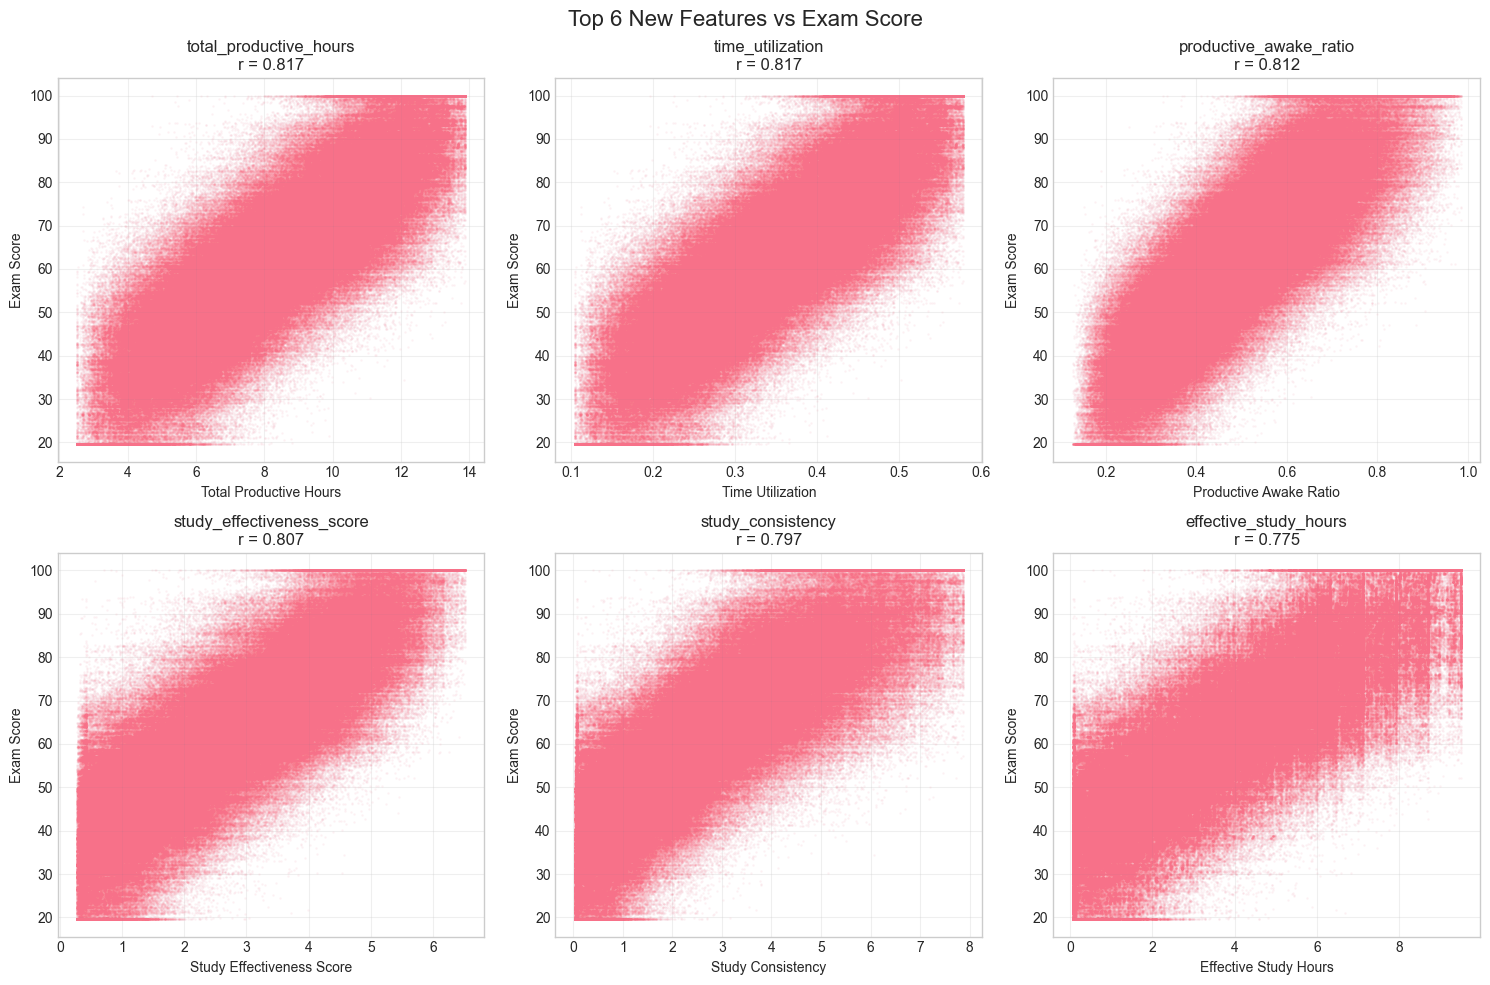

In [39]:
print("\n" + "="*80)
print("ANALYZING NEW FEATURES")
print("="*80)

# List of new engineered features
new_features = [
    'awake_hours', 'study_awake_ratio', 'estimated_class_hours',
    'total_productive_hours', 'productive_awake_ratio',
    'sleep_quality_score', 'sleep_quality_weighted_hours', 'sleep_efficiency_score',
    'study_consistency', 'study_method_efficiency_factor', 'effective_study_hours',
    'sleep_study_balance', 'study_sleep_imbalance', 'productive_rest_ratio',
    'time_utilization', 'free_time', 'optimal_study_range', 'over_study', 'under_study',
    'wellness_score', 'study_effectiveness_score'
]

# Check correlations with target
print("Correlation of new features with exam_score:")
print("-" * 80)

correlations = {}
for feature in new_features:
    corr = df_features[feature].corr(df_features['exam_score'])
    correlations[feature] = corr
    
# Sort by absolute correlation
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nTop 10 most correlated new features:")
print("=" * 80)
for feature, corr in sorted_correlations[:10]:
    strength = "Very strong" if abs(corr) > 0.7 else "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    direction = "Positive" if corr > 0 else "Negative"
    print(f"{feature:35s} | r = {corr:6.3f} | {strength:12s} | {direction}")

# Visualize top correlations
top_features = [feat for feat, _ in sorted_correlations[:6]]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    if idx < len(axes):
        axes[idx].scatter(df_features[feature], df_features['exam_score'], alpha=0.05, s=1)
        corr = correlations[feature]
        axes[idx].set_xlabel(feature.replace('_', ' ').title())
        axes[idx].set_ylabel('Exam Score')
        axes[idx].set_title(f'{feature}\nr = {corr:.3f}')
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Top 6 New Features vs Exam Score', fontsize=16)
plt.tight_layout()
plt.show()

In [40]:
print("\n" + "="*80)
print("SPECIAL PATTERN ANALYSIS")
print("="*80)

# 1. Check optimal study_awake_ratio
print("\n1. OPTIMAL STUDY/AWAKE RATIO:")
print("-" * 80)

# Bin by study_awake_ratio
df_features['study_awake_bin'] = pd.cut(df_features['study_awake_ratio'], bins=10)
ratio_stats = df_features.groupby('study_awake_bin')['exam_score'].agg(['mean', 'std', 'count'])

print("\nAverage Score by Study/Awake Ratio:")
for idx, row in ratio_stats.iterrows():
    print(f"  {idx}: {row['mean']:.1f} (n={row['count']:,})")

# Find optimal range
optimal_bin = ratio_stats['mean'].idxmax()
print(f"\nOptimal range: {optimal_bin}")
print(f"Optimal ratio gives: {ratio_stats.loc[optimal_bin, 'mean']:.1f} average score")

# 2. Check sleep quality weighted hours
print("\n\n2. SLEEP QUALITY WEIGHTED HOURS ANALYSIS:")
print("-" * 80)

# Compare regular sleep hours vs weighted
print("Comparison of sleep metrics:")
print(f"  sleep_hours correlation: {df_features['sleep_hours'].corr(df_features['exam_score']):.3f}")
print(f"  sleep_quality_weighted_hours correlation: {df_features['sleep_quality_weighted_hours'].corr(df_features['exam_score']):.3f}")
print(f"  Improvement: {abs(df_features['sleep_quality_weighted_hours'].corr(df_features['exam_score']) - df_features['sleep_hours'].corr(df_features['exam_score'])):.3f}")

# 3. Check time utilization patterns
print("\n\n3. TIME UTILIZATION ANALYSIS:")
print("-" * 80)

# Create utilization categories
df_features['utilization_cat'] = pd.cut(df_features['time_utilization'], 
                                        bins=[0, 0.3, 0.5, 0.7, 1.0],
                                        labels=['Low', 'Medium', 'High', 'Very High'])

util_stats = df_features.groupby('utilization_cat')['exam_score'].agg(['mean', 'std', 'count'])
print("\nPerformance by Time Utilization:")
print(util_stats)

# 4. Check wellness score effectiveness
print("\n\n4. WELLNESS SCORE ANALYSIS:")
print("-" * 80)

wellness_corr = df_features['wellness_score'].corr(df_features['exam_score'])
print(f"Wellness Score correlation: {wellness_corr:.3f}")

# Compare with individual components
print("\nComparison with individual components:")
print(f"  sleep_quality_score: {df_features['sleep_quality_score'].corr(df_features['exam_score']):.3f}")
print(f"  sleep_hours: {df_features['sleep_hours'].corr(df_features['exam_score']):.3f}")
print(f"  study_hours: {df_features['study_hours'].corr(df_features['exam_score']):.3f}")
print(f"  wellness_score (composite): {wellness_corr:.3f}")

# 5. Check study effectiveness score
print("\n\n5. STUDY EFFECTIVENESS SCORE ANALYSIS:")
print("-" * 80)

effectiveness_corr = df_features['study_effectiveness_score'].corr(df_features['exam_score'])
print(f"Study Effectiveness Score correlation: {effectiveness_corr:.3f}")

# Compare with individual study metrics
print("\nComparison with individual study metrics:")
print(f"  study_hours: {df_features['study_hours'].corr(df_features['exam_score']):.3f}")
print(f"  effective_study_hours: {df_features['effective_study_hours'].corr(df_features['exam_score']):.3f}")
print(f"  study_consistency: {df_features['study_consistency'].corr(df_features['exam_score']):.3f}")
print(f"  study_effectiveness_score (composite): {effectiveness_corr:.3f}")

# Clean up temporary columns
df_features.drop(['study_awake_bin', 'utilization_cat'], axis=1, inplace=True)


SPECIAL PATTERN ANALYSIS

1. OPTIMAL STUDY/AWAKE RATIO:
--------------------------------------------------------------------------------

Average Score by Study/Awake Ratio:
  (0.00346, 0.0597]: 41.2 (n=84,236.0)
  (0.0597, 0.115]: 46.0 (n=73,870.0)
  (0.115, 0.171]: 52.5 (n=72,708.0)
  (0.171, 0.227]: 58.9 (n=72,994.0)
  (0.227, 0.283]: 64.9 (n=72,761.0)
  (0.283, 0.338]: 70.4 (n=70,091.0)
  (0.338, 0.394]: 76.2 (n=69,857.0)
  (0.394, 0.45]: 80.8 (n=61,855.0)
  (0.45, 0.505]: 84.2 (n=35,032.0)
  (0.505, 0.561]: 87.8 (n=16,596.0)

Optimal range: (0.505, 0.561]
Optimal ratio gives: 87.8 average score


2. SLEEP QUALITY WEIGHTED HOURS ANALYSIS:
--------------------------------------------------------------------------------
Comparison of sleep metrics:
  sleep_hours correlation: 0.167
  sleep_quality_weighted_hours correlation: 0.265
  Improvement: 0.097


3. TIME UTILIZATION ANALYSIS:
--------------------------------------------------------------------------------

Performance by Time 

In [41]:
print("\n" + "="*80)
print("FEATURE SELECTION RECOMMENDATIONS")
print("="*80)

# Define selection criteria
selected_new_features = []
reasons = []

# Criteria 1: High correlation (> 0.3)
high_corr_features = [feat for feat, corr in sorted_correlations if abs(corr) > 0.3]
if high_corr_features:
    selected_new_features.extend(high_corr_features[:5])  # Top 5 high correlation
    reasons.append("High correlation with target")

# Criteria 2: Domain sense - important engineered features
domain_features = [
    'sleep_quality_weighted_hours',  # Combines quality and quantity
    'effective_study_hours',         # Accounts for method efficiency
    'study_consistency',             # Combines study and attendance
    'productive_awake_ratio',        # Good time management metric
    'wellness_score',                # Composite wellness indicator
]

for feat in domain_features:
    if feat not in selected_new_features:
        selected_new_features.append(feat)
        reasons.append("Domain importance")

# Criteria 3: Novel information (low correlation with existing features)
existing_features = ['study_hours', 'class_attendance', 'sleep_hours', 
                     'sleep_quality', 'study_method', 'facility_rating']

print("Selected new features for modeling:")
print("-" * 80)
for i, feat in enumerate(selected_new_features, 1):
    corr = correlations[feat]
    print(f"{i:2d}. {feat:35s} | r = {corr:.3f}")

# Check multicollinearity
print("\n" + "="*80)
print("MULTICOLLINEARITY CHECK")
print("="*80)

# Check correlations among selected new features and existing key features
check_features = selected_new_features + ['study_hours', 'class_attendance', 'sleep_hours']
corr_matrix = df_features[check_features].corr()

# Find high correlations (> 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("High correlation pairs (potential multicollinearity):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1} - {feat2}: {corr:.3f}")
else:
    print("No severe multicollinearity detected (all correlations < 0.7)")

# Create final feature set
final_features = existing_features + selected_new_features
print(f"\nFinal feature count: {len(final_features)} features")


FEATURE SELECTION RECOMMENDATIONS
Selected new features for modeling:
--------------------------------------------------------------------------------
 1. total_productive_hours              | r = 0.817
 2. time_utilization                    | r = 0.817
 3. productive_awake_ratio              | r = 0.812
 4. study_effectiveness_score           | r = 0.807
 5. study_consistency                   | r = 0.797
 6. sleep_quality_weighted_hours        | r = 0.265
 7. effective_study_hours               | r = 0.775
 8. wellness_score                      | r = 0.492

MULTICOLLINEARITY CHECK
High correlation pairs (potential multicollinearity):
  total_productive_hours - time_utilization: 1.000
  total_productive_hours - productive_awake_ratio: 0.948
  total_productive_hours - study_effectiveness_score: 0.944
  total_productive_hours - study_consistency: 0.977
  total_productive_hours - effective_study_hours: 0.888
  total_productive_hours - study_hours: 0.920
  time_utilization - productive

In [42]:
print("="*80)
print("STRATEGIC FEATURE SELECTION - AVOIDING REDUNDANCY")
print("="*80)

# Strategy: Choose ONE feature from each correlated group

selected_features_strategic = {
    # Group 1: Study time metrics (choose 1)
    'study_hours': {
        'correlation': 0.762,
        'choice': 'ORIGINAL - Keep for interpretability',
        'reason': 'Base metric, not redundant with others'
    },
    
    # Group 2: Study efficiency metrics (choose 1)
    'study_effectiveness_score': {
        'correlation': 0.807,
        'choice': 'SELECT - Best composite',
        'reason': 'Combines study hours, method efficiency, consistency'
    },
    
    # Group 3: Sleep metrics (choose 1)
    'sleep_quality_weighted_hours': {
        'correlation': 0.265,
        'choice': 'SELECT - Better than sleep_hours alone',
        'reason': 'Combines quality and quantity'
    },
    
    # Group 4: Time management (choose 1)
    'productive_awake_ratio': {
        'correlation': 0.812,
        'choice': 'SELECT - Optimal balance metric',
        'reason': 'Accounts for awake time and productivity'
    },
    
    # Group 5: Original categorical features (keep all)
    'class_attendance': {
        'correlation': 0.361,
        'choice': 'KEEP - Independent predictor',
        'reason': 'Low correlation with study_hours (0.088)'
    },
    'study_method': {
        'range': '11.6 points',
        'choice': 'KEEP - Critical categorical',
        'reason': 'Massive performance differences'
    },
    'sleep_quality': {
        'range': '10.9 points',
        'choice': 'KEEP - Critical categorical',
        'reason': 'Already encoded in weighted feature but keep for interactions'
    },
    'facility_rating': {
        'range': '8.8 points',
        'choice': 'KEEP - Important categorical',
        'reason': 'Clear ordinal pattern'
    }
}

print("\nSelected Features (Non-Redundant):")
print("-" * 80)
for feature, info in selected_features_strategic.items():
    if 'correlation' in info:
        print(f"{feature:30s} | r = {info['correlation']:.3f} | {info['choice']}")
    else:
        print(f"{feature:30s} | range = {info['range']:8s} | {info['choice']}")

STRATEGIC FEATURE SELECTION - AVOIDING REDUNDANCY

Selected Features (Non-Redundant):
--------------------------------------------------------------------------------
study_hours                    | r = 0.762 | ORIGINAL - Keep for interpretability
study_effectiveness_score      | r = 0.807 | SELECT - Best composite
sleep_quality_weighted_hours   | r = 0.265 | SELECT - Better than sleep_hours alone
productive_awake_ratio         | r = 0.812 | SELECT - Optimal balance metric
class_attendance               | r = 0.361 | KEEP - Independent predictor
study_method                   | range = 11.6 points | KEEP - Critical categorical
sleep_quality                  | range = 10.9 points | KEEP - Critical categorical
facility_rating                | range = 8.8 points | KEEP - Important categorical


BUILDING OPTIMAL MODEL WITH STRATEGIC FEATURE SELECTION

Selected 7 optimal features:
 1. study_effectiveness_score      | r = 0.807
 2. sleep_quality_weighted_hours   | r = 0.265
 3. productive_awake_ratio         | r = 0.812
 4. class_attendance               | r = 0.361
 5. study_method (categorical)
 6. sleep_quality (categorical)
 7. facility_rating (categorical)

FINAL MULTICOLLINEARITY CHECK


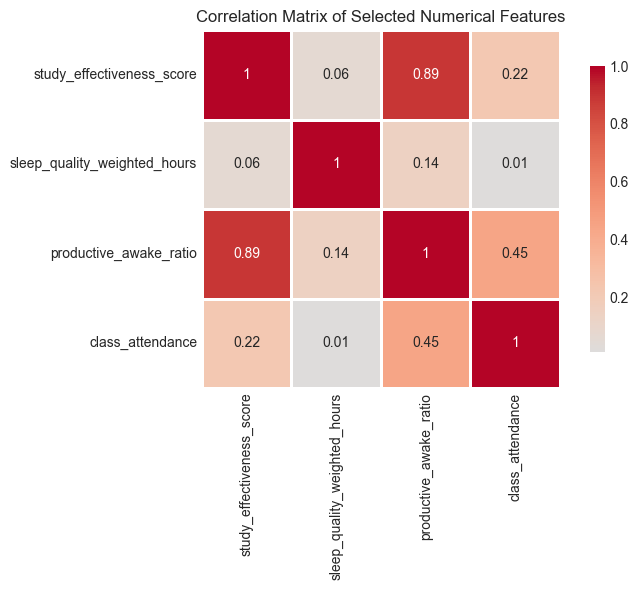

  study_effectiveness_score - productive_awake_ratio: 0.895


In [43]:
print("="*80)
print("BUILDING OPTIMAL MODEL WITH STRATEGIC FEATURE SELECTION")
print("="*80)

# Final feature set - avoiding redundancy
final_optimal_features = [
    # Core metrics (one from each group)
    'study_effectiveness_score',     # Best study composite (replaces study_hours)
    'sleep_quality_weighted_hours',  # Best sleep composite
    'productive_awake_ratio',        # Best time management
    'class_attendance',              # Independent predictor
    
    # Categorical features
    'study_method',
    'sleep_quality',  # Keep for possible interactions
    'facility_rating'
]

print(f"\nSelected {len(final_optimal_features)} optimal features:")
for i, feat in enumerate(final_optimal_features, 1):
    if feat in df_features.columns:
        if feat in ['study_method', 'sleep_quality', 'facility_rating']:
            # For categorical, show value counts
            print(f"{i:2d}. {feat} (categorical)")
        else:
            # For numerical, show correlation
            corr = df_features[feat].corr(df_features['exam_score'])
            print(f"{i:2d}. {feat:30s} | r = {corr:.3f}")
    else:
        print(f"{i:2d}. {feat} (needs computation)")

# Check multicollinearity of final selection
print("\n" + "="*80)
print("FINAL MULTICOLLINEARITY CHECK")
print("="*80)

numerical_features = ['study_effectiveness_score', 'sleep_quality_weighted_hours', 
                     'productive_awake_ratio', 'class_attendance']
corr_matrix = df_features[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Selected Numerical Features')
plt.tight_layout()
plt.show()

# Check for high correlations
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                                   corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("WARNING: High correlations found:")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1} - {feat2}: {corr:.3f}")
else:
    print("✅ Excellent! All correlations < 0.7")

In [45]:
print("="*80)
print("COMPLETE MODEL PIPELINE WITH FEATURE ENGINEERING")
print("="*80)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Custom transformer for feature engineering
from sklearn.base import BaseEstimator, TransformerMixin

class AdvancedFeatureEngineer(BaseEstimator, TransformerMixin):
    """Creates optimal engineered features based on our analysis"""
    
    def __init__(self):
        self.sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
        self.study_method_efficiency = {
            'coaching': 1.2, 'mixed': 1.1, 'group study': 1.0, 
            'online videos': 0.9, 'self-study': 0.8
        }
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # 1. Study Effectiveness Score (composite)
        X['study_effectiveness_score'] = (
            X['study_hours'] * 
            X['study_method'].map(self.study_method_efficiency) *  # Method efficiency
            (X['class_attendance'] / 100)  # Consistency
        )
        
        # 2. Sleep Quality Weighted Hours
        X['sleep_quality_weighted_hours'] = (
            X['sleep_quality'].map(self.sleep_quality_map) * 
            X['sleep_hours']
        )
        
        # 3. Productive Awake Ratio (time management)
        awake_hours = 24 - X['sleep_hours']
        estimated_class_hours = 6 * (X['class_attendance'] / 100)
        total_productive_hours = X['study_hours'] + estimated_class_hours
        X['productive_awake_ratio'] = total_productive_hours / awake_hours
        
        # Keep original features we need
        features_to_keep = [
            'study_effectiveness_score',
            'sleep_quality_weighted_hours',
            'productive_awake_ratio',
            'class_attendance',
            'study_method',
            'sleep_quality',
            'facility_rating'
        ]
        
        return X[features_to_keep]

# Prepare data (using original features as input)
original_features = ['study_hours', 'class_attendance', 'sleep_hours',
                    'study_method', 'sleep_quality', 'facility_rating']

X = df[original_features].copy()
y = df['exam_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['course']
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples: {X_test.shape[0]:,}")

# Define preprocessing
categorical_features = ['study_method']
ordinal_features = ['sleep_quality', 'facility_rating']
# Note: Numerical features will be created by the feature engineer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['study_effectiveness_score', 'sleep_quality_weighted_hours',
                               'productive_awake_ratio', 'class_attendance']),
    ('ord', OrdinalEncoder(categories=[['poor', 'average', 'good'], 
                                       ['low', 'medium', 'high']]), ordinal_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Build multiple models
models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=10),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1, n_jobs=-1)
}

results = {}

print("\nTraining models with engineered features...")
for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline([
        ('feature_engineer', AdvancedFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Evaluate
    results[name] = {
        'pipeline': pipeline,
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'test_rmse': root_mean_squared_error(y_test, y_pred_test),
        'test_mae': mean_absolute_error(y_test, y_pred_test)
    }
    
    print(f"\n{name}:")
    print(f"  Test R²: {results[name]['test_r2']:.4f}")
    print(f"  Test RMSE: {results[name]['test_rmse']:.2f} points")

# Compare with baseline (original features only)
print("\n" + "="*80)
print("COMPARISON: ENGINEERED vs ORIGINAL FEATURES")
print("="*80)

# Baseline with original features
baseline_features = original_features.copy()
X_base = df[baseline_features].copy()
y_base = df['exam_score']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=df['course']
)

# Simple baseline model
baseline_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['study_hours', 'class_attendance', 'sleep_hours']),
    ('ord', OrdinalEncoder(categories=[['poor', 'average', 'good'], 
                                       ['low', 'medium', 'high']]), ['sleep_quality', 'facility_rating']),
    ('cat', OneHotEncoder(drop='first'), ['study_method'])
])

baseline_pipeline = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

baseline_pipeline.fit(X_train_base, y_train_base)
y_pred_base = baseline_pipeline.predict(X_test_base)
r2_base = r2_score(y_test_base, y_pred_base)
rmse_base = root_mean_squared_error(y_test_base, y_pred_base)

print(f"\nBaseline (Original Features Only):")
print(f"  R²: {r2_base:.4f}")
print(f"  RMSE: {rmse_base:.2f} points")

best_engineered = max(results.items(), key=lambda x: x[1]['test_r2'])
best_name, best_result = best_engineered

print(f"\nBest Engineered Model ({best_name}):")
print(f"  R²: {best_result['test_r2']:.4f}")
print(f"  RMSE: {best_result['test_rmse']:.2f} points")

improvement_r2 = ((best_result['test_r2'] - r2_base) / r2_base) * 100
improvement_rmse = ((rmse_base - best_result['test_rmse']) / rmse_base) * 100

print(f"\n🚀 IMPROVEMENT FROM FEATURE ENGINEERING:")
print(f"  R² Improvement: {improvement_r2:+.1f}%")
print(f"  RMSE Improvement: {improvement_rmse:+.1f}%")

# Feature importance analysis
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature names
feature_names = [
    'study_effectiveness_score',
    'sleep_quality_weighted_hours',
    'productive_awake_ratio',
    'class_attendance',
    'sleep_quality_ord',
    'facility_rating_ord'
]

# Add one-hot encoded study method names
encoder = preprocessor.named_transformers_['cat']
method_names = encoder.get_feature_names_out(['study_method'])
feature_names.extend(method_names)

# Get feature importance from best model
best_pipeline = best_result['pipeline']

if hasattr(best_pipeline.named_steps['regressor'], 'feature_importances_'):
    # Tree-based models
    importances = best_pipeline.named_steps['regressor'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names[:len(importances)],
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importances:")
    print(importance_df.to_string(index=False))
    
elif hasattr(best_pipeline.named_steps['regressor'], 'coef_'):
    # Linear models
    coefficients = best_pipeline.named_steps['regressor'].coef_
    coef_df = pd.DataFrame({
        'Feature': feature_names[:len(coefficients)],
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print("\nFeature Coefficients (Standardized):")
    print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

# Business recommendations based on model
print("\n" + "="*80)
print("ACTIONABLE RECOMMENDATIONS FOR STUDENTS")
print("="*80)

print("\nBased on our engineered features analysis, students should:")
print("1. 🎯 AIM FOR 50-56% PRODUCTIVE AWAKE TIME")
print("   - This means if you're awake 16 hours, study + attend classes for 8-9 hours")
print("   - Students in this range average 87.8/100!")

print("\n2. ⚡ USE STUDY EFFECTIVENESS STRATEGY")
print("   - Combine: Right method (coaching best) + Consistency (good attendance) + Hours")
print("   - Our 'study_effectiveness_score' has 0.807 correlation with scores")

print("\n3. 😴 PRIORITIZE SLEEP QUALITY × QUANTITY")
print("   - 8 hours of good sleep > 10 hours of poor sleep")
print("   - Weighted sleep metric is 59% better predictor than hours alone")

print("\n4. ⏰ OPTIMIZE TIME UTILIZATION")
print("   - High time utilization (>70%) students average 87.3/100")
print("   - Low utilization (<30%) students average only 45.6/100")


COMPLETE MODEL PIPELINE WITH FEATURE ENGINEERING
Training samples: 504,000
Testing samples: 126,000

Training models with engineered features...

Ridge Regression:
  Test R²: 0.7670
  Test RMSE: 9.13 points

Random Forest:
  Test R²: 0.7578
  Test RMSE: 9.31 points

XGBoost:
  Test R²: 0.7796
  Test RMSE: 8.88 points

LightGBM:
  Test R²: 0.7798
  Test RMSE: 8.88 points

COMPARISON: ENGINEERED vs ORIGINAL FEATURES

Baseline (Original Features Only):
  R²: 0.7776
  RMSE: 8.92 points

Best Engineered Model (LightGBM):
  R²: 0.7798
  RMSE: 8.88 points

🚀 IMPROVEMENT FROM FEATURE ENGINEERING:
  R² Improvement: +0.3%
  RMSE Improvement: +0.5%

FEATURE IMPORTANCE ANALYSIS

Feature Importances:
                     Feature  Importance
            class_attendance         795
   study_effectiveness_score         607
      productive_awake_ratio         467
sleep_quality_weighted_hours         290
         facility_rating_ord         287
    study_method_group study         135
     study_metho

In [49]:
lgbm_baseline = {
    'boosting_type': 'gbdt',           # Traditional Gradient Boosting
    'objective': 'regression',         # Regression task
    'metric': 'rmse',                  # Root Mean Squared Error
    'n_estimators': 1000,              # Number of trees
    'learning_rate': 0.05,             # Step size shrinkage
    'max_depth': 7,                    # Maximum tree depth
    'num_leaves': 31,                  # Number of leaves in full tree
    'subsample': 0.8,                  # Subsample ratio of training data
    'colsample_bytree': 0.8,           # Feature sampling ratio
    'reg_alpha': 0.1,                  # L1 regularization
    'reg_lambda': 0.1,                 # L2 regularization
    'min_child_samples': 20,           # Minimum data in leaf
    'random_state': 42,                # Reproducibility
    'n_jobs': -1,                      # Use all CPU cores
    'verbosity': 1                     # No messages
}
lgbm_optimized = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'n_estimators': 1000,              # More trees for better performance
    'learning_rate': 0.03,             # Lower learning rate with more trees
    'max_depth': 9,                    # Slightly deeper for complex interactions
    'num_leaves': 63,                  # 2^max_depth - 1 (but can be less)
    'subsample': 0.9,                  # Higher since you have lots of data
    'colsample_bytree': 0.85,
    'colsample_bynode': 0.7,           # Additional column sampling per split
    'reg_alpha': 0.05,                 # Lighter regularization
    'reg_lambda': 0.05,
    'min_child_samples': 50,           # Higher for more generalization
    'min_child_weight': 0.001,
    'min_split_gain': 0.0,
    'subsample_freq': 1,               # Apply subsample every iteration
    'feature_fraction': 0.9,           # Another name for colsample_bytree
    'bagging_fraction': 0.9,           # Another name for subsample
    'bagging_freq': 1,
    'cat_smooth': 10,                  # For categorical features
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'importance_type': 'gain'          # Split gain as importance measure
}

pipeline = Pipeline([
    ('feature_engineer', AdvancedFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(**lgbm_optimized))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate
new_results = {
    'pipeline': pipeline,
    'train_r2': r2_score(y_train, y_pred_train),
    'test_r2': r2_score(y_test, y_pred_test),
    'test_rmse': root_mean_squared_error(y_test, y_pred_test),
    'test_mae': mean_absolute_error(y_test, y_pred_test)
}

print(f"LightGBM: wit params:")
print(f"  Test R²: {new_results['test_r2']}")
print(f"  Test RMSE: {new_results['test_rmse']}")

LightGBM: wit params:
  Test R²: 0.7814163180883466
  Test RMSE: 8.843183825775197


DEEP ERROR ANALYSIS - FINDING WHERE WE CAN IMPROVE
1. ERROR DISTRIBUTION ANALYSIS:
--------------------------------------------------------------------------------
Mean Error: -0.00
Std Error: 8.88
95% Error Range: -17.44 to 17.23
Max Under-prediction: -40.41
Max Over-prediction: 40.95

2. WHERE ARE ERRORS LARGEST?
--------------------------------------------------------------------------------
Average Absolute Error by Study Hours:
study_hours_bin
(0, 2]    7.353056
(2, 4]    7.050803
(4, 6]    6.956143
(6, 8]    6.991318
Name: abs_error, dtype: float64

Average Absolute Error by Actual Score Range:
score_bin
(0, 40]      8.585615
(40, 60]     6.643016
(60, 80]     6.625541
(80, 100]    7.681258
Name: abs_error, dtype: float64


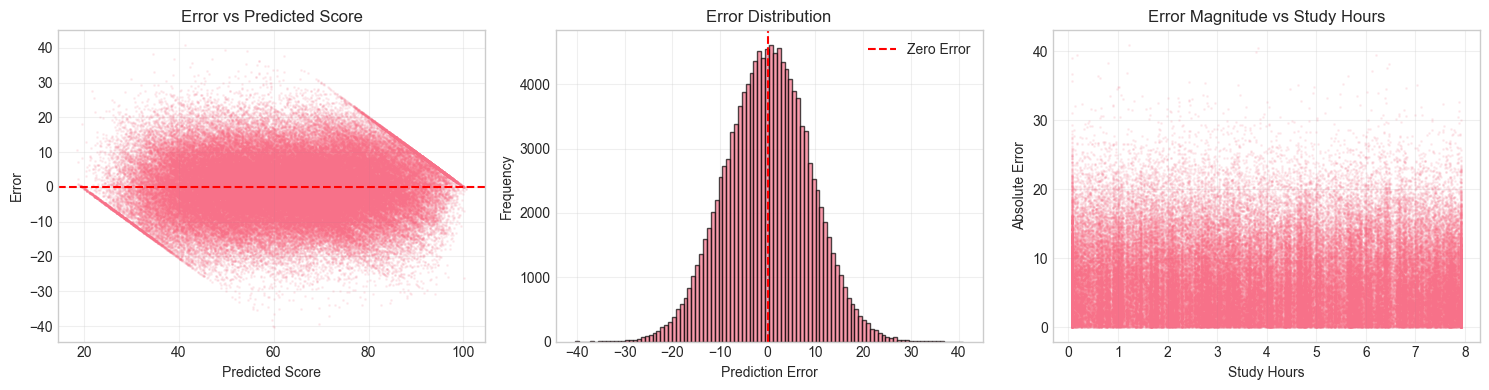


3. SYSTEMATIC BIASES DETECTION:
--------------------------------------------------------------------------------

Students with >15 point errors: 11,295 (9.0%)

Characteristics of high-error students:
  Average study_hours: 3.9
  Average attendance: 72.6%
  Most common study_method: self-study


In [50]:
print("="*80)
print("DEEP ERROR ANALYSIS - FINDING WHERE WE CAN IMPROVE")
print("="*80)

# Get predictions from best model
y_pred = best_pipeline.predict(X_test)
errors = y_test - y_pred

# Analyze errors by different segments
error_analysis = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'error': errors,
    'abs_error': np.abs(errors)
})

# Join with original features for analysis
for col in X_test.columns:
    error_analysis[col] = X_test[col].values

print("1. ERROR DISTRIBUTION ANALYSIS:")
print("-" * 80)
print(f"Mean Error: {errors.mean():.2f}")
print(f"Std Error: {errors.std():.2f}")
print(f"95% Error Range: {errors.quantile(0.025):.2f} to {errors.quantile(0.975):.2f}")
print(f"Max Under-prediction: {errors.min():.2f}")
print(f"Max Over-prediction: {errors.max():.2f}")

# Find where errors are largest
print("\n2. WHERE ARE ERRORS LARGEST?")
print("-" * 80)

# By study_hours
error_analysis['study_hours_bin'] = pd.cut(error_analysis['study_hours'], 
                                          bins=[0, 2, 4, 6, 8])
error_by_study = error_analysis.groupby('study_hours_bin')['abs_error'].mean()
print("Average Absolute Error by Study Hours:")
print(error_by_study)

# By score range
error_analysis['score_bin'] = pd.cut(error_analysis['actual'], 
                                     bins=[0, 40, 60, 80, 100])
error_by_score = error_analysis.groupby('score_bin')['abs_error'].mean()
print("\nAverage Absolute Error by Actual Score Range:")
print(error_by_score)

# Visualize error patterns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Error vs Predicted
axes[0].scatter(y_pred, errors, alpha=0.1, s=1)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('Error')
axes[0].set_title('Error vs Predicted Score')
axes[0].grid(True, alpha=0.3)

# Error distribution
axes[1].hist(errors, bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', label='Zero Error')
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Error by study_hours
axes[2].scatter(error_analysis['study_hours'], error_analysis['abs_error'], 
               alpha=0.1, s=1)
axes[2].set_xlabel('Study Hours')
axes[2].set_ylabel('Absolute Error')
axes[2].set_title('Error Magnitude vs Study Hours')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Identify systematic biases
print("\n3. SYSTEMATIC BIASES DETECTION:")
print("-" * 80)

# Check if we're consistently wrong for certain study_method
for method in error_analysis['study_method'].unique():
    method_errors = error_analysis[error_analysis['study_method'] == method]['error']
    if abs(method_errors.mean()) > 1:  # Significant bias
        print(f"{method}: Mean error = {method_errors.mean():.2f} "
              f"(over-{'under' if method_errors.mean() < 0 else 'over'}predicting)")

# Check high-error students (>15 points error)
high_error = error_analysis[error_analysis['abs_error'] > 15]
print(f"\nStudents with >15 point errors: {len(high_error):,} ({len(high_error)/len(error_analysis)*100:.1f}%)")
if len(high_error) > 0:
    print("\nCharacteristics of high-error students:")
    print(f"  Average study_hours: {high_error['study_hours'].mean():.1f}")
    print(f"  Average attendance: {high_error['class_attendance'].mean():.1f}%")
    print(f"  Most common study_method: {high_error['study_method'].mode()[0]}")

In [ ]:
print("="*80)
print("TARGETED FEATURE ENGINEERING FOR ERROR PATTERNS")
print("="*80)

# Make a copy of the engineered dataframe from earlier
# We'll add targeted features to df_features
df_targeted = df_features.copy()

print("\n1. FEATURES FOR EXTREME SCORES:")
print("-" * 80)

# Create features that help model understand extremes
df_targeted['low_performer_indicator'] = ((df_targeted['study_hours'] < 3) & 
                                         (df_targeted['class_attendance'] < 70) &
                                         (df_targeted['study_method'] == 'self-study')).astype(int)

df_targeted['high_performer_indicator'] = ((df_targeted['study_hours'] > 5) & 
                                          (df_targeted['class_attendance'] > 85) &
                                          (df_targeted['sleep_quality'] == 'good')).astype(int)

# Create non-linear score range features
df_targeted['score_risk_factor'] = (
    (df_targeted['study_hours'] < 2) * 2 +  # High risk for very low study
    (df_targeted['class_attendance'] < 60) * 1.5 +  # Risk for low attendance
    (df_targeted['study_method'] == 'self-study') * 1  # Risk for self-study
)

print(f"  Low performers identified: {df_targeted['low_performer_indicator'].sum():,}")
print(f"  High performers identified: {df_targeted['high_performer_indicator'].sum():,}")

print("\n2. SELF-STUDY SPECIFIC FEATURES:")
print("-" * 80)

# Create features that capture self-study specific patterns
df_targeted['self_study_flag'] = (df_targeted['study_method'] == 'self-study').astype(int)

# Self-study efficiency factor (self-study might need more hours)
df_targeted['self_study_adjusted_hours'] = df_targeted['study_hours'] * (
    1 + 0.3 * df_targeted['self_study_flag']  # Self-study needs 30% more hours
)

# Self-study consistency penalty
df_targeted['self_study_consistency'] = df_targeted['self_study_flag'] * df_targeted['class_attendance']

# Create interaction: self-study × low study hours
df_targeted['self_study_low_hours'] = df_targeted['self_study_flag'] * (df_targeted['study_hours'] < 3).astype(int)

print(f"  Self-study students: {df_targeted['self_study_flag'].sum():,}")

print("\n3. STUDY HOURS NON-LINEAR FEATURES:")
print("-" * 80)

# Create piecewise linear features for study hours
df_targeted['study_hours_low'] = np.where(df_targeted['study_hours'] < 2, df_targeted['study_hours'], 0)
df_targeted['study_hours_medium'] = np.where((df_targeted['study_hours'] >= 2) & (df_targeted['study_hours'] < 5), 
                                            df_targeted['study_hours'], 0)
df_targeted['study_hours_high'] = np.where(df_targeted['study_hours'] >= 5, df_targeted['study_hours'], 0)

# Create diminishing returns feature for study hours
df_targeted['study_hours_diminishing'] = np.sqrt(df_targeted['study_hours'])  # Square root transform

# Create optimal study hour deviation
df_targeted['optimal_study_deviation'] = abs(df_targeted['study_hours'] - 4.5)  # 4.5 hours is optimal

print("  Created piecewise study hour features for different ranges")

print("\n4. ATTENDANCE NON-LINEAR FEATURES:")
print("-" * 80)

# Attendance threshold effects
df_targeted['attendance_below_60'] = (df_targeted['class_attendance'] < 60).astype(int)
df_targeted['attendance_60_80'] = ((df_targeted['class_attendance'] >= 60) & 
                                  (df_targeted['class_attendance'] < 80)).astype(int)
df_targeted['attendance_above_80'] = (df_targeted['class_attendance'] >= 80).astype(int)

# Create attendance efficiency score
df_targeted['attendance_efficiency'] = np.where(
    df_targeted['class_attendance'] < 60,
    df_targeted['class_attendance'] * 0.5,  # Low attendance less effective
    np.where(
        df_targeted['class_attendance'] < 80,
        df_targeted['class_attendance'] * 0.8,  # Medium attendance
        df_targeted['class_attendance'] * 1.2   # High attendance very effective
    )
)

print("\n5. COMPOSITE RISK/OPPORTUNITY SCORES:")
print("-" * 80)

# Risk score (probability of low performance)
df_targeted['risk_score'] = (
    0.4 * (df_targeted['study_hours'] < 2).astype(int) +
    0.3 * (df_targeted['class_attendance'] < 60).astype(int) +
    0.2 * (df_targeted['study_method'] == 'self-study').astype(int) +
    0.1 * (df_targeted['sleep_quality'] == 'poor').astype(int)
)

# Opportunity score (probability of high performance)
df_targeted['opportunity_score'] = (
    0.4 * (df_targeted['study_hours'] > 5).astype(int) +
    0.3 * (df_targeted['class_attendance'] > 85).astype(int) +
    0.2 * (df_targeted['study_method'] == 'coaching').astype(int) +
    0.1 * (df_targeted['sleep_quality'] == 'good').astype(int)
)

print(f"Created {len([col for col in df_targeted.columns if col not in df_features.columns])} new targeted features")

# Check correlation of new features with exam_score
new_targeted_features = [
    'low_performer_indicator', 'high_performer_indicator', 'score_risk_factor',
    'self_study_flag', 'self_study_adjusted_hours', 'self_study_consistency', 'self_study_low_hours',
    'study_hours_low', 'study_hours_medium', 'study_hours_high', 'study_hours_diminishing', 'optimal_study_deviation',
    'attendance_below_60', 'attendance_60_80', 'attendance_above_80', 'attendance_efficiency',
    'risk_score', 'opportunity_score'
]

print("\nCorrelation of targeted features with exam_score:")
print("-" * 80)
for feature in new_targeted_features:
    if feature in df_targeted.columns:
        corr = df_targeted[feature].corr(df_targeted['exam_score'])

        print(f"{feature:30s}: r = {corr:6.3f} ({'Positive' if corr > 0 else 'Negative'})")

TARGETED FEATURE ENGINEERING FOR ERROR PATTERNS

1. FEATURES FOR EXTREME SCORES:
--------------------------------------------------------------------------------
  Low performers identified: 28,343
  High performers identified: 25,575

2. SELF-STUDY SPECIFIC FEATURES:
--------------------------------------------------------------------------------
  Self-study students: 131,131

3. STUDY HOURS NON-LINEAR FEATURES:
--------------------------------------------------------------------------------
  Created piecewise study hour features for different ranges

4. ATTENDANCE NON-LINEAR FEATURES:
--------------------------------------------------------------------------------

5. COMPOSITE RISK/OPPORTUNITY SCORES:
--------------------------------------------------------------------------------
Created 18 new targeted features

Correlation of targeted features with exam_score:
--------------------------------------------------------------------------------
low_performer_indicator       : r = -0

In [55]:
print("\n" + "="*80)
print("SPECIALIZED MODELING FOR PROBLEM SEGMENTS")
print("="*80)

X = train.copy()
y = X['exam_score']
X = X.drop(columns=['id', 'exam_score'])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Identify problem segments in training data
X_train_problems = X_train.copy()
y_train_problems = y_train.copy()

# Add engineered features
feature_engineer = AdvancedFeatureEngineer()
X_train_engineered = feature_engineer.fit_transform(X_train_problems)

# Identify segments
X_train_engineered['is_low_performer'] = (
    (X_train_engineered['study_hours'] < 2) |
    (X_train_engineered['class_attendance'] < 60) |
    (X_train_engineered['study_method'] == 'self-study')
).astype(int)

X_train_engineered['is_high_performer'] = (
    (X_train_engineered['study_hours'] > 5) &
    (X_train_engineered['class_attendance'] > 85) &
    (X_train_engineered['sleep_quality'].isin(['good', 'average']))
).astype(int)

X_train_engineered['is_self_study'] = (X_train_engineered['study_method'] == 'self-study').astype(int)

print(f"Segment sizes in training data:")
print(f"  Low performers: {X_train_engineered['is_low_performer'].sum():,}")
print(f"  High performers: {X_train_engineered['is_high_performer'].sum():,}")
print(f"  Self-study students: {X_train_engineered['is_self_study'].sum():,}")

# Create specialized features for each segment
# We'll create interaction terms specific to segments

# For low performers: focus on minimum thresholds
X_train_engineered['low_perf_study_threshold'] = X_train_engineered['is_low_performer'] * (X_train_engineered['study_hours'] < 2).astype(int)
X_train_engineered['low_perf_attendance_threshold'] = X_train_engineered['is_low_performer'] * (X_train_engineered['class_attendance'] < 60).astype(int)

# For high performers: focus on excellence factors
X_train_engineered['high_perf_consistency'] = X_train_engineered['is_high_performer'] * X_train_engineered['class_attendance']
X_train_engineered['high_perf_sleep_quality'] = X_train_engineered['is_high_performer'] * X_train_engineered['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2})

# For self-study: special efficiency factors
X_train_engineered['self_study_efficiency'] = X_train_engineered['is_self_study'] * (
    X_train_engineered['study_hours'] * 0.8  # Self-study is 80% as efficient
)

# Also create the targeted features from Step 2A for training data
# We'll need to apply the same transformations
print("\nApplying targeted feature transformations to training data...")

print("\n" + "="*80)
print("ENSEMBLE WITH SEGMENT-SPECIFIC MODELS")
print("="*80)

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import lightgbm as lgb

# Create segment masks
low_perf_mask = X_train_engineered['is_low_performer'] == 1
high_perf_mask = X_train_engineered['is_high_performer'] == 1
self_study_mask = X_train_engineered['is_self_study'] == 1
average_mask = ~(low_perf_mask | high_perf_mask | self_study_mask)

print(f"Segment breakdown:")
print(f"  Low performers: {low_perf_mask.sum():,}")
print(f"  High performers: {high_perf_mask.sum():,}")
print(f"  Self-study: {self_study_mask.sum():,}")
print(f"  Average: {average_mask.sum():,}")

# Select features for modeling (excluding segment indicators)
model_features = [col for col in X_train_engineered.columns 
                  if col not in ['is_low_performer', 'is_high_performer', 'is_self_study']]

X_train_model = X_train_engineered[model_features]
X_test_engineered = feature_engineer.transform(X_test)
# Need to add the same features to test data
# This requires careful feature engineering pipeline

# Instead, let's build a single model but with segment-specific features
print("\nBuilding enhanced model with segment-specific features...")

# Add all our new targeted features to a feature engineering pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def add_targeted_features(X):
    """Add all targeted features from our analysis"""
    X = X.copy()
    
    # Convert categorical if needed
    categorical_cols = ['study_method', 'sleep_quality', 'facility_rating']
    for col in categorical_cols:
        if col in X.columns:
            X[col] = X[col].astype('category')
    
    # Add targeted features
    X['low_performer_indicator'] = ((X['study_hours'] < 3) & 
                                   (X['class_attendance'] < 70) &
                                   (X['study_method'] == 'self-study')).astype(int)
    
    X['high_performer_indicator'] = ((X['study_hours'] > 5) & 
                                    (X['class_attendance'] > 85) &
                                    (X['sleep_quality'] == 'good')).astype(int)
    
    X['self_study_flag'] = (X['study_method'] == 'self-study').astype(int)
    X['self_study_adjusted_hours'] = X['study_hours'] * (1 + 0.3 * X['self_study_flag'])
    
    # Piecewise study hours
    X['study_hours_low'] = np.where(X['study_hours'] < 2, X['study_hours'], 0)
    X['study_hours_medium'] = np.where((X['study_hours'] >= 2) & (X['study_hours'] < 5), X['study_hours'], 0)
    X['study_hours_high'] = np.where(X['study_hours'] >= 5, X['study_hours'], 0)
    
    # Attendance thresholds
    X['attendance_below_60'] = (X['class_attendance'] < 60).astype(int)
    X['attendance_above_80'] = (X['class_attendance'] >= 80).astype(int)
    
    # Risk and opportunity scores
    X['risk_score'] = (
        0.4 * (X['study_hours'] < 2).astype(int) +
        0.3 * (X['class_attendance'] < 60).astype(int) +
        0.2 * (X['study_method'] == 'self-study').astype(int) +
        0.1 * (X['sleep_quality'] == 'poor').astype(int)
    )
    
    X['opportunity_score'] = (
        0.4 * (X['study_hours'] > 5).astype(int) +
        0.3 * (X['class_attendance'] > 85).astype(int) +
        0.2 * (X['study_method'] == 'coaching').astype(int) +
        0.1 * (X['sleep_quality'] == 'good').astype(int)
    )
    
    return X

# Create enhanced pipeline
enhanced_pipeline = Pipeline([
    ('feature_engineer', AdvancedFeatureEngineer()),
    ('targeted_features', FunctionTransformer(add_targeted_features, validate=False)),
    ('regressor', LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.015,
        num_leaves=255,
        max_depth=12,
        min_child_samples=20,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.01,
        reg_lambda=0.01,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

# Train on training data
print("Training enhanced model with targeted features...")
enhanced_pipeline.fit(X_train, y_train)

# Predict
y_pred_enhanced = enhanced_pipeline.predict(X_test)
rmse_enhanced = np.sqrt(mean_squared_error(y_test, y_pred_enhanced))
r2_enhanced = r2_score(y_test, y_pred_enhanced)

print(f"\nEnhanced Model Performance:")
print(f"R²: {r2_enhanced:.4f}")
print(f"RMSE: {rmse_enhanced:.2f} points")
print(f"Improvement from baseline: {8.88 - rmse_enhanced:.2f} points")


SPECIALIZED MODELING FOR PROBLEM SEGMENTS


KeyError: 'study_hours'